<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/9_global_prediction_used.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global daily prediction per event

In [1]:
! pip install optuna &> /dev/null

### Workspace

In [2]:
import os

import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import scipy
import sklearn
from scipy.stats import chi2_contingency,kruskal, kendalltau,rankdata
from scipy.stats import chi2 as chi2_dist
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance, d2_tweedie_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm
from lightgbm import LGBMRegressor
import tensorflow as tf
import glob
import optuna
from itertools import combinations, product

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (11, 5)

print("Libraries loaded:")
for name, module in [("numpy", np), ("pandas", pd), ("matplotlib", matplotlib), ("scipy", scipy),
                     ("scikit-learn", sklearn), ("lightgbm", lightgbm), ("tf", tf),
                     ("optuna", optuna)]:
    print(f"  {name:14s} {getattr(module, '__version__', '?')}")

Libraries loaded:
  numpy          2.0.2
  pandas         2.2.2
  matplotlib     3.10.0
  scipy          1.16.3
  scikit-learn   1.6.1
  lightgbm       4.6.0
  tf             2.20.0
  optuna         4.9.0


In [3]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
TRAIN_END = pd.Timestamp("2023-12-31 23:59:59")
CALIBRATION_START = pd.Timestamp("2024-01-01")
CALIBRATION_END = pd.Timestamp("2024-12-31 23:59:59")
TEST_START = pd.Timestamp("2025-01-01")

EXCLUDE_GROUPS = {
    "Tornado", "Thunderstorm", "Geomagnetic", "Volcanic",
    "Tsunami", "Marine_Other",
}

TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
    "DAMAGE_PROPERTY", "DAMAGE_CROPS",
]

FORECAST_TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
]

ORDINAL_LEVELS = {
    "risk": ["low", "medium", "high"],
    "event_scope": ["localized", "county-wide", "regional", "widespread"],
    "MONTH_NAME": [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ],
}


GROUP_COL = "EVENT_GROUP"

RANDOM_STATE = 0

DEFAULT_RANDOM_STATE = 0 # Set a random seed for reproducibility throughout Python, NumPy, and TensorFlow operations
random.seed(DEFAULT_RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(DEFAULT_RANDOM_STATE)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(DEFAULT_RANDOM_STATE)
tf.random.set_seed(DEFAULT_RANDOM_STATE)

### Load data

In [4]:
base_url = "https://github.com/claudio1975/Storm_Events/raw/main/data/"
file_names = [f"StormEvents_fe_ep_augmentation_fin_part_{i}.parquet" for i in range(1, 11)]

# Construct full URLs for each part
parts_urls = [base_url + fn for fn in file_names]

# Read each part from the URL and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(url) for url in parts_urls], ignore_index=True)
print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
print('dtype backend in use:'); print(df.dtypes.value_counts())
df.head()

Loaded 2,012,856 rows  ×  58 columns
dtype backend in use:
float64    29
object     22
int64       7
Name: count, dtype: int64


,EVENT_ID,STATE,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,...,ev_embedding_4,ev_embedding_5,ev_embedding_6,ev_embedding_7,ev_embedding_8,ev_embedding_9,ev_embedding_10,risk,impact_type,event_scope
0,10096222,OKLAHOMA,1950,April,Tornado,C,149,WASHITA,OUN,28-APR-50 14:45:00,...,0.122519,0.216200,-0.101279,-0.029508,-0.004710,0.132303,0.390889,high,no_significant_impact,regional
1,10120412,TEXAS,1950,April,Tornado,C,93,COMANCHE,FWD,29-APR-50 15:30:00,...,0.155210,0.202612,-0.117554,-0.069974,-0.058874,0.081851,0.329872,high,no_significant_impact,regional
2,10104927,PENNSYLVANIA,1950,July,Tornado,C,77,LEHIGH,PHI,05-JUL-50 18:00:00,...,0.111113,0.042321,-0.088230,-0.116744,-0.044282,0.181879,0.355398,medium,property_damage,localized
3,10104928,PENNSYLVANIA,1950,July,Tornado,C,43,DAUPHIN,PHI,05-JUL-50 18:30:00,...,0.142479,0.162930,-0.081303,-0.035376,-0.122510,0.111897,0.351036,high,casualties,county-wide
4,10104929,PENNSYLVANIA,1950,July,Tornado,C,39,CRAWFORD,PHI,24-JUL-50 14:40:00,...,0.156529,0.247835,-0.079917,-0.016163,-0.072048,0.135745,0.407406,high,casualties,county-wide


## Workflow

### Building features

In [5]:
def haversine_distance(lat1, lon1, lat2, lon2, radius_km=6371.0):
    arrays = (np.radians(np.asarray(value, dtype="float64")) for value in (lat1, lon1, lat2, lon2))
    lat1, lon1, lat2, lon2 = arrays
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return radius_km * c


def parse_storm_datetime(series):
    parsed = pd.to_datetime(series, format="%d-%b-%y %H:%M:%S", errors="coerce")
    future_century = parsed.dt.year > 2025
    return parsed.where(~future_century, parsed - pd.DateOffset(years=100))


MONTH_NAME_TO_NUMBER = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}


def month_cyclical(month_name, fallback_month):
    """sin / cos of MONTH_NAME on the 12-month circle.
    """
    number = (
        month_name.astype("string")
        .str.strip()
        .str.capitalize()
        .map(MONTH_NAME_TO_NUMBER)
    )
    number = number.astype("Float64").fillna(fallback_month).astype("float64")
    angle = 2.0 * np.pi * (number - 1.0) / 12.0
    return np.sin(angle), np.cos(angle)


def build_base_event_frame(raw):
    out = raw.copy()
    out["BEGIN_DATE_TIME"] = parse_storm_datetime(out["BEGIN_DATE_TIME"])
    out["END_DATE_TIME"] = parse_storm_datetime(out["END_DATE_TIME"])
    out = out.loc[out["BEGIN_DATE_TIME"].notna()].copy()

    out.index = pd.DatetimeIndex(out["BEGIN_DATE_TIME"], name="Date")
    out = out.sort_index(kind="stable")

    begin = out["BEGIN_DATE_TIME"]
    end = out["END_DATE_TIME"]
    out["YEAR_BEGIN"] = begin.dt.year.astype("int64")
    out["MONTH_BEGIN"] = begin.dt.month.astype("int64")
    out["DAY_BEGIN"] = begin.dt.day.astype("int64")
    out["HOUR_BEGIN"] = begin.dt.hour.astype("int64")
    out["YEAR_END"] = end.dt.year.astype("Int64")
    out["MONTH_END"] = end.dt.month.astype("Int64")
    out["DAY_END"] = end.dt.day.astype("Int64")
    out["HOUR_END"] = end.dt.hour.astype("Int64")
    out["DAY_DURATION"] = (end - begin).dt.total_seconds() / 86400.0
    out["HOUR_DURATION"] = (end - begin).dt.total_seconds() / 3600.0

    out["MONTH_SIN"], out["MONTH_COS"] = month_cyclical(out["MONTH_NAME"], out["MONTH_BEGIN"])

    out['DISTANCE'] = haversine_distance(out["BEGIN_LAT"], out["BEGIN_LON"], out["END_LAT"], out["END_LON"])
    out["EXPOSURE"] = 1.0

    drop_replaced_features = [
        "BEGIN_LOCATION", "END_LOCATION", "EVENT_ID",
        "BEGIN_DATE_TIME", "END_DATE_TIME",
        "EPISODE_NARRATIVE", "EVENT_NARRATIVE",
        "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON",
        "DAY_BEGIN","DAY_END","HOUR_BEGIN","HOUR_END",
        "MAGNITUDE", "MAGNITUDE_TYPE", "TOR_F_SCALE", "TOR_WIDTH", "TOR_LENGTH","MONTH_NAME"
    ]
    out = out.drop(columns=[column for column in drop_replaced_features if column in out.columns])
    out = out.loc[~out["EVENT_GROUP"].isin(EXCLUDE_GROUPS)].copy()

    if "CZ_FIPS" in out.columns:
        out["CZ_FIPS"] = out["CZ_FIPS"].astype("string[pyarrow]")

    return out.sort_index(kind="stable")


base_events = build_base_event_frame(df)
print(base_events.shape)
print(base_events.index.min(), base_events.index.max())
base_events.head()


(888673, 51)
1996-01-01 00:00:00 2025-12-31 23:40:00


,STATE,YEAR,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,CZ_TIMEZONE,INJURIES_DIRECT,INJURIES_INDIRECT,...,YEAR_BEGIN,MONTH_BEGIN,YEAR_END,MONTH_END,DAY_DURATION,HOUR_DURATION,MONTH_SIN,MONTH_COS,DISTANCE,EXPOSURE
Date,,,,,,,,,,,,,,,,,,,,,
1996-01-01,CALIFORNIA,1996,High Wind,Z,15,NORTHERN SACRAMENTO VALLEY,LOX,PST,0,0,...,1996,1,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0
1996-01-01,CALIFORNIA,1996,High Wind,Z,17,SOUTHERN SACRAMENTO VALLEY,LOX,PST,0,0,...,1996,1,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0
1996-01-01,CALIFORNIA,1996,High Wind,Z,16,CENTRAL SACRAMENTO VALLEY,LOX,PST,0,0,...,1996,1,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0
1996-01-01,WYOMING,1996,Heavy Snow,Z,50,NORTHERN BIG HORN MOUNTAINS,CYS,MST,0,0,...,1996,1,1996,1,0.958333,23.0,0.0,1.0,0.0,1.0
1996-01-01,MONTANA,1996,Heavy Snow,Z,4,LOWER CLARK FORK REGION,TFX,MST,0,0,...,1996,1,1996,1,1.666667,40.0,0.0,1.0,0.0,1.0


### Split first to avoid data-leakege

In [6]:
train_raw = base_events.loc[:TRAIN_END].copy()
calibration_raw = base_events.loc[CALIBRATION_START:CALIBRATION_END].copy()
test_raw = base_events.loc[TEST_START:].copy()

split_summary = pd.DataFrame({
    "rows": [len(train_raw), len(calibration_raw), len(test_raw)],
    "start": [train_raw.index.min(), calibration_raw.index.min(), test_raw.index.min()],
    "end": [train_raw.index.max(), calibration_raw.index.max(), test_raw.index.max()]}, index=["train", "calibration", "test"])
display(split_summary)


,rows,start,end
train,812807,1996-01-01,2023-12-31 05:35:00
calibration,37371,2024-01-01,2024-12-31 23:30:00
test,38495,2025-01-01,2025-12-31 23:40:00


In [ ]:
### If you want to jump the filter features go to Dataset filtered and uncomment the line

### Filter Features by train

In [7]:
# ==============================================================================
# ZERO-VARIANCE FEATURE REMOVAL
# ==============================================================================

categorical_columns = [
    column
    for column in train_raw.columns
    if train_raw[column].dtype in ("string[pyarrow]", "object", "category")
]

numeric_columns = [
    column
    for column in train_raw.columns
    if column not in categorical_columns
]

categorical_zero_variance = [
    column
    for column in categorical_columns
    if train_raw[column].nunique(dropna=False) <= 1]

protected_numeric = set(TARGETS) | {"EXPOSURE"}
numeric_zero_variance = [
    column
    for column in numeric_columns
    if column not in protected_numeric
    and train_raw[column].nunique(dropna=False) <= 1]

cat=train_raw[categorical_columns]
num=train_raw[numeric_columns]
ordinal_cols = [c for c in cat if c in ORDINAL_LEVELS]        # ranked labels
nominal_cols = [c for c in cat if c not in ORDINAL_LEVELS]    # unranked labels
num_feat = [c for c in num if c not in TARGETS and c != "EXPOSURE"]


print("=" * 60)
print("Categorical zero-variance variables:", categorical_zero_variance)
print("Numerical zero-variance variables:", numeric_zero_variance)
print("=" * 60)

Categorical zero-variance variables: []
Numerical zero-variance variables: []


In [8]:
# ==============================================================================
# CRAMER'S V  TEST FOR CATEGORICAL VARIABLES
# ==============================================================================

CRAMER_THRESHOLD = 0.75
PROTECTED = {"EVENT_GROUP"}

test_columns = [c for c in categorical_columns if c not in PROTECTED]

rows = []
for a, b in combinations(test_columns, 2):
    tab = pd.crosstab(cat[a], cat[b])
    chi2, p, dof, _ = chi2_contingency(tab)
    k = min(tab.shape) - 1
    v = np.sqrt(chi2 / (tab.to_numpy().sum() * k)) if k else 0.0
    rows.append((a, b, chi2, p, dof, v))

cramers_v = pd.DataFrame(rows, columns=["Variable_1", "Variable_2", "Chi2_Stat", "p_value", "dof", "Cramer_V"]).sort_values("Cramer_V", ascending=False, ignore_index=True)

strong = cramers_v[cramers_v.Cramer_V >= CRAMER_THRESHOLD]
cramer_to_drop = sorted({max((r.Variable_1, r.Variable_2), key=lambda c: cat[c].nunique()) for r in strong.itertuples()})
print("=" * 60, "\nCategorical variables to drop:", cramer_to_drop, "\n" + "=" * 60)

Categorical variables to drop: ['CZ_NAME'] 


In [9]:
# ==============================================================================
# SPEARMAN CORRELATION FILTER FOR NUMERICAL PREDICTORS
# ==============================================================================

SPEARMAN_THRESHOLD = 0.75
PROTECTED_NUMERIC = set(TARGETS) | {"EXPOSURE"}

correlation_columns = [c for c in numeric_columns if c not in PROTECTED_NUMERIC]

corr = train_raw[correlation_columns].corr(method="spearman").abs()
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

corr_to_drop = corr.columns[(corr.where(mask) > SPEARMAN_THRESHOLD).any()].tolist()

print("=" * 60, "\nNumerical predictor variables to drop:", corr_to_drop, "\n" + "=" * 60)

Numerical predictor variables to drop: ['YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION'] 


In [10]:
# ==============================================================================
# KENDALL'S TAU-b TEST — NUMERICAL vs ORDINAL CATEGORICAL VARIABLES
# ==============================================================================

KENDALL_THRESHOLD = 0.75

ordinal_num = pd.DataFrame(index=train_raw.index)

for col in ordinal_cols:
    levels = ORDINAL_LEVELS[col]
    encoding = {}
    for position, level in enumerate(levels):
        encoding[level] = position
    ordinal_num[col] = train_raw[col].map(encoding)

X = train_raw[num_feat].to_numpy(dtype=float)
Y = ordinal_num.to_numpy(dtype=float)

n_num, n_ord = X.shape[1], Y.shape[1]
tau_mat = np.empty((n_num, n_ord))
pval_mat = np.empty((n_num, n_ord))
count_mat = np.empty((n_num, n_ord), dtype=int)

valid_x = ~np.isnan(X)
valid_y = ~np.isnan(Y)

for i in range(n_num):
    for j in range(n_ord):
        ok = valid_x[:, i] & valid_y[:, j]
        count_mat[i, j] = ok.sum()
        tau_mat[i, j], pval_mat[i, j] = kendalltau(X[ok, i], Y[ok, j], variant="b")

df_tau = pd.DataFrame({
    "Numerical":   np.repeat(list(num_feat), n_ord),
    "Categorical": np.tile(list(ordinal_cols), n_num),
    "tau_b":       tau_mat.ravel(),
    "p_value":     pval_mat.ravel(),
    "n_used":      count_mat.ravel()})
df_tau["Assoc"] = df_tau["tau_b"].abs()
df_tau = df_tau.sort_values("Assoc", ascending=False, ignore_index=True)

print("Strongest rank agreements (|tau_b| near 1 = duplicated information):")
print(df_tau.head(10).to_string(index=False))

strong = df_tau[df_tau["Assoc"] >= KENDALL_THRESHOLD]

df_tau_to_drop = sorted(set(strong["Categorical"]))

Strongest rank agreements (|tau_b| near 1 = duplicated information):
     Numerical Categorical     tau_b  p_value  n_used    Assoc
ep_embedding_4        risk -0.199794      0.0  812807 0.199794
ev_embedding_3        risk  0.195173      0.0  812807 0.195173
ep_embedding_3 event_scope -0.192953      0.0  812807 0.192953
      DISTANCE        risk  0.190766      0.0  812807 0.190766
ep_embedding_3        risk -0.181509      0.0  812807 0.181509
  DAY_DURATION event_scope  0.176965      0.0  812807 0.176965
 HOUR_DURATION event_scope  0.176965      0.0  812807 0.176965
ev_embedding_5        risk  0.143484      0.0  812807 0.143484
ep_embedding_6        risk -0.138057      0.0  812807 0.138057
ev_embedding_3 event_scope  0.133585      0.0  812807 0.133585


In [11]:
# ==============================================================================
# KRUSKAL-WALLIS H-TEST — NUMERICAL vs NOMINAL CATEGORICAL VARIABLES
# ==============================================================================

KRUSKAL_ETA_THRESHOLD = 0.75
PROTECTED = {"EVENT_GROUP"}

nominal_cols = [c for c in nominal_cols if c not in PROTECTED]

cat_codes = {}
for col in nominal_cols:
    cat_codes[col] = pd.factorize(train_raw[col])[0]

X = train_raw[num_feat].to_numpy(dtype=float)
valid_x = ~np.isnan(X)

def tie_correction(ranks):
    n = ranks.size
    if n < 2:
        return 0.0
    counts = np.unique(ranks, return_counts=True)[1].astype(float)
    tied = counts[counts > 1]
    return 1.0 - (tied ** 3 - tied).sum() / (n ** 3 - n)


def kruskal_from_ranks(ranks, group_codes, tie_corr):
    n = ranks.size
    group_size = np.bincount(group_codes)
    rank_sum = np.bincount(group_codes, weights=ranks)

    non_empty = group_size > 0
    group_size = group_size[non_empty]
    rank_sum = rank_sum[non_empty]
    k = group_size.size

    if k < 2 or n <= k or tie_corr <= 0:
        return np.nan, np.nan, k

    H = (12.0 / (n * (n + 1)) * np.sum(rank_sum ** 2 / group_size) - 3.0 * (n + 1)) / tie_corr
    return H, chi2_dist.sf(H, k - 1), k

rows = []

for i, num_col in enumerate(num_feat):
    x = X[:, i]
    ok_x = valid_x[:, i]
    n_x = int(ok_x.sum())

    ranks_cached = None
    tie_cached = None

    for cat_col in nominal_cols:
        codes = cat_codes[cat_col]
        ok = ok_x & (codes >= 0)
        n = int(ok.sum())
        if n < 3:
            continue

        if n == n_x:
            if ranks_cached is None:
                ranks_cached = rankdata(x[ok])
                tie_cached = tie_correction(ranks_cached)
            ranks, tie_corr = ranks_cached, tie_cached
        else:
            ranks = rankdata(x[ok])
            tie_corr = tie_correction(ranks)

        H, p, k = kruskal_from_ranks(ranks, codes[ok], tie_corr)
        if np.isnan(H):
            continue

        eta_sq = max(0.0, (H - k + 1) / (n - k))
        rows.append((num_col, cat_col, H, p, n, k, eta_sq))

df_kw = pd.DataFrame(rows,columns=["Numerical", "Categorical", "H_Stat", "p_value", "n_used", "k_groups",
                                   "Eta_Sq"]).sort_values("Eta_Sq", ascending=False, ignore_index=True)

print("Strongest Kruskal-Wallis associations (ranked by Eta-Squared):")
print(df_kw.head(10).to_string(index=False))

strong = df_kw[df_kw["Eta_Sq"] >= KRUSKAL_ETA_THRESHOLD]
df_kw_to_drop = sorted(set(strong["Categorical"]))

Strongest Kruskal-Wallis associations (ranked by Eta-Squared):
     Numerical Categorical        H_Stat  p_value  n_used  k_groups   Eta_Sq
      DISTANCE FLOOD_CAUSE 734056.499592      0.0  812807         9 0.903113
ev_embedding_6  EVENT_TYPE 686797.586355      0.0  812807        43 0.844963
ev_embedding_4  EVENT_TYPE 570594.114617      0.0  812807        43 0.701990
ep_embedding_2  EVENT_TYPE 533424.731615      0.0  812807        43 0.656258
    YEAR_BEGIN DATA_SOURCE 532237.682735      0.0  812807         3 0.654814
          YEAR DATA_SOURCE 532237.678446      0.0  812807         3 0.654814
      YEAR_END DATA_SOURCE 532236.713518      0.0  812807         3 0.654813
          YEAR CZ_TIMEZONE 517430.049906      0.0  812807        19 0.636589
    YEAR_BEGIN CZ_TIMEZONE 517430.015958      0.0  812807        19 0.636589
      YEAR_END CZ_TIMEZONE 517428.961893      0.0  812807        19 0.636588


In [12]:
###########################
# HIGH CARDINALITY
###########################
HIGH_CARDINALITY=50
cardinality = train_raw.select_dtypes(include=['object', 'category', 'string']).nunique(dropna=False).sort_values(ascending=False)
print(cardinality)
cardinality_drop=cardinality[cardinality>HIGH_CARDINALITY].index.tolist()

CZ_NAME        5464
CZ_FIPS         649
WFO             125
STATE            70
SOURCE           55
EVENT_TYPE       43
CZ_TIMEZONE      19
EVENT_GROUP      11
FLOOD_CAUSE       9
impact_type       5
event_scope       4
CZ_TYPE           3
DATA_SOURCE       3
risk              3
dtype: int64


### Dataset filtered

In [13]:
#feature_drop_columns = ['CZ_NAME', 'EVENT_TYPE','YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION','EVENT_TYPE'
#                       'FLOOD_CAUSE','CZ_FIPS','WFO','STATE','SOURCE']

# comment the line if youe have jumped Filter Features by train
feature_drop_columns=categorical_zero_variance+numeric_zero_variance+cramer_to_drop+corr_to_drop+df_tau_to_drop+df_kw_to_drop+cardinality_drop
print("Columns removed using training data only:")
print(feature_drop_columns)
train_events = train_raw.drop(columns=feature_drop_columns, errors="ignore")
calibration_events = calibration_raw.drop(columns=feature_drop_columns, errors="ignore")
test_events = test_raw.drop(columns=feature_drop_columns, errors="ignore")
print("Shapes after applying the frozen training filter:")
print(train_events.shape, calibration_events.shape, test_events.shape)

Columns removed using training data only:
['CZ_NAME', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'EVENT_TYPE', 'FLOOD_CAUSE', 'CZ_NAME', 'CZ_FIPS', 'WFO', 'STATE', 'SOURCE']
Shapes after applying the frozen training filter:
(812807, 40) (37371, 40) (38495, 40)


### Data Preparation

In [14]:
#########################################
# Data Preparation shared by every model
#########################################

MODEL_SPECS = {
    "GLM": {
        "label": "Poisson GLM",
        "nominal_encoding": "onehot",
        "scale_numeric": True,
        "scalar_param": "alpha",
        "fit_kind": "tabular",
        "default_params": {"alpha": 1.0},
    },
    "LGBM": {
        "label": "LightGBM Poisson",
        "nominal_encoding": "category",
        "scale_numeric": False,
        "scalar_param": None,
        "fit_kind": "tabular",
        "default_params": {
            "n_estimators": 300,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 200,
            "subsample": 0.8,
            "subsample_freq": 1,
            "colsample_bytree": 0.8,
            "reg_lambda": 5.0,
            "poisson_max_delta_step": 0.3,
        },
    },
    "LSTM": {
        "label": "LSTM Poisson",
        "nominal_encoding": "onehot",
        "scale_numeric": True,
        "scalar_param": None,
        "fit_kind": "sequence",
        "default_params": {
            "sequence_length": 6,
            "sequence_by": GROUP_COL,
            "units": 32,
            "dropout": 0.1,
            "learning_rate": 1e-3,
            "epochs": 5,
            "batch_size": 512,
            "verbose": 0,
        },
    },
}

DEFAULT_MODEL = "GLM"


def model_spec(model=DEFAULT_MODEL):
    """looks up and returns the spec dict for a given model name
    from MODEL_SPECS"""
    return MODEL_SPECS[model]


def model_label(model=DEFAULT_MODEL):
    """returns the human-readable label from that model's spec."""
    return model_spec(model)["label"]


def normalize_params(params, model=DEFAULT_MODEL):
    """merges user-supplied params over the model's default params"""
    spec = model_spec(model)
    defaults = dict(spec["default_params"])

    if params is None:
        return defaults
    if isinstance(params, dict):
        return {**defaults, **params}
    if spec["scalar_param"] is None:
        raise TypeError(f"{model} expects a parameter dictionary, got {params!r}")

    return {**defaults, spec["scalar_param"]: params}


def make_estimator(model=DEFAULT_MODEL, params=None):
    """Build the estimator for one model from its parameter dictionary."""
    params = normalize_params(params, model)

    if model == "GLM":
        return PoissonRegressor(fit_intercept=True,**params)
    if model == "LGBM":
        return LGBMRegressor(
            objective="poisson",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            **params,
        )

    raise KeyError(f"no estimator defined for {model!r}")


def fit_nominal_encoder(train_df, model=DEFAULT_MODEL):
    """Encode the unranked categorical predictors, training split only.

    GLM  -> one-hot dummies, unseen levels ignored.
    LGBM -> pandas `category` columns with the training levels frozen.

    EVENT_GROUP, the ordinals and the targets are left out: the first is a
    diagnostic key, the second keep their order inside a single column, the
    third are outcomes and would leak straight into the design matrix.

    Returns a dictionary describing the fitted encoding, read back by
    encoder_output_columns and apply_nominal_encoder.
    """
    encoding = model_spec(model)["nominal_encoding"]
    columns = [
        column
        for column in train_df.select_dtypes(
            include=["object", "string", "category"]
        ).columns
        if column not in ORDINAL_LEVELS
        and column != GROUP_COL
        and column not in TARGETS
    ]
    frame = train_df[columns].astype(str)

    onehot = None
    categories = {}

    if encoding == "onehot":
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(frame)
    else:
        categories = {
            column: pd.CategoricalDtype(np.unique(frame[column]))
            for column in columns
        }

    return {
        "model": model,
        "encoding": encoding,
        "columns": columns,
        "onehot": onehot,
        "categories": categories,
    }


def encoder_output_columns(encoder):
    """Names of the columns the encoder produces."""
    if encoder["encoding"] == "onehot":
        return list(encoder["onehot"].get_feature_names_out())
    return list(encoder["columns"])


def apply_nominal_encoder(data, encoder):
    """Replace the nominal columns with their encoded version."""
    frame = data[encoder["columns"]].astype(str)
    encoded = data.drop(columns=encoder["columns"])

    if encoder["encoding"] == "onehot":
        encoded[encoder_output_columns(encoder)] = encoder["onehot"].transform(frame)
    else:
        for column, dtype in encoder["categories"].items():
            encoded[column] = frame[column].astype(dtype)

    return encoded


def fit_feature_scaler(X_train, encoder, model=DEFAULT_MODEL):
    """Standardise the continuous and ordinal predictors, training rows only.
    Skipped for LightGBM.
    """
    if not model_spec(model)["scale_numeric"]:
        return None

    dummy_columns = set(encoder_output_columns(encoder))
    columns = [
        column
        for column in X_train.select_dtypes(include="number").columns
        if column not in dummy_columns and column not in TARGETS
    ]
    scaler = StandardScaler()
    scaler.fit(X_train[columns])
    return scaler


def apply_feature_scaler(X, scaler):
    if scaler is None:
        return X

    columns = list(scaler.feature_names_in_)
    X_scaled = X.copy()
    X_scaled[columns] = scaler.transform(X[columns])
    return X_scaled


def categorical_columns(frame):
    return [
        column
        for column in frame.columns
        if isinstance(frame[column].dtype, pd.CategoricalDtype)
    ]


def prepare_target_data(df, target, encoder=None, model=DEFAULT_MODEL):
    """Model matrix for a single target, indexed by event date."""
    event_group = df[GROUP_COL].astype(str).to_numpy()
    other_targets = [c for c in TARGETS if c != target and c in df.columns]
    data = df.drop(columns=[GROUP_COL] + other_targets).copy()

    for column, levels in ORDINAL_LEVELS.items():
        if column in data.columns:
            data[column] = data[column].map(
                {level: rank for rank, level in enumerate(levels)}
            )

    if encoder is None:
        encoder = fit_nominal_encoder(df, model=model)
    data = apply_nominal_encoder(data, encoder)

    data.insert(0, GROUP_COL, event_group)

    category_columns = categorical_columns(data)
    if category_columns:
        numeric_columns = [c for c in data.columns if c not in category_columns]
        data[numeric_columns] = data[numeric_columns].replace([np.inf, -np.inf], np.nan)
        data = data.dropna(subset=numeric_columns)
    else:
        data = data.replace([np.inf, -np.inf], np.nan).dropna()

    return data.sort_index(kind="stable")


def as_model_matrix(frame, feature_columns):
    """Selects the given feature columns from frame and casts the
    non-categorical ones to float64, returning a model-ready feature matrix."""
    X = frame.loc[:, feature_columns]
    numeric = [c for c in feature_columns if c not in categorical_columns(X)]

    return X.astype({column: np.float64 for column in numeric}) if numeric else X


def build_model_matrices(frames, target, model=DEFAULT_MODEL):
    """Raw split frames -> everything an estimator needs, whatever the model."""
    fit_name = next(iter(frames))

    encoder = fit_nominal_encoder(frames[fit_name], model=model)
    prepared = {
        name: prepare_target_data(frame, target, encoder=encoder, model=model)
        for name, frame in frames.items()
    }

    feature_columns = [
        column
        for column in prepared[fit_name].columns
        if column not in [target, "EXPOSURE", GROUP_COL]
    ]

    train_matrix = as_model_matrix(prepared[fit_name], feature_columns)
    scaler = fit_feature_scaler(train_matrix, encoder, model=model)

    matrices = {
        name: train_matrix if name == fit_name else as_model_matrix(frame, feature_columns)
        for name, frame in prepared.items()
    }

    return {
        "model": model,
        "prepared": prepared,
        "feature_columns": feature_columns,
        "encoder": encoder,
        "scaler": scaler,
        "X": {
            name: apply_feature_scaler(matrix, scaler)
            for name, matrix in matrices.items()
        },
        "y": {
            name: frame[target].astype(np.float64).to_numpy()
            for name, frame in prepared.items()
        },
        "exposure": {
            name: frame["EXPOSURE"].astype(np.float64).to_numpy()
            for name, frame in prepared.items()
        },
    }


def build_sequence_index(n_rows, sequence_length, groups=None):
    """Row positions of the window of events ending at each row.
    Returns an (n_rows, sequence_length) array of positions, oldest first. With
    `groups` the window only walks back inside the same EVENT_GROUP.
    """
    index = np.empty((n_rows, sequence_length), dtype="int64")
    offsets = np.arange(sequence_length - 1, -1, -1)
    positions = np.arange(n_rows)

    if groups is None:
        blocks = [positions]
    else:
        blocks = [
            block.to_numpy()
            for _, block in pd.Series(positions).groupby(np.asarray(groups), sort=False)
        ]

    for block in blocks:
        walk_back = np.arange(len(block))[:, None] - offsets[None, :]
        index[block] = block[np.clip(walk_back, 0, None)]

    return index


def sequence_batches(X_values, index, y=None, weight=None, batch_size=512, shuffle=False):
    """Batches of (rows, sequence_length, features)."""
    features = tf.constant(np.asarray(X_values, dtype="float32"))
    parts = [index]
    if y is not None:
        parts.append(np.asarray(y, dtype="float32"))
    if weight is not None:
        parts.append(np.asarray(weight, dtype="float32"))

    dataset = tf.data.Dataset.from_tensor_slices(
        tuple(parts) if len(parts) > 1 else parts[0]
    )
    if shuffle:
        dataset = dataset.shuffle(min(len(index), 100_000), seed=RANDOM_STATE)
    dataset = dataset.batch(batch_size)

    if len(parts) == 1:
        dataset = dataset.map(lambda i: tf.gather(features, i))
    elif len(parts) == 2:
        dataset = dataset.map(lambda i, t: (tf.gather(features, i), t))
    else:
        dataset = dataset.map(lambda i, t, w: (tf.gather(features, i), t, w))

    return dataset.prefetch(tf.data.AUTOTUNE)


def build_lstm(n_features, params, baseline_rate):
    """One recurrent layer over the event window, log link on the output."""
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(params["sequence_length"], n_features)),
        tf.keras.layers.LSTM(params["units"], dropout=params["dropout"]),
        tf.keras.layers.Dense(
            1,
            activation="exponential",
            bias_initializer=tf.keras.initializers.Constant(
                float(np.log(max(baseline_rate, 1e-6)))
            ),
        ),
    ])


def fit_predict_tabular(matrices, params, fit_on, model):
    """One row in, one prediction out: the GLM and LightGBM path."""
    estimator = make_estimator(model, params)
    estimator.fit(
        matrices["X"][fit_on],
        matrices["y"][fit_on] / matrices["exposure"][fit_on],
        sample_weight=matrices["exposure"][fit_on],
    )

    predicted = {
        name: estimator.predict(X) * matrices["exposure"][name]
        for name, X in matrices["X"].items()
    }

    return estimator, predicted


def fit_predict_sequence(matrices, params, fit_on, model):
    """A window of past events in, one prediction per event out: the LSTM path."""
    sequence_by = params.get("sequence_by")
    index = {
        name: build_sequence_index(
            len(frame),
            params["sequence_length"],
            groups=frame[sequence_by] if sequence_by else None,
        )
        for name, frame in matrices["prepared"].items()
    }

    rate = matrices["y"][fit_on] / matrices["exposure"][fit_on]

    network = build_lstm(matrices["X"][fit_on].shape[1], params, rate.mean())
    network.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        loss=tf.keras.losses.Poisson(),
    )
    network.fit(
        sequence_batches(
            matrices["X"][fit_on].to_numpy(),
            index[fit_on],
            y=rate,
            weight=matrices["exposure"][fit_on],
            batch_size=params["batch_size"],
            shuffle=True,
        ),
        epochs=params["epochs"],
        verbose=params.get("verbose", 0),
    )

    predicted = {
        name: network.predict(
            sequence_batches(X.to_numpy(), index[name], batch_size=params["batch_size"]),
            verbose=0,
        ).ravel() * matrices["exposure"][name]
        for name, X in matrices["X"].items()
    }

    return network, predicted


def fit_predict(matrices, params=None, model=None, fit_on=None):
    """Fit on one split, predict counts on all of them."""
    model = model or matrices["model"]
    fit_on = fit_on or next(iter(matrices["X"]))
    params = normalize_params(params, model)

    if model_spec(model)["fit_kind"] == "sequence":
        return fit_predict_sequence(matrices, params, fit_on, model)

    return fit_predict_tabular(matrices, params, fit_on, model)


### Hyperparameter Tuning by Expanding-Window Cross-Validation

In [15]:
####################################
# Evaluation Metrics
####################################
POINT_METRIC_COLUMNS = ["n", "events", "D2", "RMSE", "MPD"]


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float),1e-6, None)

    n = len(y_true)

    null_deviance_is_zero = (n < 2 or np.allclose(y_true, y_true.mean()))


    return {
        "n": len(y_true),
        "events": int((y_true > 0).sum()),
        "D2": np.nan if null_deviance_is_zero else d2_tweedie_score(y_true, y_pred, power=1),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MPD": mean_poisson_deviance(y_true, y_pred),
    }


In [16]:
#############################################################
# FINE TUNING BY EXPANDING-YEAR CROSS VALIDATION
#############################################################

VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)


def expanding_year_splits(df, validation_years=VALIDATION_YEARS):
    """Yields expanding-window train/validation index splits, training
    on all years before each val_year and validating on that year alone."""
    years = df.index.year.to_numpy()

    for fold, val_year in enumerate(validation_years, start=1):
        train_index = np.flatnonzero(years < val_year)
        val_index = np.flatnonzero(years == val_year)

        if len(train_index) == 0 or len(val_index) == 0:
            continue

        yield fold, val_year, train_index, val_index


def suggest_params(trial, model=DEFAULT_MODEL):
    """Search space, one branch per model."""
    if model == "GLM":
        return {"alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True)}

    if model == "LGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 1000, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 50.0, log=True),
            "poisson_max_delta_step": trial.suggest_float("poisson_max_delta_step", 0.05, 0.7, log=True),
        }

    if model == "LSTM":
        return {
            "sequence_length": trial.suggest_int("sequence_length", 3, 12),
            "units": trial.suggest_categorical("units", [16, 32, 64]),
            "dropout": trial.suggest_float("dropout", 0.0, 0.3),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
            "epochs": trial.suggest_int("epochs", 3, 10),
            "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
        }

    raise KeyError(f"no search space defined for {model!r}")


def tune_params_cv(
    train_df,
    target,
    model=DEFAULT_MODEL,
    validation_years=VALIDATION_YEARS,
    n_trials=10,
):
    """Runs an Optuna hyperparameter search
    over expanding-window CV folds, minimizing mean Poisson deviance,
    and returns the best-found parameters normalized against
    the model's defaults."""
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Precompute model matrices for all folds (faster CV solution)
    print(f"Precomputing {len(validation_years)} folds for {target}...")
    fold_matrices = []
    for _, _, train_index, val_index in expanding_year_splits(train_df, validation_years):
        matrices = build_model_matrices(
            {
                "train": train_df.iloc[train_index],
                "validation": train_df.iloc[val_index],
            },
            target,
            model=model,
        )
        fold_matrices.append(matrices)

    def objective(trial):
        params = suggest_params(trial, model)
        scores = []
        try:
            for matrices in fold_matrices:
                _, predicted = fit_predict(matrices, params)
                scores.append(
                    mean_poisson_deviance(
                        matrices["y"]["validation"],
                        np.clip(predicted["validation"], 1e-6, None),
                    )
                )
            return float(np.mean(scores))
        except ValueError as e:
            raise optuna.exceptions.TrialPruned(f"Pruned due to numerical instability: {e}")

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials)

    return normalize_params(study.best_params, model)


def find_best_parameters_for_all_targets(
    train_df,
    targets,
    model=DEFAULT_MODEL,
    validation_years=VALIDATION_YEARS,
    n_trials=10,
):
    """One tuned parameter dictionary per target, for the requested model."""
    best_parameters = {}

    for target in targets:
        print(f"Tuning {model_label(model)} for target {target}...")

        best_parameters[target] = tune_params_cv(
            train_df=train_df,
            target=target,
            model=model,
            validation_years=validation_years,
            n_trials=n_trials,
        )

        print(f"  best parameters: {best_parameters[target]}")

    return best_parameters

### Fit the model

In [17]:
###########################################
# Adaptive Conformal Prediction
###########################################


def finite_sample_conformal_quantile(scores, alpha):
    """Computes the finite-sample-corrected (1-alpha)
    quantile of the calibration scores."""
    scores = np.sort(np.asarray(scores, dtype=float))
    rank = int(np.ceil((len(scores) + 1) * (1.0 - alpha)))

    if rank > len(scores):
        return np.inf

    return float(scores[rank - 1])


def adaptive_conformal_by_period(
    y_true,
    y_pred,
    dates,
    calibration_scores,
    alpha_target=0.10,
    gamma=0.01,
):
    """Adaptive conformal intervals updated once per temporal period."""
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    period_dates = pd.DatetimeIndex(dates).normalize()

    lower = np.empty(len(actual))
    upper = np.empty(len(actual))
    covered = np.empty(len(actual), dtype=bool)
    alphas = np.empty(len(actual))

    alpha_t = alpha_target
    min_alpha = max(
        1e-3,
        1.0 / (len(calibration_scores) + 1),
    )

    for period in np.unique(period_dates):
        positions = np.flatnonzero(period_dates == period)

        alpha_t = float(np.clip(alpha_t, min_alpha, 0.999))
        q = finite_sample_conformal_quantile(calibration_scores, alpha_t)

        margin = q * np.sqrt(np.clip(predicted[positions], 1, None))
        lower[positions] = np.maximum(0.0, predicted[positions] - margin)
        upper[positions] = predicted[positions] + margin
        covered[positions] = (
            (actual[positions] >= lower[positions])
            & (actual[positions] <= upper[positions])
        )
        alphas[positions] = alpha_t

        alpha_t += gamma * (
            alpha_target - (1.0 - covered[positions].mean())
        )

    return lower, upper, upper - lower, covered, alphas


def _aggregate_split_predictions(
    predictions,
    split,
    freq,
    group_column=None,
    group_name=None,
):
    """Filters predictions to the given split and resamples
    the actual/predicted values by summing them at the given time."""
    split_mask = predictions["split"].eq(split)
    split_data = predictions.loc[
        split_mask,
        ["actual", "predicted"],
    ].copy()

    if group_name is not None:
        group_values = predictions.loc[split_mask, group_column]
        group_mask = group_values.eq(group_name).to_numpy()
        split_data.loc[~group_mask, ["actual", "predicted"]] = 0.0

    return split_data.resample(freq).sum()


def build_daily_base(predictions, group_column=None, group_name=None):
    """THE base measure: daily totals of actual and predicted, one row per
    calendar day, for the calibration and test splits."""
    return {
        split: _aggregate_split_predictions(
            predictions,
            split=split,
            freq="D",
            group_column=group_column,
            group_name=group_name,
        )
        for split in ("calibration", "test")
    }


CALIBRATION_WINDOW_DAYS = {"D": 1, "MS": 30}


def conformity_scores(daily_calibration, window_days):
    """Poisson-standardized absolute residuals of the daily base, summed over
    a rolling window as wide as the view will be read at.

    The window is what makes the monthly view usable."""
    frame = daily_calibration
    if window_days > 1:
        frame = frame.rolling(window_days).sum().dropna()

    return np.abs(
        frame["actual"].to_numpy() - frame["predicted"].to_numpy()
    ) / np.sqrt(np.clip(frame["predicted"].to_numpy(), 1, None))


def conformalize_base(
    daily_base,
    freq="D",
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """Adaptive conformal intervals on the daily base, re-aggregated to a
    monthly view."""
    calibration = daily_base["calibration"]
    test = daily_base["test"]

    if calibration_window is None:
        calibration_window = CALIBRATION_WINDOW_DAYS.get(freq, 1)

    calibration_scores = conformity_scores(calibration, calibration_window)

    if freq != "D":
        test = test.resample(freq).sum()

    lower, upper, width, covered, alphas = adaptive_conformal_by_period(
        y_true=test["actual"].to_numpy(),
        y_pred=test["predicted"].to_numpy(),
        dates=test.index,
        calibration_scores=calibration_scores,
        alpha_target=alpha_target,
        gamma=gamma,
    )

    return test.assign(
        lower=lower,
        upper=upper,
        width=width,
        covered=covered,
        alpha_t=alphas,
    )


def build_group_monthly_conformal(
    predictions,
    group_column=GROUP_COL,
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """One monthly conformal frame per event group, keyed by group name."""
    if group_column not in predictions.columns:
        return {}

    test_records = (
        predictions[predictions["split"].eq("test")]
        .groupby(group_column, observed=True)
        .size()
    )

    group_conformal = {}
    for group_name in predictions[group_column].dropna().unique():
        monthly = conformalize_base(
            build_daily_base(
                predictions,
                group_column=group_column,
                group_name=group_name,
            ),
            freq="MS",
            alpha_target=alpha_target,
            gamma=gamma,
            calibration_window=calibration_window,
        )
        monthly.attrs["test_records"] = int(test_records.get(group_name, 0))
        group_conformal[group_name] = monthly

    return group_conformal


In [18]:
###################################
# Fit one model per target
###################################

SPLIT_ORDER = ["train", "calibration", "test"]


def run_target_model(
    train_df,
    calibration_df,
    test_df,
    target,
    params=None,
    model=DEFAULT_MODEL,
    alpha_target=0.10,
    gamma=0.01,
    group_column=None):

    """Fits one target's model end-to-end: builds matrices, trains/predicts,
    computes overall and per-group metrics, and produces record-level plus
    daily/monthly aggregated conformal prediction intervals, returning
    everything bundled in a result dict."""
    matrices = build_model_matrices(
        {"train": train_df, "calibration": calibration_df, "test": test_df},
        target,
        model=model)

    data = matrices["prepared"]
    y = matrices["y"]
    params = normalize_params(params, model)

    estimator, predicted = fit_predict(matrices, params)

    blocks = {}
    for name, frame in data.items():
        block = pd.DataFrame(
            {"split": name,
             "actual": y[name],
             "predicted": predicted[name]},
            index=frame.index)
        for column in dict.fromkeys([GROUP_COL, group_column]):
            if column is not None and column in frame.columns:
                block[column] = frame[column].to_numpy()
        blocks[name] = block

    predictions = pd.concat(blocks.values()).sort_index(kind="stable")

    metrics = pd.DataFrame([{"split": name, **compute_metrics(y[name], predicted[name])}
            for name in data]).set_index("split")

    group_column = GROUP_COL

    empty_group_metrics = pd.DataFrame(
        columns=POINT_METRIC_COLUMNS,
        index=pd.MultiIndex.from_arrays([[], []], names=["split", group_column]))

    if group_column in predictions.columns:
        group_rows = [{"split": split_name,group_column: group_name,**compute_metrics(part["actual"], part["predicted"])}
            for split_name in SPLIT_ORDER
            for group_name, part in predictions[predictions["split"] == split_name].groupby(group_column, observed=True)]
        group_metrics = (
            pd.DataFrame(group_rows).set_index(["split", group_column])
            if group_rows
            else empty_group_metrics)
    else:
        group_metrics = empty_group_metrics

    daily_base = build_daily_base(predictions)

    daily_conformal = conformalize_base(
        daily_base,
        freq="D",
        alpha_target=alpha_target,
        gamma=gamma)

    monthly_conformal = conformalize_base(
        daily_base,
        freq="MS",
        alpha_target=alpha_target,
        gamma=gamma)

    group_monthly_conformal = build_group_monthly_conformal(
        predictions,
        group_column=group_column,
        alpha_target=alpha_target,
        gamma=gamma)

    scaler = matrices["scaler"]

    return {
        "model": estimator,
        "model_name": model,
        "params": params,
        "metrics": metrics,
        "group_metrics": group_metrics,
        "predictions": predictions,
        "daily_conformal": daily_conformal,
        "monthly_conformal": monthly_conformal,
        "group_monthly_conformal": group_monthly_conformal,
        "feature_columns": matrices["feature_columns"],
        "encoder": matrices["encoder"],
        "feature_scaler": scaler,
        "scaled_columns": [] if scaler is None else list(scaler.feature_names_in_)}


def build_forecast_results(
    train_df,
    calibration_df,
    test_df,
    targets,
    best_params=None,
    model=DEFAULT_MODEL,
    alpha_target=0.10,
    gamma=0.01,
    group_column=GROUP_COL):

    """Runs run_target_model for each outcome in targets
    and collects the results into a dict keyed by target."""
    best_params = best_params or {}
    results = {}

    for target in targets:
        print(f"[{model_label(model)}] fitting {target}...")
        results[target] = run_target_model(
            train_df=train_df,
            calibration_df=calibration_df,
            test_df=test_df,
            target=target,
            params=best_params.get(target),
            model=model,
            alpha_target=alpha_target,
            gamma=gamma,
            group_column=group_column)

    return results

### Reporting

In [19]:
#############################################################
# Reporting tables
#############################################################

def _order_splits(frame, column="Split"):
    """Train, calibration, then test splits occured in time."""
    frame[column] = pd.Categorical(frame[column], categories=SPLIT_ORDER, ordered=True)
    return frame


def _select_targets(results, targets):
    """filter results per targets"""
    if targets is None:
        return results
    if isinstance(targets, str):
        targets = [targets]

    missing = [name for name in targets if name not in results]
    if missing:
        raise KeyError(f"{missing} not in results: available are {list(results)}")

    return {name: results[name] for name in targets}


def _check_model(results, model=None):
    """check results belong to the same target"""
    fitted = {result.get("model_name", DEFAULT_MODEL) for result in results.values()}

    if model is not None and fitted != {model}:
        raise ValueError(
            f"these results were fitted with {sorted(fitted)}, not {model!r}: "
            f"re-run the {model} prediction cell first"
        )

    return model or next(iter(fitted))


def point_metrics_by_target(results, targets=None, model=None):
    """point metrics tables per outcome"""
    _check_model(results, model)
    selected = _select_targets(results, targets)
    df = pd.concat({k: v["metrics"] for k, v in selected.items()})
    df.index.names = ["Target", "Split"]

    return _order_splits(df.reset_index()).set_index(["Target", "Split"]).sort_index()


def point_metrics_by_event_group(results, group_column=GROUP_COL, targets=None, model=None):
    """point metrics tables per outcome and event group"""
    _check_model(results, model)
    frames = {
        k: v["group_metrics"]
        for k, v in _select_targets(results, targets).items()
        if v.get("group_metrics") is not None and not v["group_metrics"].empty
    }

    if not frames:
        index = pd.MultiIndex.from_arrays([[], [], []], names=["Target", "Split", group_column])
        return pd.DataFrame(columns=POINT_METRIC_COLUMNS, index=index)

    df = pd.concat(frames)
    df.index.names = ["Target", "Split", group_column]

    return _order_splits(df.reset_index()).set_index(["Target", "Split", group_column]).sort_index()


def event_monthly_conformal_summary(results, group_column=GROUP_COL, model=None):
    """Coverage per target and event group, read on the monthly view of the
    daily base."""
    _check_model(results, model)

    rows = [
        {
            "Target": target,
            group_column: group_name,
            "Months": len(frame),
            "TestRecords": frame.attrs.get("test_records", 0),
            "Coverage": float(frame["covered"].mean()),
            "MeanActual": float(frame["actual"].mean()),
            "MeanWidth": float(frame["width"].mean()),
        }
        for target, result in results.items()
        for group_name, frame in result["group_monthly_conformal"].items()
    ]

    summary = pd.DataFrame(rows).set_index(["Target", group_column]).sort_index()

    return _add_relative_width(summary)


def _add_relative_width(summary):
    """Reads the band width against the level it is measuring.

    MeanWidth is in target units - deaths per month, injuries per day - so it
    cannot be compared across targets, views or event groups. RelWidth can:
    it is MeanWidth over MeanActual."""
    mean_actual = summary["MeanActual"]
    summary["RelWidth"] = summary["MeanWidth"] / mean_actual.where(mean_actual > 0)

    return summary


def daily_conformal_summary(results, model=None):
    """target coverage: it starts from daily results aggregated by target"""
    _check_model(results, model)
    df = pd.concat({k: v["daily_conformal"] for k, v in results.items()})
    df.index.names = ["Target", "Date"]

    grouped = df.reset_index().groupby("Target")
    summary = pd.DataFrame({
        "Days": grouped["covered"].size(),
        "Coverage": grouped["covered"].mean(),
        "MeanActual": grouped["actual"].mean(),
        "MeanWidth": grouped["width"].mean(),
    })

    return _add_relative_width(summary)


### Visualization

In [20]:
# ==============================================================================
# MONTHLY TOTAL: ACTUAL VS PREDICTED (FULL TIMELINE)
# ==============================================================================

TEST_YEAR = TEST_START.year
SHADED_SPLITS = {"calibration": 0.20, "test": 0.30}


def plot_monthly_actual_vs_predicted(results, targets, freq="MS", model=None):
    """Monthly totals for 4 targets organized in a 2x2 subplot grid."""
    label = model_label(_check_model(results, model))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), layout="constrained")
    axes = axes.flatten()

    for idx, target in enumerate(targets[:4]):
        ax = axes[idx]
        predictions = results[target]["predictions"]
        monthly = predictions[["actual", "predicted"]].resample(freq).sum()

        for split_name, shade in SHADED_SPLITS.items():
            stamps = predictions.index[predictions["split"] == split_name]
            if len(stamps) == 0:
                continue
            ax.axvspan(
                stamps.min(),
                stamps.max(),
                color="grey",
                alpha=shade,
                linewidth=0,
                zorder=0,
            )

        ax.plot(
            monthly.index,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            monthly.index,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=3,
            label="actual",
        )

        ax.set_title(
            f"{target}: monthly view, actual vs {label}", fontsize=12
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(f"{target.replace('_', ' ').capitalize()} per month")
        ax.legend(fontsize=10)

    plt.show()

In [21]:
# ==============================================================================
# MONTHLY CONFORMAL PREDICTION INTERVALS
# ==============================================================================


def plot_conformal_monthly(results, targets, model=None, test_year=None):
    """Plot monthly adaptive conformal intervals."""
    label = model_label(_check_model(results, model))
    test_year = TEST_YEAR if test_year is None else test_year

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10),
        layout="constrained",
    )
    axes = axes.flatten()

    for idx, target in enumerate(targets[:4]):
        ax = axes[idx]

        monthly = results[target]["monthly_conformal"]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(
            x,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            x,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=4,
            label="actual",
        )

        target_clean = target.replace("_", " ").capitalize()
        ax.set_title(
            f"{target_clean}, {test_year}: monthly adaptive conformal interval ({label})",
            fontsize=12,
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(target_clean)
        ax.legend(fontsize=9, loc="upper left")

    plt.show()


def plot_conformal_monthly_by_event(
    results,
    target,
    model=None,
    test_year=None,
    event_groups=None,
    group_column=GROUP_COL,
    ncols=4,
):
    """Plot group-specific monthly conformal intervals for all event groups."""
    label = model_label(_check_model(results, model))
    test_year = TEST_YEAR if test_year is None else test_year
    group_conformal = results[target]["group_monthly_conformal"]

    group_counts = pd.Series(
        {
            name: frame.attrs.get("test_records", 0)
            for name, frame in group_conformal.items()
        },
        dtype=int,
    ).sort_values(ascending=False)

    if event_groups is not None:
        if isinstance(event_groups, str):
            event_groups = [event_groups]
        groups_to_plot = list(event_groups)
    else:
        groups_to_plot = group_counts.index.tolist()

    n_plots = len(groups_to_plot)
    cols = min(ncols, n_plots)
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5.0 * cols, 3.6 * rows),
        layout="constrained",
        squeeze=False,
    )
    axes = axes.flatten()

    target_clean = target.replace("_", " ").capitalize()
    legend_handles = None

    for idx, group_name in enumerate(groups_to_plot):
        ax = axes[idx]
        group_clean = str(group_name).replace("_", " ").capitalize()
        n_events = int(group_counts.get(group_name, 0))

        if n_events == 0:
            ax.set_title(f"{group_clean} - no test data", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        monthly = group_conformal[group_name]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(x, monthly["predicted"], color="#e07b39", linewidth=1.8,
                label="predicted")
        ax.plot(x, monthly["actual"], color="#1f4e79", linewidth=1.8,
                marker="o", markersize=3, label="actual")

        ax.set_title(f"{group_clean} (n test = {n_events})", fontsize=10)
        ax.tick_params(labelsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        if idx % cols == 0:
            ax.set_ylabel(f"Monthly {target_clean}", fontsize=9)
        if idx >= n_plots - cols:
            ax.set_xlabel("Month", fontsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"{target_clean} - monthly conformal intervals by event, "
        f"{test_year} - {label}",
        fontsize=14,
    )
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="outside lower center",
            ncols=3,
            fontsize=10,
        )
    plt.show()

### Historical Backtesting with Selected Hyperparameters

In [22]:
###################################################
# Historical backtesting, same folds as the tuning
###################################################

# expanding_year_splits and VALIDATION_YEARS come from the tuning section, so
# the backtest replays exactly the folds the hyperparameters were chosen on.


def backtest_target_cv(train_df,target,params=None,model=DEFAULT_MODEL,
                       validation_years=VALIDATION_YEARS):
    """backtesting end-to-end pipeline"""
    params = normalize_params(params, model)

    print("\n" + "=" * 70)
    print(f" BACKTESTING FOR TARGET: {target} ({model_label(model)})")
    print("=" * 70)

    oof_records = []

    # --- Expanding-window backtesting by calendar year ---
    for fold, val_year, train_index, val_index in expanding_year_splits(
        train_df,validation_years):
        print(
            f"Fold {fold}: train <= {val_year - 1}, "
            f"validation = {val_year}")

        matrices = build_model_matrices(
            {
                "train": train_df.iloc[train_index],
                "validation": train_df.iloc[val_index],
            },
            target, model=model)

        _, predicted = fit_predict(matrices, params)

        oof_records.append(
            pd.DataFrame(
                {
                    "actual": matrices["y"]["validation"],
                    "predicted": predicted["validation"],
                    "fold": fold,
                    "validation_year": val_year,
                },
                index=matrices["prepared"]["validation"].index,
            )
        )

    # --- Result aggregation ---
    oof_results = pd.concat(oof_records).sort_index()
    oof_monthly = (
        oof_results[["actual", "predicted"]]
        .resample("MS")
        .sum()
    )

    # 1. Actual vs predicted
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(
        oof_monthly.index,
        oof_monthly["actual"],
        color="#1f4e79",
        linewidth=2,
        label="Actual",
    )
    ax.plot(
        oof_monthly.index,
        oof_monthly["predicted"],
        color="#e07b39",
        linewidth=2,
        label="Prediction",
    )
    ax.set_title(
        f"Out-of-Fold Actual vs Prediction ({target}, {model_label(model)})",
        fontsize=14,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{target} (monthly total)")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # 2. Residuals over time
    oof_monthly["residual"] = (
        oof_monthly["actual"]
        - oof_monthly["predicted"]
    )

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.scatter(
        oof_monthly.index,
        oof_monthly["residual"],
        color="#1f4e79",
        s=25,
    )
    ax.axhline(
        0,
        color="red",
        linestyle="--",
        linewidth=1,
    )
    ax.set_title(
        f"Backtesting Residuals Over Time ({target}, {model_label(model)})",
        fontsize=14,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Residual")
    plt.tight_layout()
    plt.show()

    # 3. Metrics by validation year
    year_metrics = pd.DataFrame([
        {
            "year": year,
            **compute_metrics(
                group["actual"],
                group["predicted"],
            ),
        }
        for year, group in oof_results.groupby("validation_year")
    ]).set_index("year")

    display(year_metrics.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, ["D2", "RMSE", "MPD"]):
        ax.bar(
            year_metrics.index.astype(str),
            year_metrics[metric],
            color="#e07b39",
        )
        ax.set_title(metric, fontsize=12)
        ax.set_xlabel("Validation year")

    fig.suptitle(
        f"Backtest Metrics by Validation Year ({target}, {model_label(model)})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    if False:
        return oof_results

## GLM

### Fine-Tuning

In [ ]:
# To recalculate BEST_ALPHA with the yearly expanding-window CV, uncomment and run:
#BEST_ALPHA_TUNED = find_best_parameters_for_all_targets(
#       train_events,
#       FORECAST_TARGETS,
#       model='GLM',
#       validation_years=VALIDATION_YEARS,
#       n_trials=20,
#)
#print("New BEST_ALPHA dictionary:", BEST_ALPHA_TUNED)

Tuning Poisson GLM for target INJURIES_DIRECT...
Precomputing 5 folds for INJURIES_DIRECT...
  best parameters: {'alpha': 0.07257005721594278}
Tuning Poisson GLM for target INJURIES_INDIRECT...
Precomputing 5 folds for INJURIES_INDIRECT...
  best parameters: {'alpha': 0.00012108081598113414}
Tuning Poisson GLM for target DEATHS_DIRECT...
Precomputing 5 folds for DEATHS_DIRECT...
  best parameters: {'alpha': 0.00042517065229458797}
Tuning Poisson GLM for target DEATHS_INDIRECT...
Precomputing 5 folds for DEATHS_INDIRECT...
  best parameters: {'alpha': 0.00012027721754053596}
New BEST_ALPHA dictionary: {'INJURIES_DIRECT': {'alpha': 0.07257005721594278}, 'INJURIES_INDIRECT': {'alpha': 0.00012108081598113414}, 'DEATHS_DIRECT': {'alpha': 0.00042517065229458797}, 'DEATHS_INDIRECT': {'alpha': 0.00012027721754053596}}


### Prediction

In [23]:
# A bare float is accepted for the GLM: alpha is its whole parameter set.
BEST_ALPHA= {'INJURIES_DIRECT': 0.07257005721594278,
             'INJURIES_INDIRECT': 0.00012108081598113414,
             'DEATHS_DIRECT': 0.00042517065229458797,
             'DEATHS_INDIRECT': 0.00012027721754053596}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    FORECAST_TARGETS,
    best_params=BEST_ALPHA,
    model='GLM',
    group_column=GROUP_COL,
)
glm_results = forecast_results

[Poisson GLM] fitting INJURIES_DIRECT...
[Poisson GLM] fitting INJURIES_INDIRECT...
[Poisson GLM] fitting DEATHS_DIRECT...
[Poisson GLM] fitting DEATHS_INDIRECT...


### Reporting Results

In [24]:
display(point_metrics_by_target(forecast_results, model='GLM').round(4))

n  events      D2    RMSE     MPD
Target            Split                                              
DEATHS_DIRECT     train        812807    7724  0.4632  0.8112  0.0998
                  calibration   37371     394  0.3778  0.2470  0.1087
                  test          38495     271  0.3715  0.4347  0.0949
DEATHS_INDIRECT   train        812807    2313  0.4467  0.1269  0.0298
                  calibration   37371     168  0.4419  0.2332  0.0604
                  test          38495     154  0.4943  0.1284  0.0382
INJURIES_DIRECT   train        812807    5018  0.2905  2.9201  0.5081
                  calibration   37371     147 -0.0353  0.5596  0.2022
                  test          38495     104  0.0331  1.0077  0.2038
INJURIES_INDIRECT train        812807    2238  0.3993  2.8105  0.1542
                  calibration   37371      87  0.2546  0.4408  0.1047
                  test          38495      82  0.2894  0.2985  0.0649

In [25]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES_DIRECT', model='GLM').round(4))

n  events      D2    RMSE  \
Target          Split       EVENT_GROUP                                        
INJURIES_DIRECT train       Avalanche           2980     204  0.0051  3.1299   
                            Coastal_Flood      22805     572  0.2498  0.6595   
                            Cold               46823      77 -0.3386  0.2677   
                            Drought            74627       2 -0.5727  1.2837   
                            Dust               17849     168  0.2312  1.2378   
                            Extreme_Heat       45943     802  0.1461  8.2756   
                            Flooding          165876     694  0.3274  3.9852   
                            High_Wind         152517    1051  0.0995  0.3404   
                            Tropical_Cyclone   11397     162  0.1459  7.5437   
                            Wildfire            8787     515  0.2533  2.1000   
                            Winter_Storm      263203     771  0.2190  0.9787   
                calibration Avalanche            197      13 -0.1628  0.3414   
                            Coastal_Flood        791      31  0.2576  0.3364   
                            Cold                1844       2 -0.1393  0.3966   
                            Drought             3473       0     NaN  0.0232   
                            Dust                 934       4  0.2134  0.1214   
                            Extreme_Heat        5831      22 -0.4251  0.8474   
                            Flooding            7134      11 -1.2714  0.0812   
                            High_Wind           7564      31  0.0625  0.0989   
                            Tropical_Cyclone     813       8  0.1104  2.7012   
                            Wildfire             336      12  0.1110  1.3738   
                            Winter_Storm        8454      13  0.1628  0.2198   
                test        Avalanche            197       6  0.2318  0.1631   
                            Coastal_Flood        612      30  0.1646  0.5813   
                            Cold                3083       1 -6.3724  0.0295   
                            Drought             3283       0     NaN  0.0260   
                            Dust                 955       1 -1.3981  0.0375   
                            Extreme_Heat        4303      12 -0.1577  2.9937   
                            Flooding            7655      15 -0.8265  0.0678   
                            High_Wind           7934      17 -0.3709  0.0639   
                            Tropical_Cyclone      35       0     NaN  0.0373   
                            Wildfire             350      12  0.1856  0.7817   
                            Winter_Storm       10088      10 -0.4322  0.0507   

                                                 MPD  
Target          Split       EVENT_GROUP               
INJURIES_DIRECT train       Avalanche         1.3628  
                            Coastal_Flood     0.3607  
                            Cold              0.1352  
                            Drought           0.1665  
                            Dust              0.6223  
                            Extreme_Heat      3.5655  
                            Flooding          0.5524  
                            High_Wind         0.1463  
                            Tropical_Cyclone  2.0464  
                            Wildfire          1.3677  
                            Winter_Storm      0.2193  
                calibration Avalanche         0.5295  
                            Coastal_Flood     0.3092  
                            Cold              0.2025  
                            Drought           0.0387  
                            Dust              0.0656  
                            Extreme_Heat      0.6463  
                            Flooding          0.0719  
                            High_Wind         0.0597  
                            Tropical_Cyclone  1.1753  
                            Wildfire    

In [26]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES_INDIRECT', model='GLM').round(4))

n  events      D2  \
Target            Split       EVENT_GROUP                                
INJURIES_INDIRECT train       Avalanche           2980       9 -3.6240   
                              Coastal_Flood      22805      13 -6.0083   
                              Cold               46823      36  0.2804   
                              Drought            74627       2 -2.3017   
                              Dust               17849     194  0.3759   
                              Extreme_Heat       45943      40 -0.0692   
                              Flooding          165876      72 -0.2712   
                              High_Wind         152517     125  0.1462   
                              Tropical_Cyclone   11397      20  0.4446   
                              Wildfire            8787     111  0.2494   
                              Winter_Storm      263203    1616  0.3322   
                  calibration Avalanche            197       1 -0.0842   
                              Coastal_Flood        791       3 -0.4870   
                              Cold                1844       2  0.2869   
                              Drought             3473       0     NaN   
                              Dust                 934      20  0.0620   
                              Extreme_Heat        5831       5  0.0982   
                              Flooding            7134       1 -1.0608   
                              High_Wind           7564       9  0.1978   
                              Tropical_Cyclone     813       5 -0.4127   
                              Wildfire             336       1 -0.0279   
                              Winter_Storm        8454      40  0.2437   
                  test        Avalanche            197       2 -0.5550   
                              Coastal_Flood        612       1 -1.1057   
                              Cold                3083       2  0.4755   
                              Drought             3283       0     NaN   
                              Dust                 955      14  0.1104   
                              Extreme_Heat        4303       0     NaN   
                              Flooding            7655       3 -0.2575   
                              High_Wind           7934       0     NaN   
                              Tropical_Cyclone      35       0     NaN   
                              Wildfire             350       2 -0.1624   
                              Winter_Storm       10088      58  0.2443   

                                                   RMSE     MPD  
Target            Split       EVENT_GROUP                        
INJURIES_INDIRECT train       Avalanche          0.3778  0.1998  
                              Coastal_Flood      0.2737  0.0740  
                              Cold               0.1836  0.0286  
                              Drought            0.0123  0.0038  
                              Dust               1.1511  0.4441  
                              Extreme_Heat       0.4761  0.1166  
                              Flooding           0.0534  0.0155  
                              High_Wind          0.7128  0.0550  
                              Tropical_Cyclone  22.4192  2.2171  
                              Wildfire           1.0032  0.4441  
                              Winter_Storm       1.4680  0.2584  
                  calibration Avalanche          0.0927  0.0582  
                              Coastal_Flood      0.3015  0.2348  
                              Cold               0.0296  0.0106  
                              Drought            0.0018  0.0023  
                              Dust               1.8886  1.2452  
                              Extreme_Heat       0.3620  0.1138  
                              Flooding           0.0247  0.0103  
                              High_Wind          0.0604  0.0204  
                              Tropical_Cyclone   0.2210  0.1638  
          

In [27]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS_DIRECT', model='GLM').round(4))

n  events      D2    RMSE  \
Target        Split       EVENT_GROUP                                        
DEATHS_DIRECT train       Avalanche           2980     369  0.0637  1.0335   
                          Coastal_Flood      22805    1407  0.5264  0.3089   
                          Cold               46823     645  0.4395  0.2237   
                          Drought            74627       0     NaN  0.0193   
                          Dust               17849      66  0.1581  0.1494   
                          Extreme_Heat       45943    2092  0.4278  1.1470   
                          Flooding          165876    1620  0.2044  0.2246   
                          High_Wind         152517     618  0.2765  0.0950   
                          Tropical_Cyclone   11397     205  0.4513  6.1731   
                          Wildfire            8787     118  0.0931  1.5029   
                          Winter_Storm      263203     584  0.3159  0.0963   
              calibration Avalanche            197      13  0.2388  0.9072   
                          Coastal_Flood        791      67  0.5570  0.2567   
                          Cold                1844      35  0.3032  0.2142   
                          Drought             3473       0     NaN  0.0020   
                          Dust                 934       1 -0.1047  0.1253   
                          Extreme_Heat        5831     132  0.5076  0.3940   
                          Flooding            7134      70  0.0236  0.3204   
                          High_Wind           7564      22  0.2236  0.0759   
                          Tropical_Cyclone     813      31  0.0464  0.4391   
                          Wildfire             336       7  0.2022  0.1855   
                          Winter_Storm        8454      16  0.1735  0.1176   
              test        Avalanche            197      11  0.1805  0.2835   
                          Coastal_Flood        612      56  0.5011  0.2455   
                          Cold                3083      23  0.5480  0.0892   
                          Drought             3283       0     NaN  0.0083   
                          Dust                 955       0     NaN  0.0337   
                          Extreme_Heat        4303      75  0.2593  0.2088   
                          Flooding            7655      74  0.2580  0.8942   
                          High_Wind           7934      15  0.1248  0.0548   
                          Tropical_Cyclone      35       0     NaN  0.0068   
                          Wildfire             350       7  0.1062  1.5620   
                          Winter_Storm       10088      10  0.1736  0.0322   

                                               MPD  
Target        Split       EVENT_GROUP               
DEATHS_DIRECT train       Avalanche         0.8574  
                          Coastal_Flood     0.1971  
                          Cold              0.0903  
                          Drought           0.0055  
                          Dust              0.0618  
                          Extreme_Heat      0.4666  
                          Flooding          0.1159  
                          High_Wind         0.0411  
                          Tropical_Cyclone  0.8817  
                          Wildfire          0.5166  
                          Winter_Storm      0.0259  
              calibration Avalanche         0.6938  
                          Coastal_Flood     0.2109  
                          Cold              0.1469  
                          Drought           0.0026  
                          Dust              0.0324  
                          Extreme_Heat      0.1753  
                          Flooding          0.1976  
                          High_Wind         0.0329  
                          Tropical_Cyclone  0.4824  
                          Wildfire          0.1679  
                          Winter_Storm      0.0377  
              test        Avalanche         0.

In [28]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS_INDIRECT', model='GLM').round(4))

n  events      D2    RMSE  \
Target          Split       EVENT_GROUP                                        
DEATHS_INDIRECT train       Avalanche           2980      10 -0.5431  0.1020   
                            Coastal_Flood      22805      26 -0.0697  0.0482   
                            Cold               46823      96  0.3879  0.0715   
                            Drought            74627       0     NaN  0.0008   
                            Dust               17849     152  0.4881  0.1543   
                            Extreme_Heat       45943     479  0.5305  0.4030   
                            Flooding          165876     101  0.0632  0.0336   
                            High_Wind         152517     120  0.3244  0.0514   
                            Tropical_Cyclone   11397     103  0.2578  0.3939   
                            Wildfire            8787      43  0.1308  0.1561   
                            Winter_Storm      263203    1183  0.3750  0.0938   
                calibration Avalanche            197       0     NaN  0.0492   
                            Coastal_Flood        791       1 -0.4957  0.0512   
                            Cold                1844       3  0.2743  0.0402   
                            Drought             3473       0     NaN  0.0003   
                            Dust                 934      12  0.5364  0.1903   
                            Extreme_Heat        5831      82  0.4435  0.5532   
                            Flooding            7134       8 -0.0107  0.0396   
                            High_Wind           7564      10  0.2986  0.0674   
                            Tropical_Cyclone     813      18  0.0140  0.3558   
                            Wildfire             336       1 -0.2360  0.0563   
                            Winter_Storm        8454      33  0.1621  0.0833   
                test        Avalanche            197       0     NaN  0.0972   
                            Coastal_Flood        612       3  0.1345  0.0783   
                            Cold                3083       2  0.0309  0.0272   
                            Drought             3283       0     NaN  0.0011   
                            Dust                 955      11  0.4234  0.3217   
                            Extreme_Heat        4303      88  0.5575  0.3042   
                            Flooding            7655       5 -0.0902  0.0262   
                            High_Wind           7934       4 -0.1643  0.0235   
                            Tropical_Cyclone      35       0     NaN  0.0011   
                            Wildfire             350       1  0.0021  0.1310   
                            Winter_Storm       10088      40  0.1985  0.1065   

                                                 MPD  
Target          Split       EVENT_GROUP               
DEATHS_INDIRECT train       Avalanche         0.0653  
                            Coastal_Flood     0.0192  
                            Cold              0.0207  
                            Drought           0.0004  
                            Dust              0.0637  
                            Extreme_Heat      0.1049  
                            Flooding          0.0104  
                            High_Wind         0.0117  
                            Tropical_Cyclone  0.1823  
                            Wildfire          0.0643  
                            Winter_Storm      0.0397  
                calibration Avalanche         0.0375  
                            Coastal_Flood     0.0252  
                            Cold              0.0152  
                            Drought           0.0003  
                            Dust              0.0850  
                            Extreme_Heat      0.2050  
                            Flooding          0.0174  
                            High_Wind         0.0178  
                            Tropical_Cyclone  0.3421  
                            Wildfire    

In [29]:
display(daily_conformal_summary(forecast_results, model='GLM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS_DIRECT,365,0.9178,1.3808,4.0312,2.9194
DEATHS_INDIRECT,365,0.9068,0.6932,2.2292,3.2160
INJURIES_DIRECT,365,0.9233,1.4849,8.5634,5.7668
INJURIES_INDIRECT,365,0.9123,0.7096,2.0238,2.8520


In [31]:
display(event_monthly_conformal_summary(forecast_results, model='GLM').round(4))

Months  TestRecords  Coverage  MeanActual  \
Target            EVENT_GROUP                                                   
DEATHS_DIRECT     Avalanche             12          197    1.0000      1.0833   
                  Coastal_Flood         12          612    1.0000      4.8333   
                  Cold                  12         3083    0.9167      2.0833   
                  Drought               12         3283    0.5833      0.0000   
                  Dust                  12          955    1.0000      0.0000   
                  Extreme_Heat          12         4303    0.9167      8.2500   
                  Flooding              12         7655    0.9167     18.4167   
                  High_Wind             12         7934    0.9167      1.4167   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.6667      5.0833   
                  Winter_Storm          12        10088    1.0000      0.8333   
DEATHS_INDIRECT   Avalanche             12          197    0.8333      0.0000   
                  Coastal_Flood         12          612    0.9167      0.2500   
                  Cold                  12         3083    0.8333      0.1667   
                  Drought               12         3283    0.6667      0.0000   
                  Dust                  12          955    0.6667      2.0833   
                  Extreme_Heat          12         4303    0.9167     12.8333   
                  Flooding              12         7655    0.8333      0.4167   
                  High_Wind             12         7934    0.9167      0.3333   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.7500      0.1667   
                  Winter_Storm          12        10088    1.0000      4.8333   
INJURIES_DIRECT   Avalanche             12          197    1.0000      0.5000   
                  Coastal_Flood         12          612    0.7500      5.2500   
                  Cold                  12         3083    0.8333      0.0833   
                  Drought               12         3283    0.8333      0.0000   
                  Dust                  12          955    1.0000      0.0833   
                  Extreme_Heat          12         4303    0.9167     31.4167   
                  Flooding              12         7655    0.9167      1.5833   
                  High_Wind             12         7934    0.7500      1.7500   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.9167      3.2500   
                  Winter_Storm          12        10088    0.7500      1.2500   
INJURIES_INDIRECT Avalanche             12          197    0.7500      0.2500   
                  Coastal_Flood         12          612    1.0000      0.0833   
                  Cold                  12         3083    0.7500      0.2500   
                  Drought               12         3283    1.0000      0.0000   
                  Dust                  12          955    0.9167      7.2500   
                  Extreme_Heat          12         4303    1.0000      0.0000   
                  Flooding              12         7655    0.6667      0.7500   
                  High_Wind             12         7934    0.8333      0.0000   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.8333      0.3333   
                  Winter_Storm          12        10088    0.7500     12.6667   

                                    MeanWidth  RelWidth  
Target            EVENT_GROUP                            
DEATHS_DIRECT     Avalanche            4.6605    4.3020  
                  Coastal_Flood        8.9929    1.8606  
                  Cold                 4.7882    2.2984  
                  D

### Visualization Results

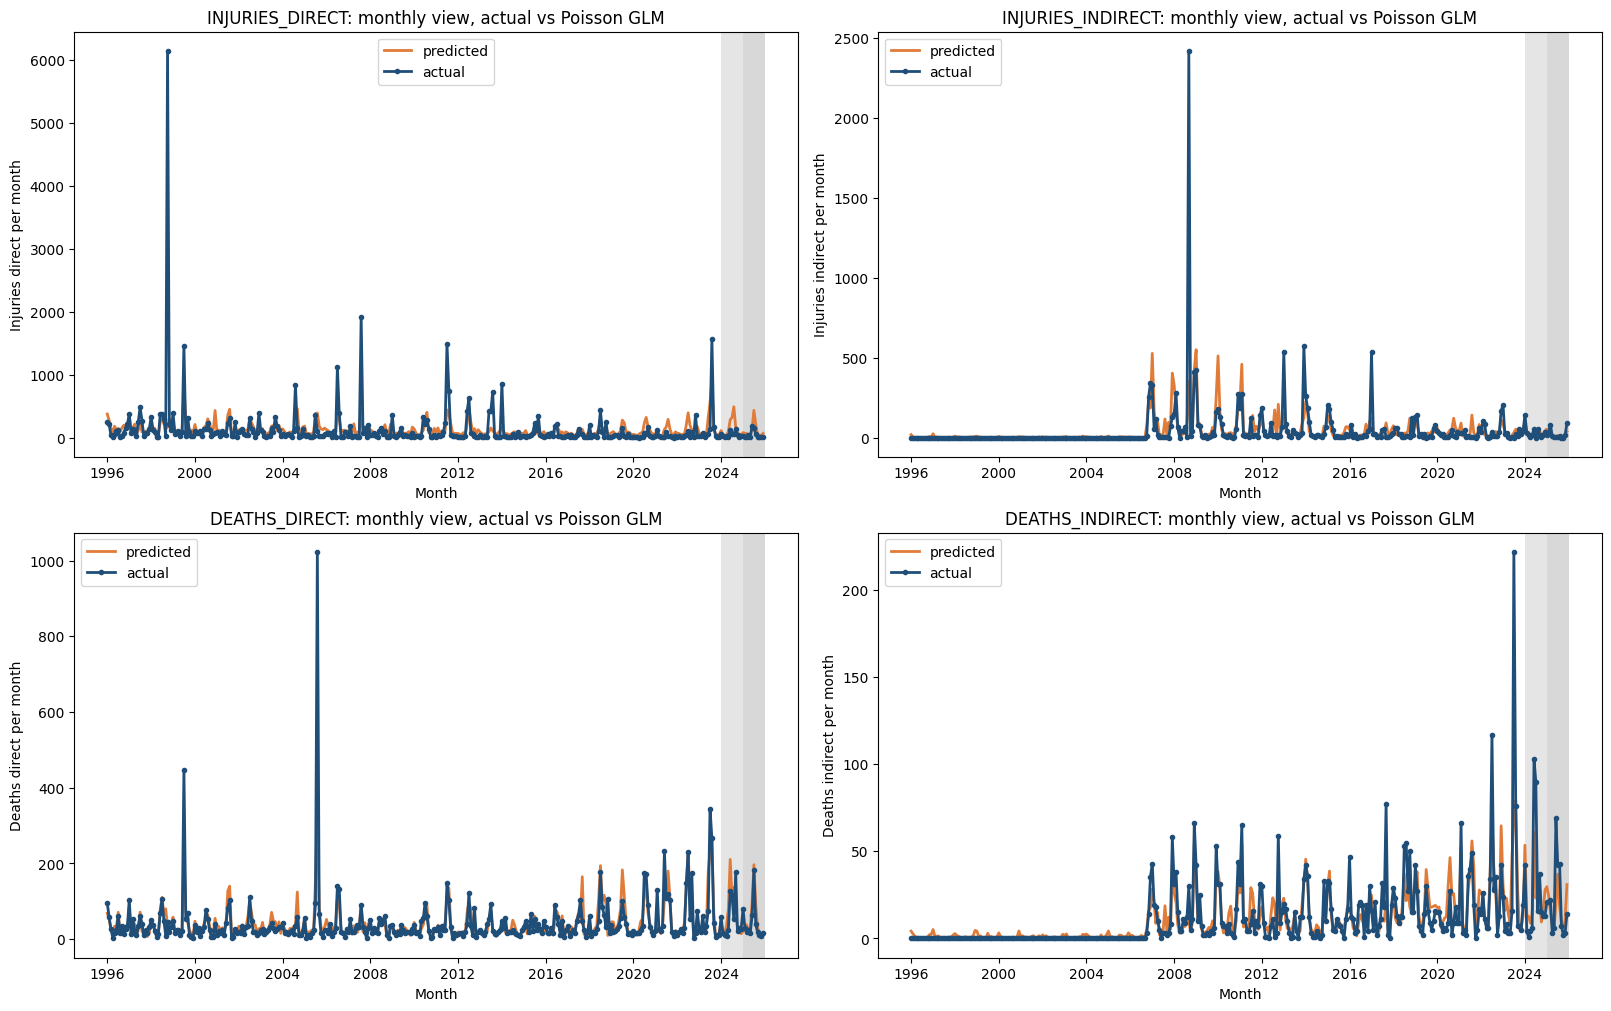

In [32]:
target_list=['INJURIES_DIRECT','INJURIES_INDIRECT','DEATHS_DIRECT','DEATHS_INDIRECT']
plot_monthly_actual_vs_predicted(forecast_results, target_list, model='GLM')

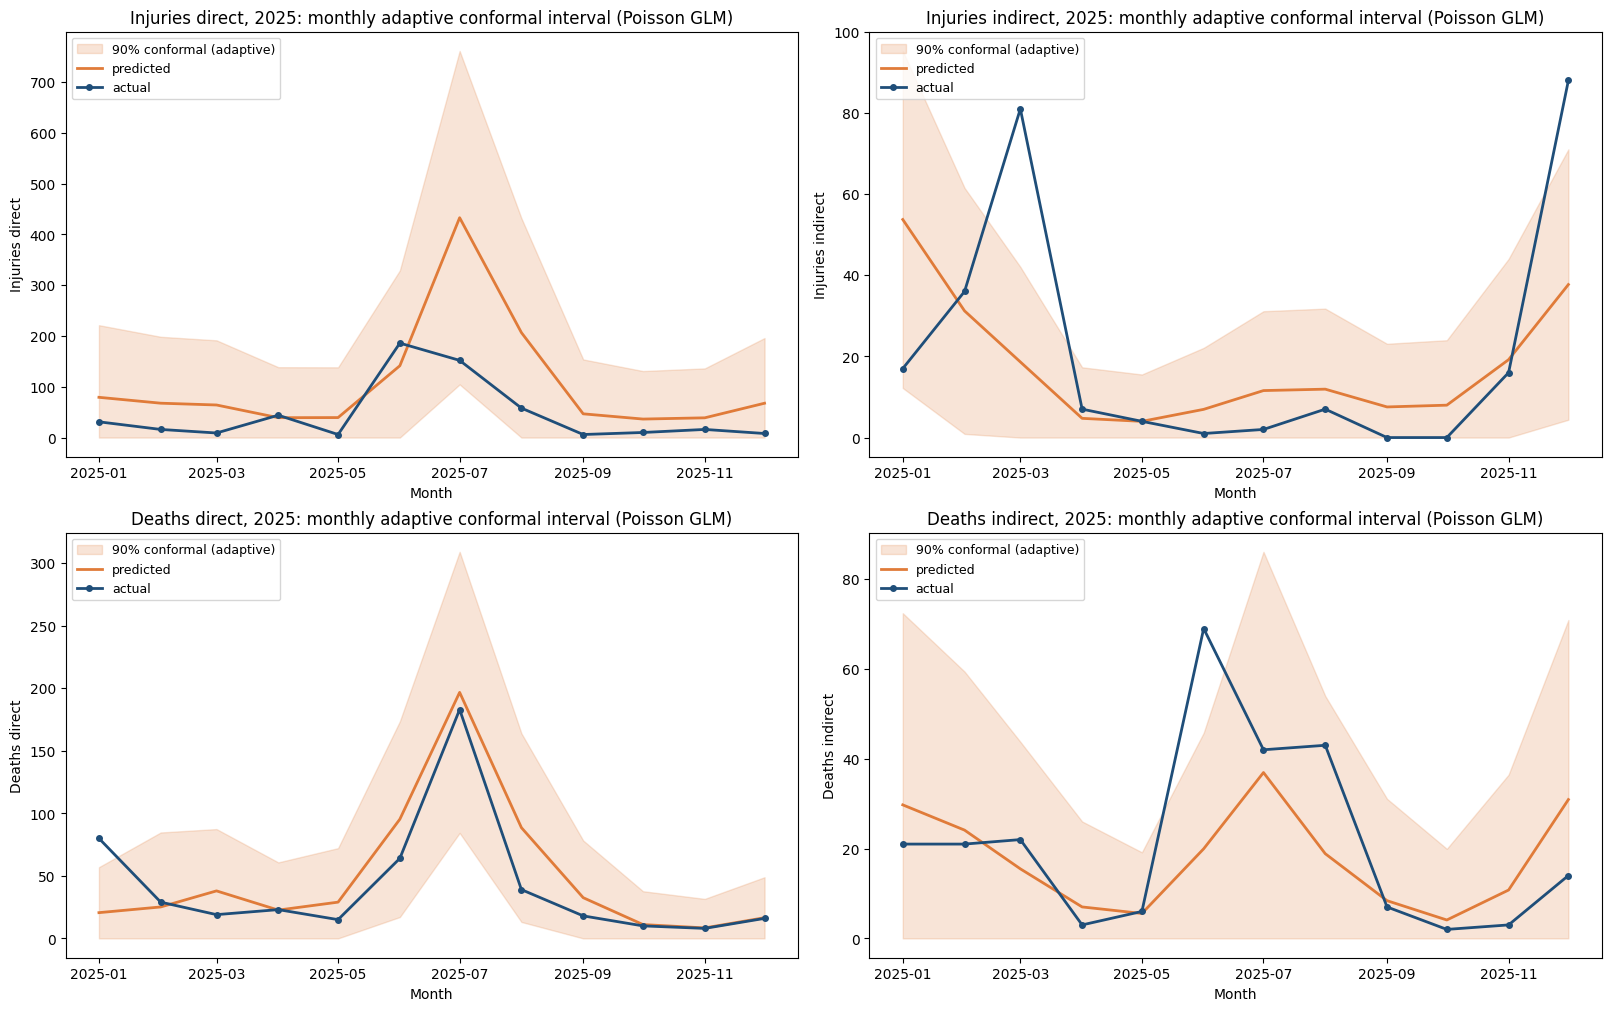

In [33]:
plot_conformal_monthly(forecast_results, target_list, model='GLM', test_year=2025)

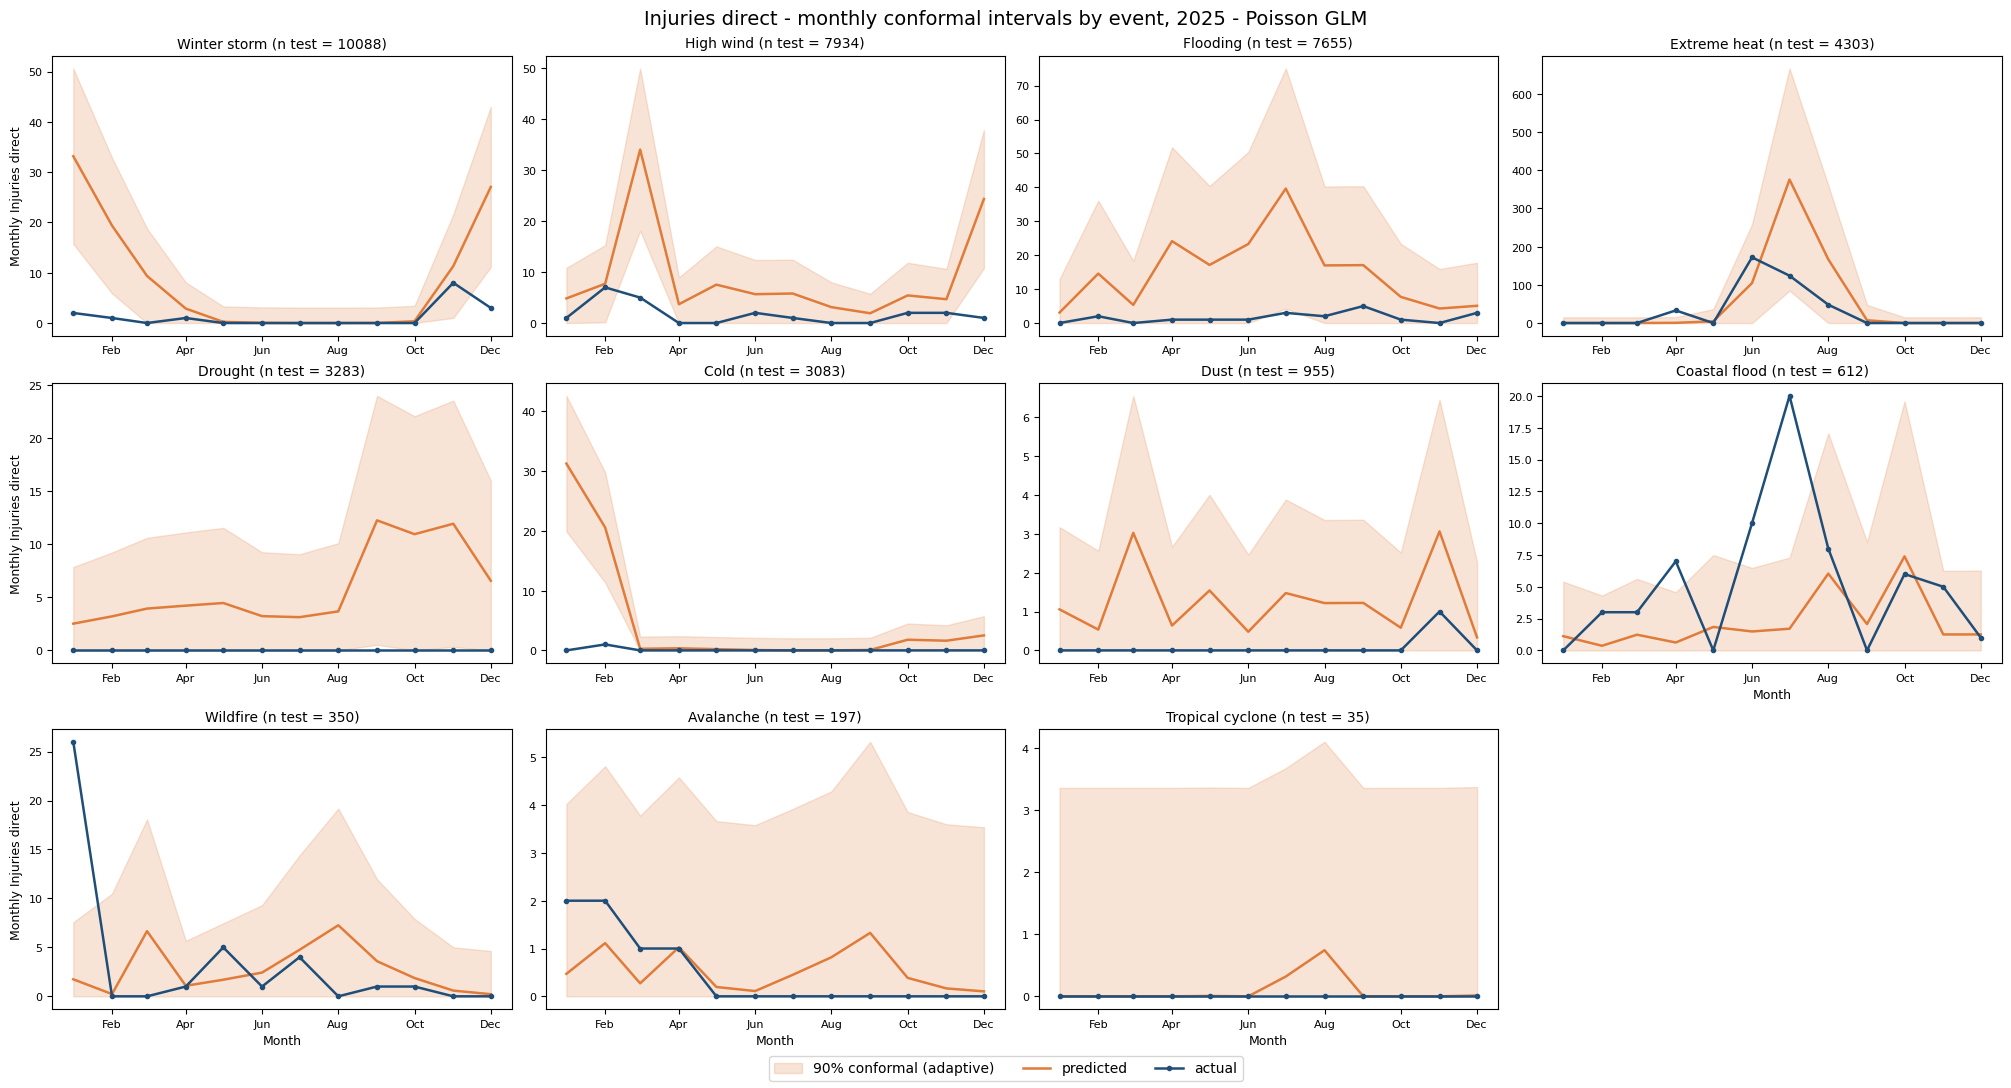

In [34]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES_DIRECT', model='GLM', test_year=2025)

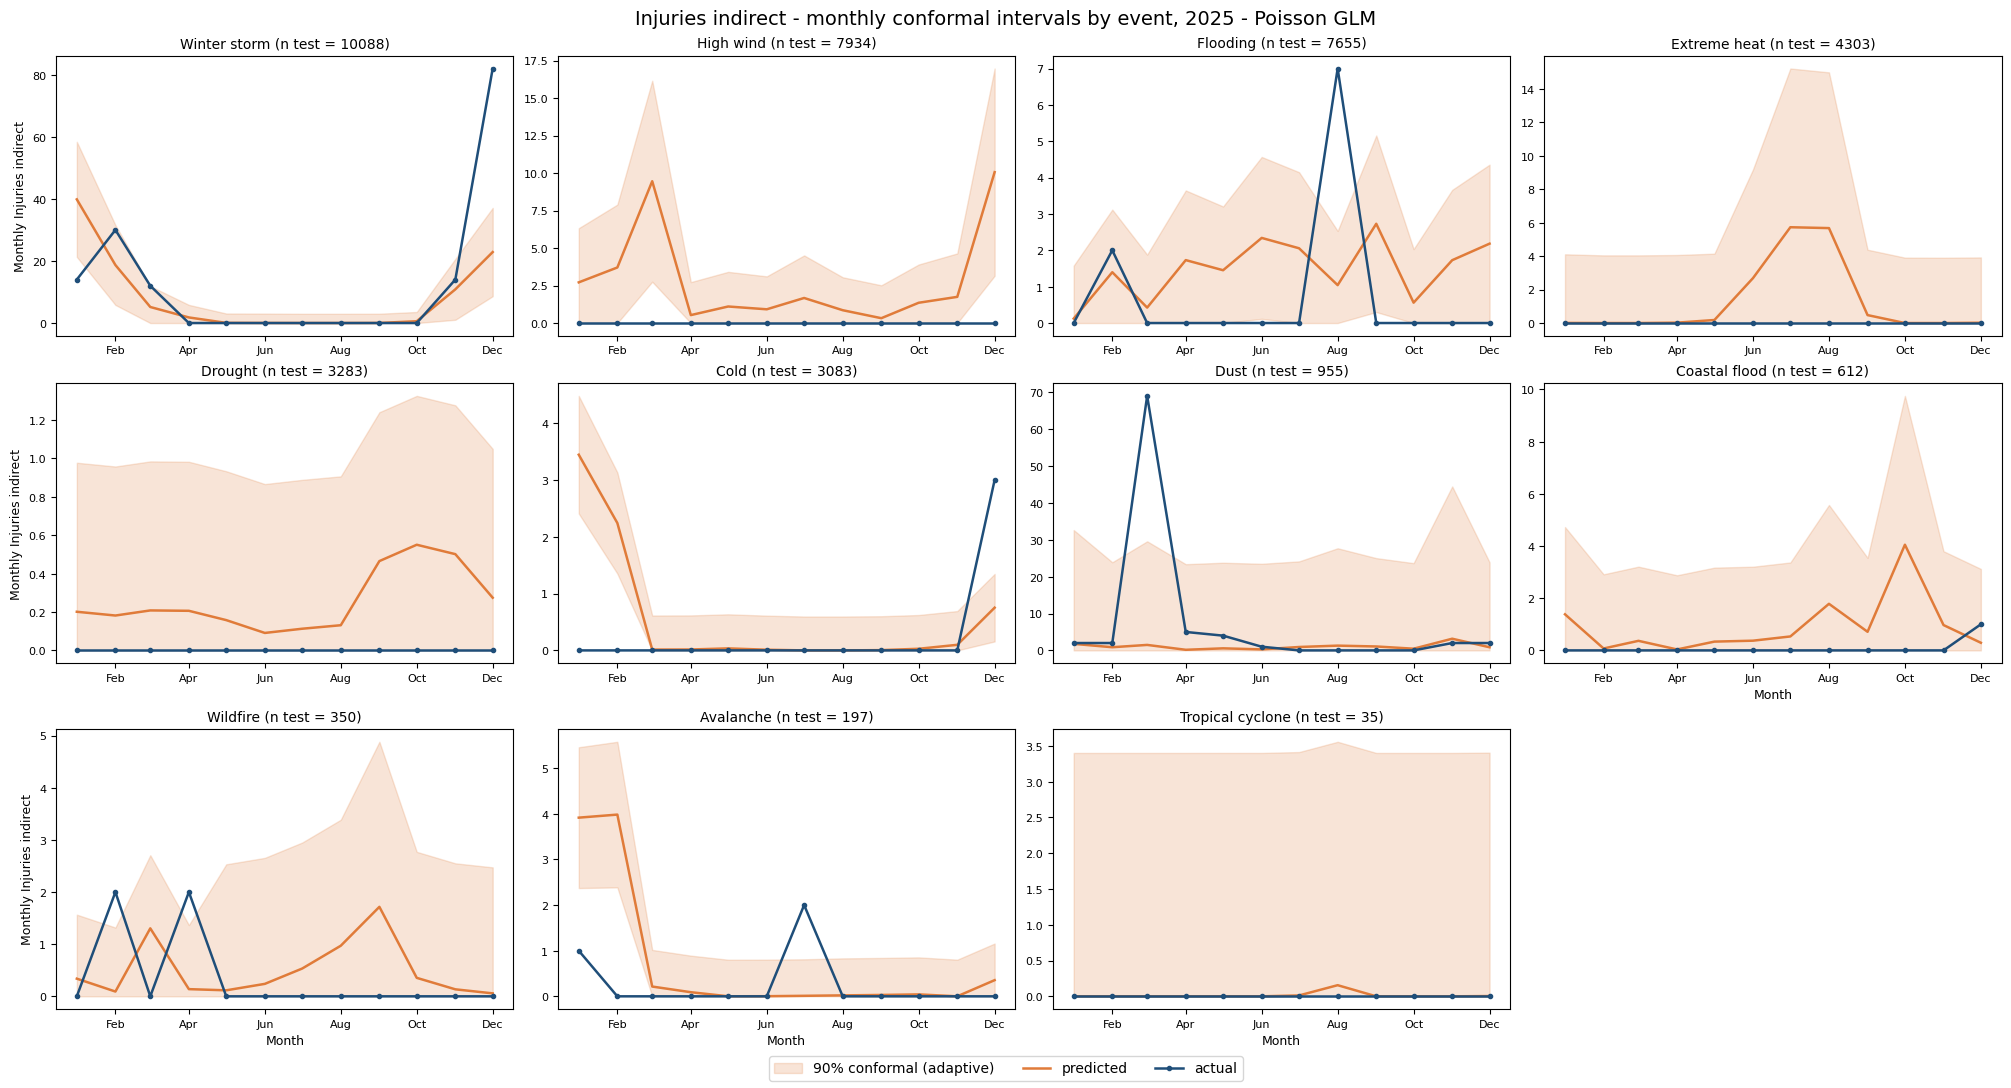

In [35]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES_INDIRECT', model='GLM', test_year=2025)

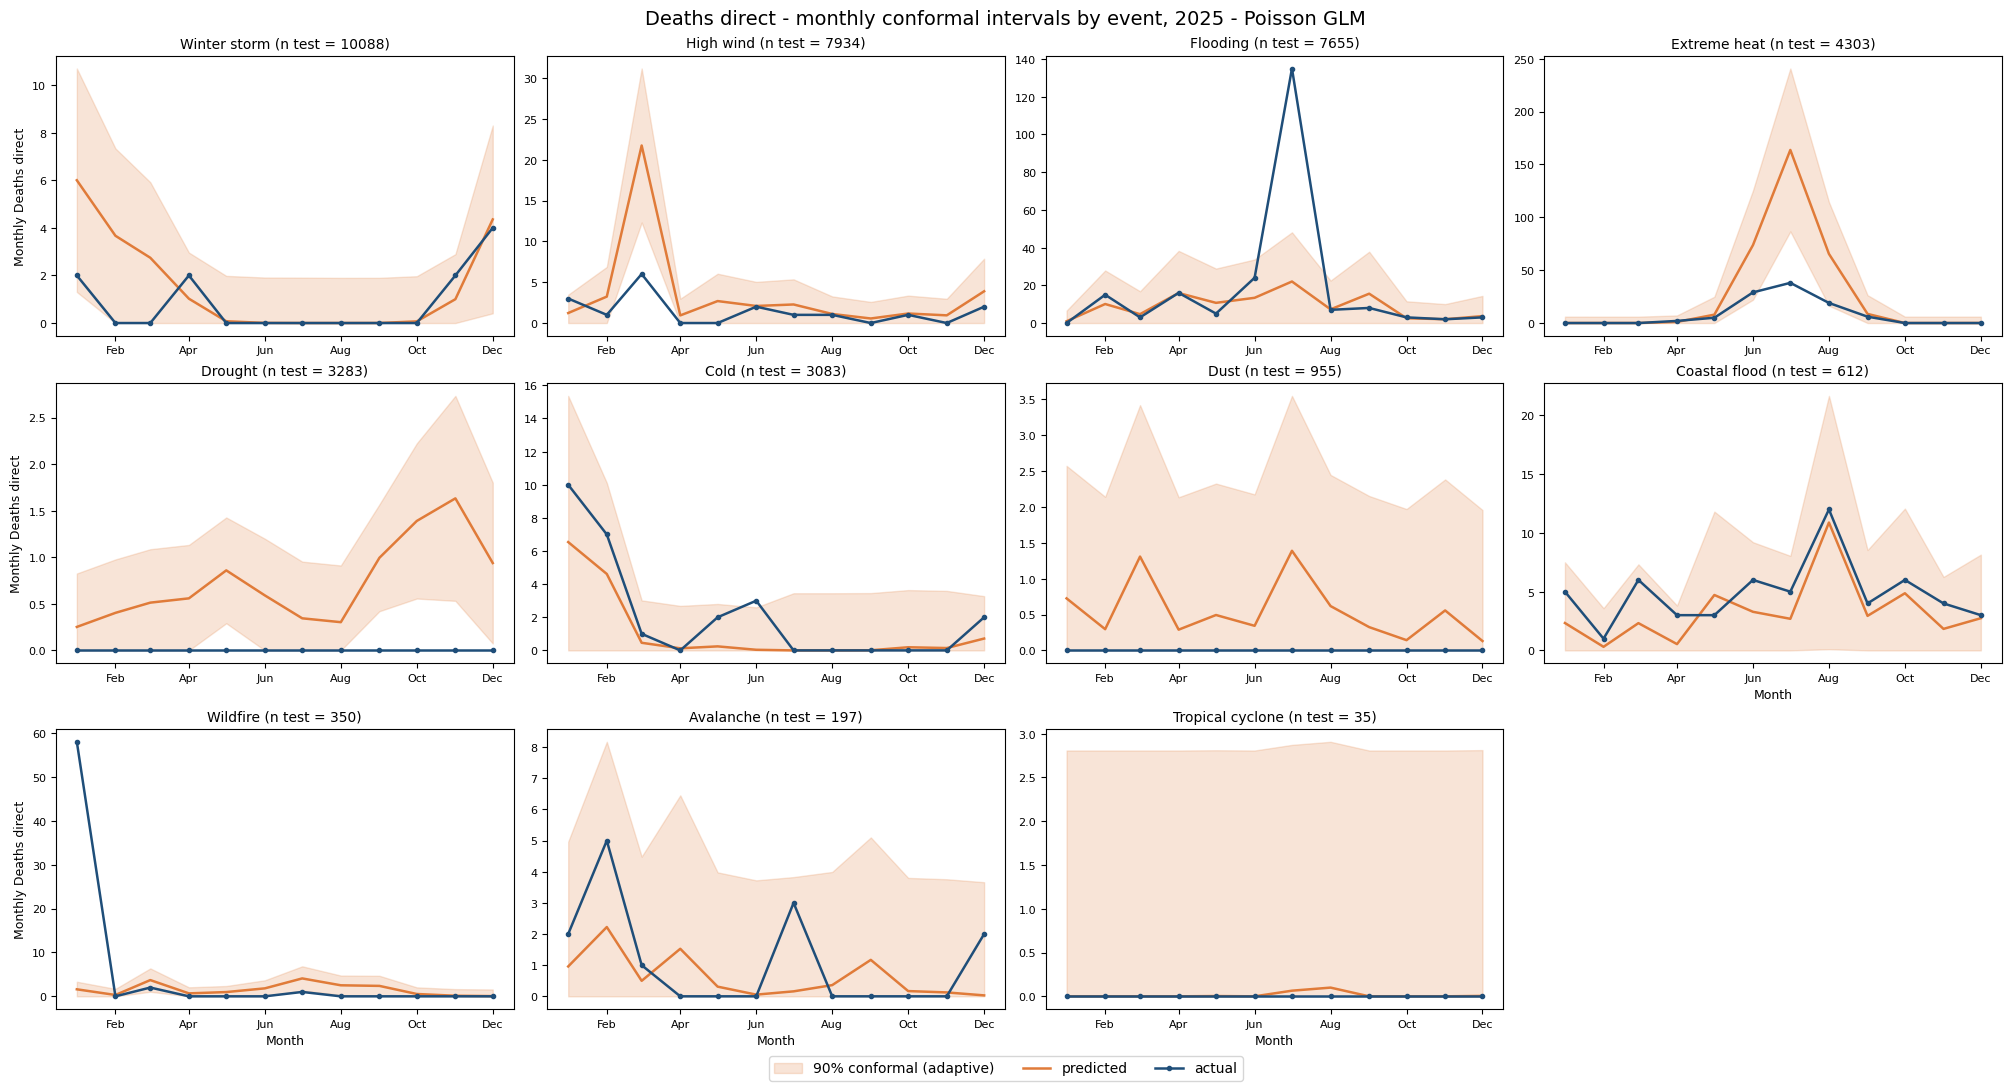

In [36]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS_DIRECT', model='GLM', test_year=2025)

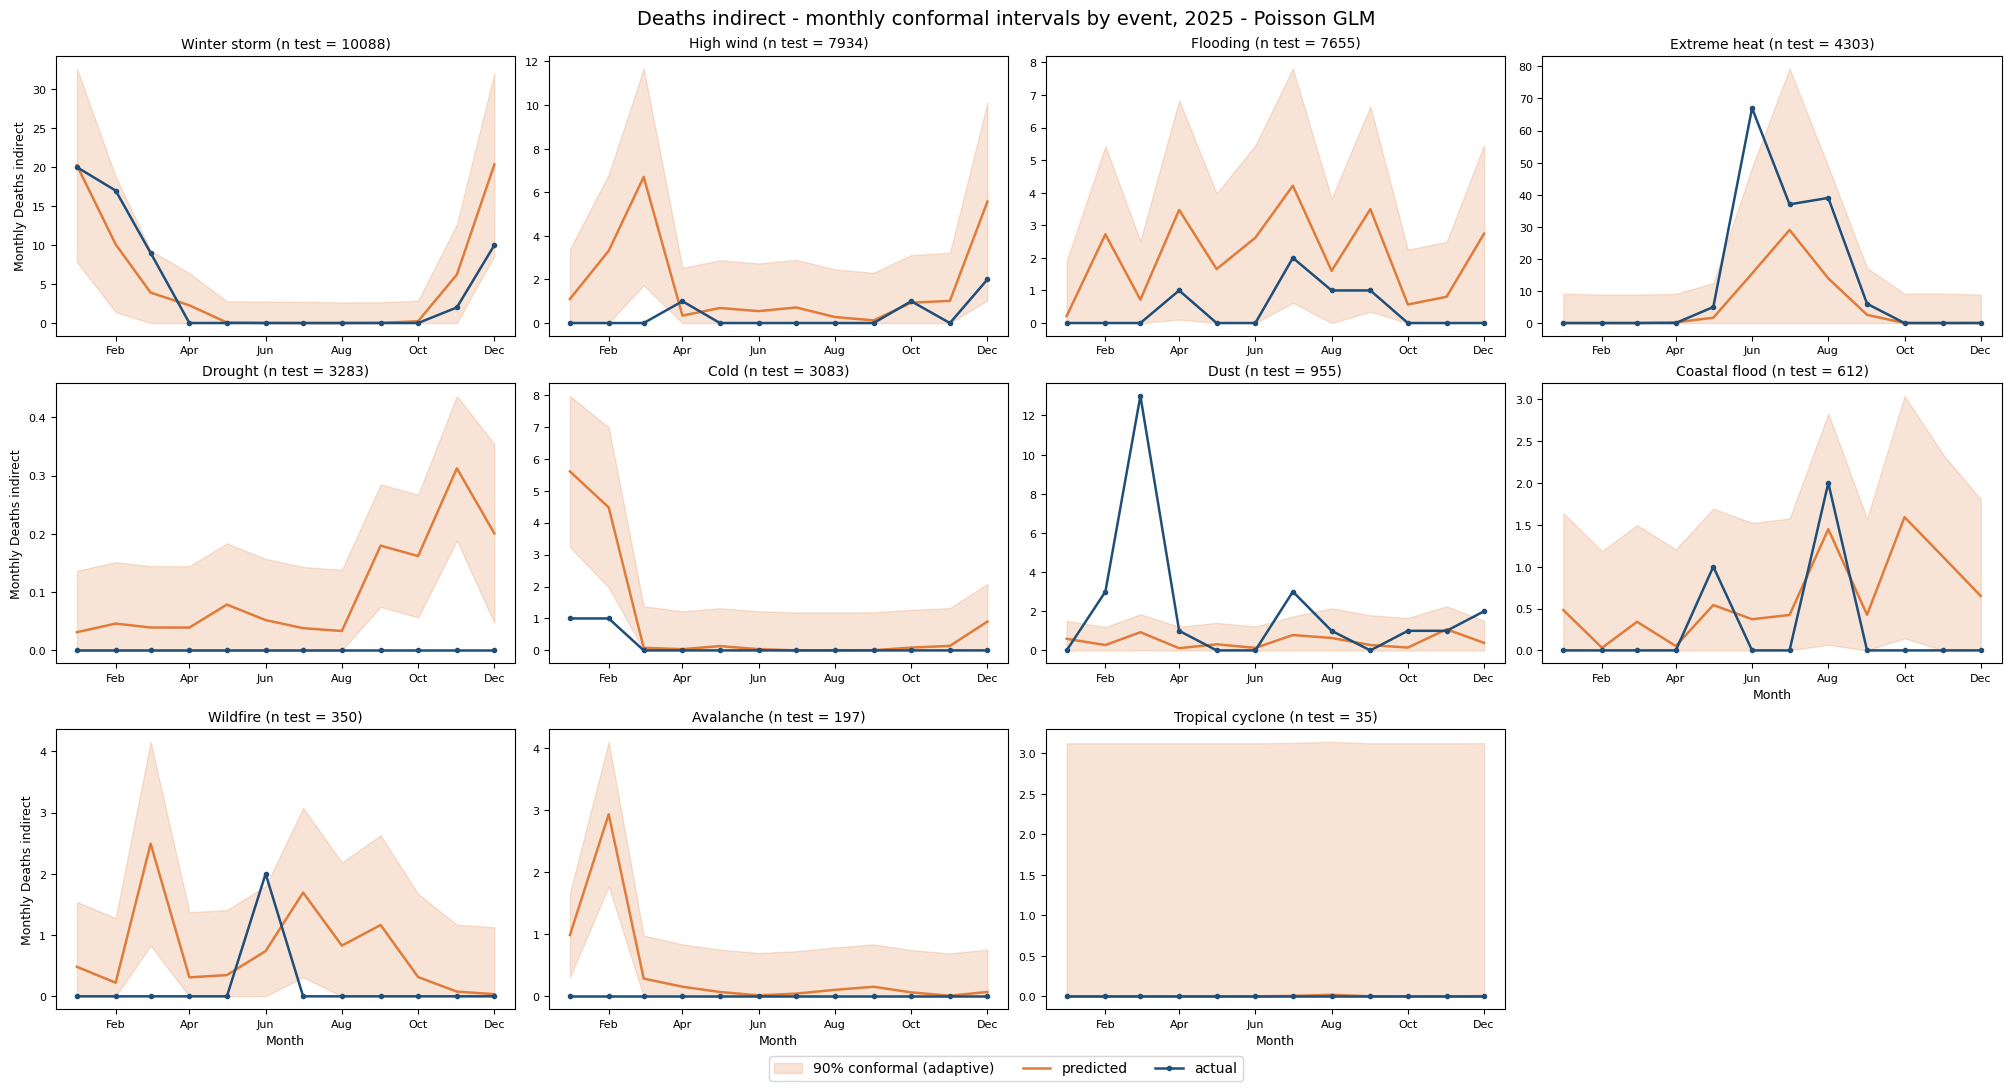

In [37]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS_INDIRECT', model='GLM', test_year=2025)

### Backtesting Results


 BACKTESTING FOR TARGET: INJURIES_DIRECT (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


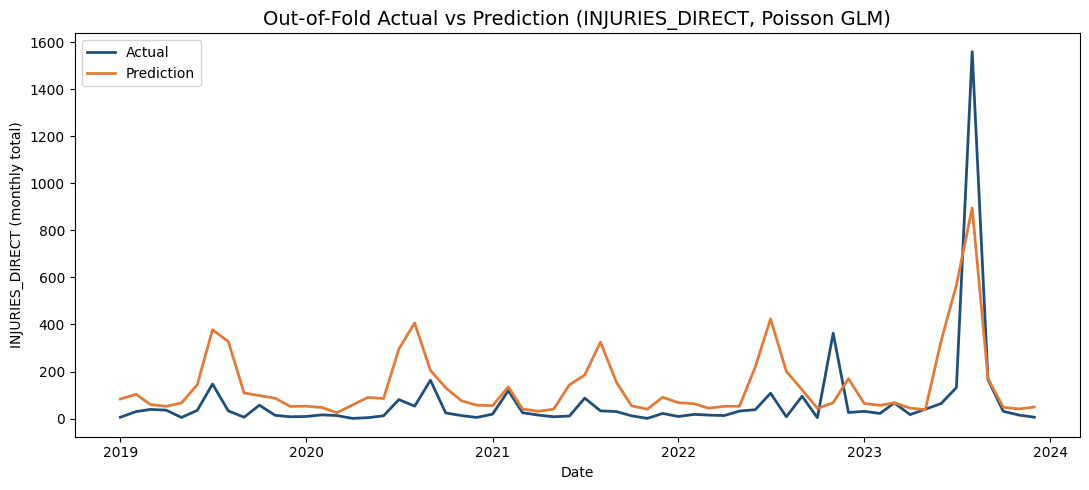

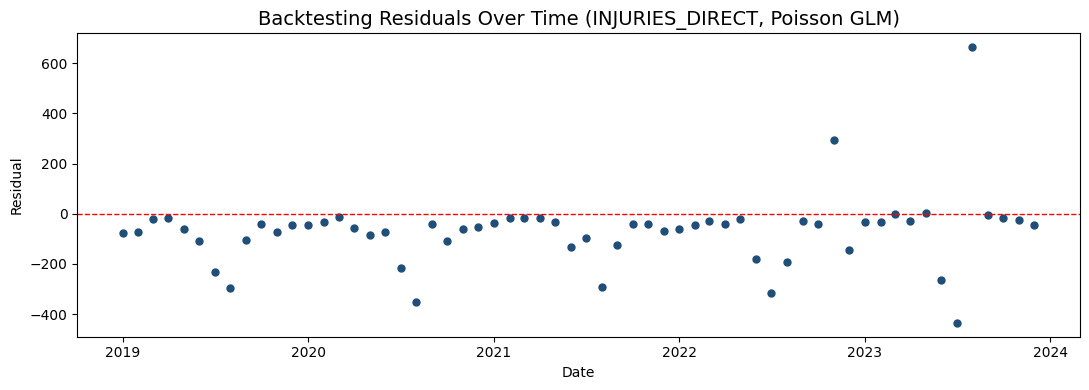

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,96,-0.0780,0.4541,0.1655
2020,31055,103,0.0094,0.6471,0.1723
2021,36224,101,-0.0085,0.6167,0.1494
2022,42173,120,0.0191,1.7522,0.2690
2023,39686,139,0.1000,4.7564,0.7742


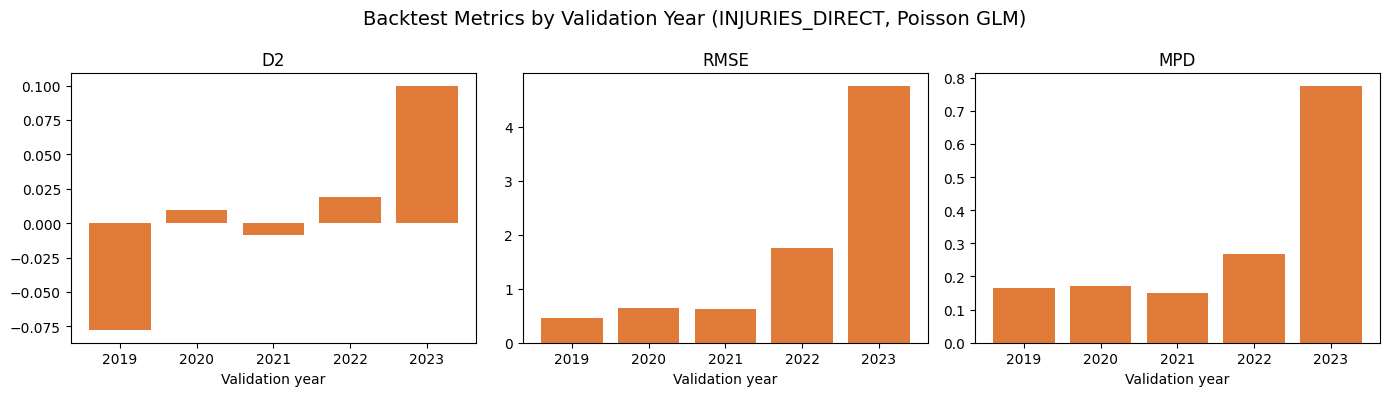

In [38]:
backtest_target_cv(
    train_events,
    'INJURIES_DIRECT',
    params=BEST_ALPHA['INJURIES_DIRECT'],
    model='GLM',
)


 BACKTESTING FOR TARGET: INJURIES_INDIRECT (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


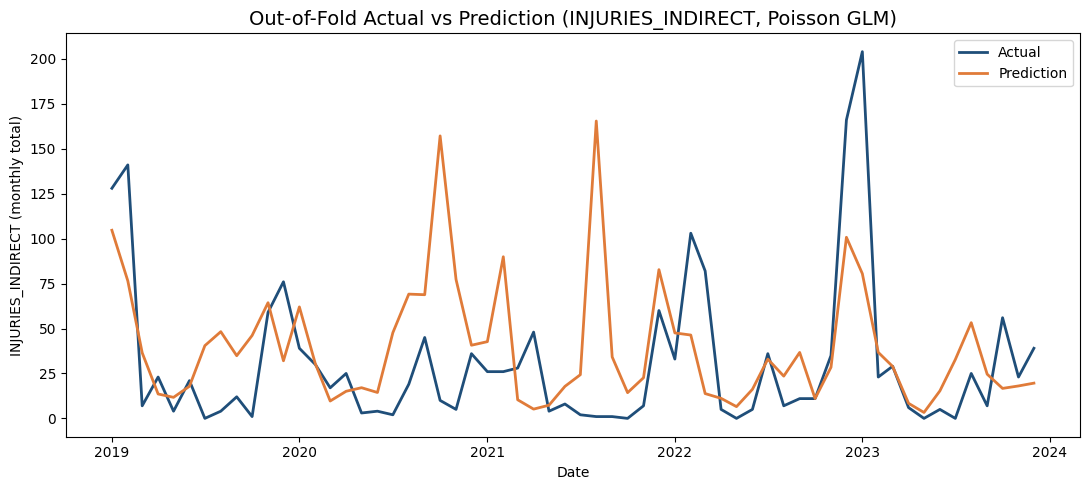

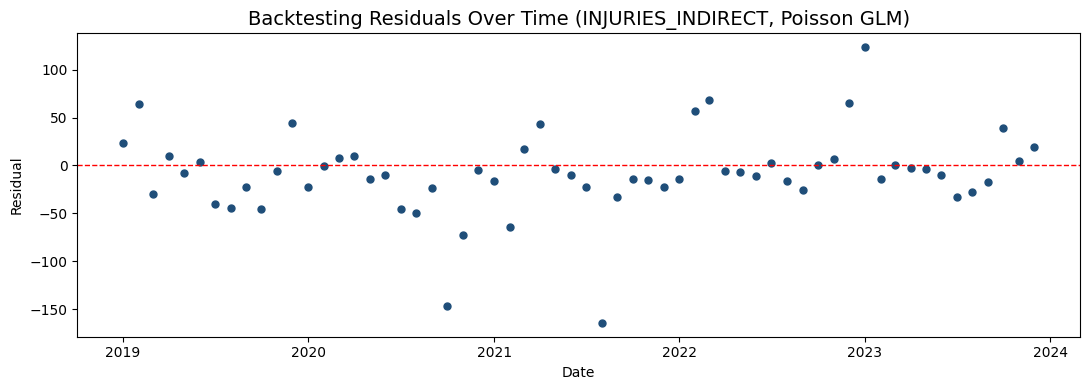

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,88,0.2542,0.6099,0.1359
2020,31055,76,0.1119,0.2770,0.0878
2021,36224,62,0.0923,0.3016,0.0740
2022,42173,120,0.1868,0.4929,0.1276
2023,39686,101,0.3990,0.4858,0.0876


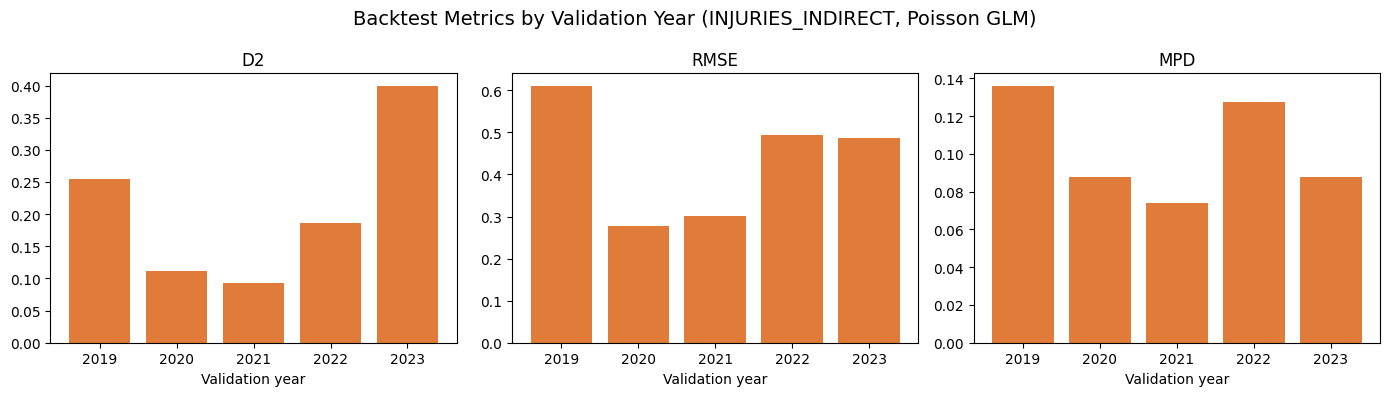

In [39]:
backtest_target_cv(
    train_events,
    'INJURIES_INDIRECT',
    params=BEST_ALPHA['INJURIES_INDIRECT'],
    model='GLM',
)


 BACKTESTING FOR TARGET: DEATHS_DIRECT (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


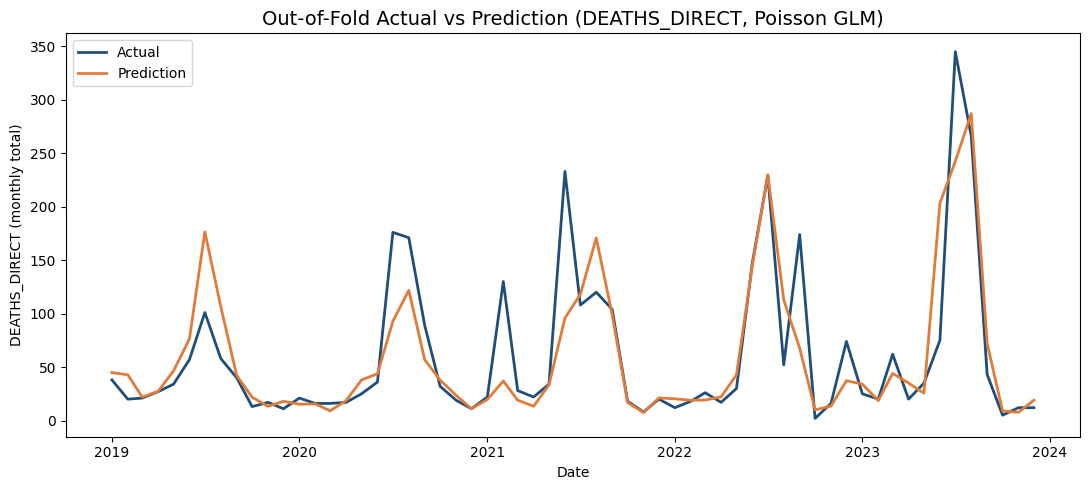

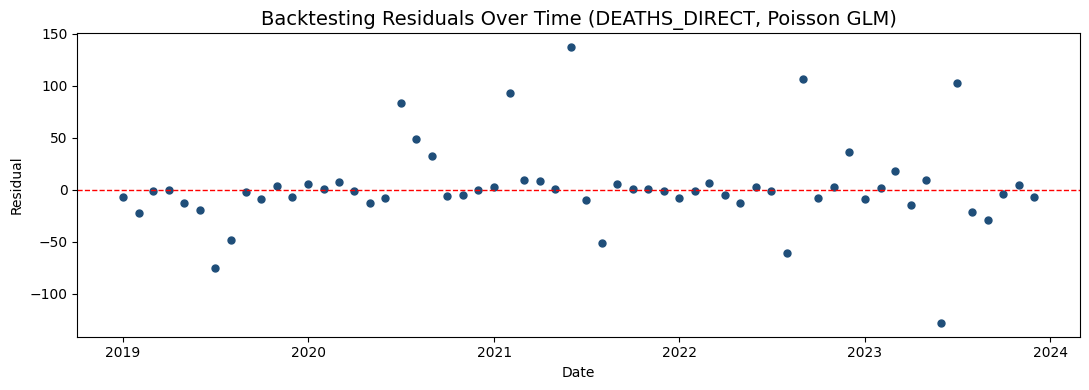

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,333,0.5009,0.1337,0.0579
2020,31055,300,0.5134,0.4194,0.1044
2021,36224,428,0.4448,0.5922,0.1341
2022,42173,353,0.4832,0.4791,0.1070
2023,39686,409,0.4684,0.7454,0.1362


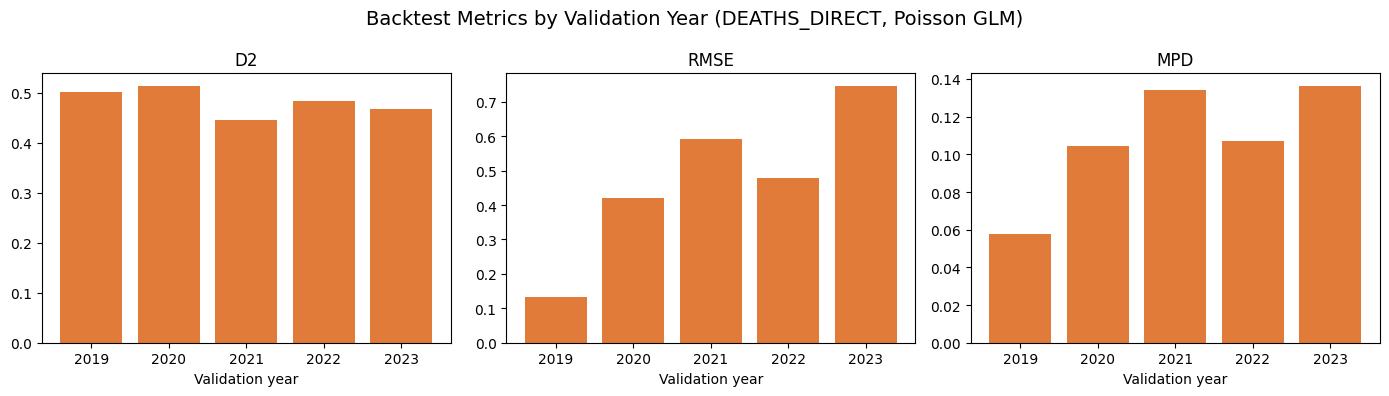

In [40]:
backtest_target_cv(
    train_events,
    'DEATHS_DIRECT',
    params=BEST_ALPHA['DEATHS_DIRECT'],
    model='GLM',
)


 BACKTESTING FOR TARGET: DEATHS_INDIRECT (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


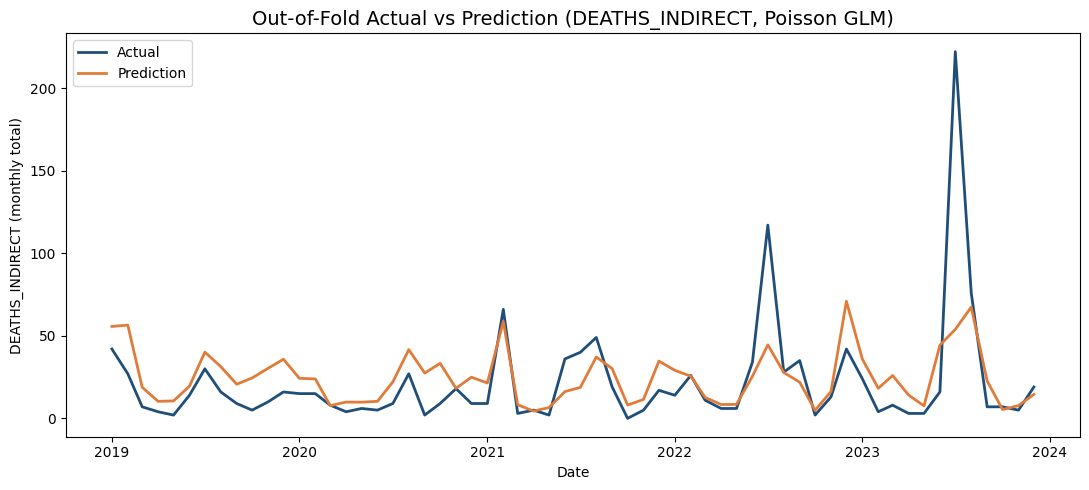

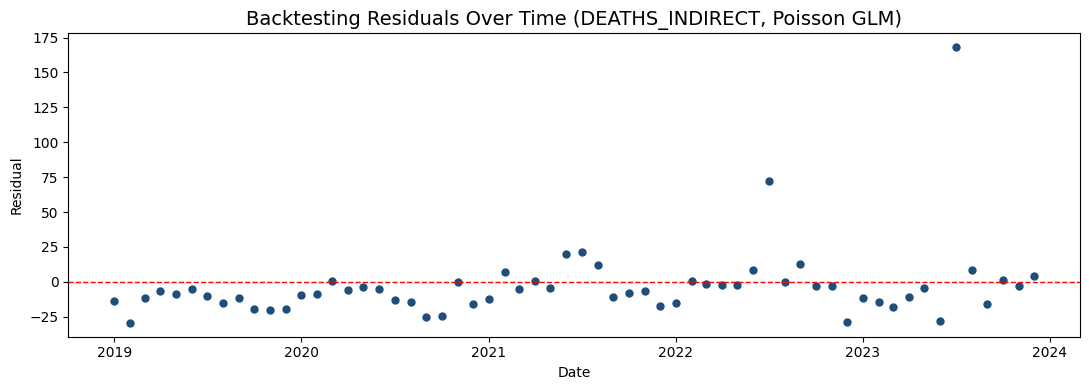

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,152,0.4293,0.0768,0.0316
2020,31055,87,0.2725,0.1067,0.0364
2021,36224,156,0.4969,0.1333,0.0396
2022,42173,188,0.5214,0.1528,0.0431
2023,39686,136,0.5010,0.3802,0.0640


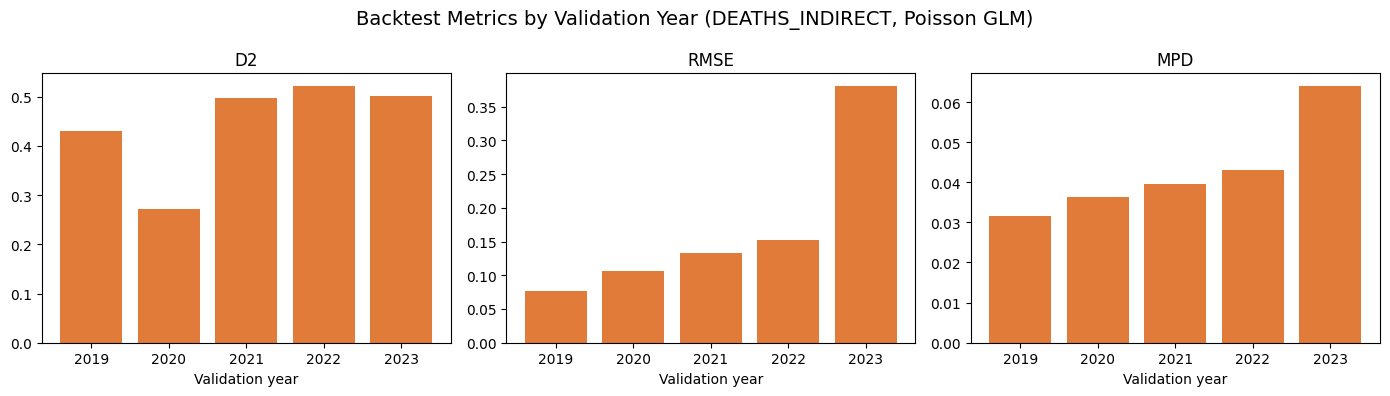

In [41]:
backtest_target_cv(
    train_events,
    'DEATHS_INDIRECT',
    params=BEST_ALPHA['DEATHS_INDIRECT'],
    model='GLM',
)

## LightGBM

### Fine-Tuning

### Fine-Tuning

In [ ]:
# To recalculate BEST_PARAMETERS with the yearly expanding-window CV, uncomment and run:
#BEST_PARAMETERS_LGBM_TUNED = find_best_parameters_for_all_targets(
#      train_events,
#      FORECAST_TARGETS,
#      model='LGBM',
#      validation_years=VALIDATION_YEARS,
#      n_trials=30,
#)
#print("New BEST_PARAMETERS dictionary:", BEST_PARAMETERS_LGBM_TUNED)

Tuning LightGBM Poisson for target INJURIES_DIRECT...
Precomputing 5 folds for INJURIES_DIRECT...
  best parameters: {'n_estimators': 600, 'learning_rate': 0.012392976260240626, 'num_leaves': 34, 'min_child_samples': 856, 'subsample': 0.8008040573999263, 'subsample_freq': 1, 'colsample_bytree': 0.8330108183029709, 'reg_lambda': 46.69146206664304, 'poisson_max_delta_step': 0.05193514357953946}
Tuning LightGBM Poisson for target INJURIES_INDIRECT...
Precomputing 5 folds for INJURIES_INDIRECT...
  best parameters: {'n_estimators': 600, 'learning_rate': 0.010152719335632082, 'num_leaves': 120, 'min_child_samples': 398, 'subsample': 0.6013799914199579, 'subsample_freq': 1, 'colsample_bytree': 0.7466309510841308, 'reg_lambda': 7.41797253582944, 'poisson_max_delta_step': 0.14406745143497132}
Tuning LightGBM Poisson for target DEATHS_DIRECT...
Precomputing 5 folds for DEATHS_DIRECT...
  best parameters: {'n_estimators': 700, 'learning_rate': 0.017114952121884797, 'num_leaves': 98, 'min_child_s

### Prediction

In [42]:
LGBM_INJ_DIR = {
    'n_estimators': 600,
    'learning_rate': 0.012392976260240626,
    'num_leaves': 34,
    'min_child_samples': 856,
    'subsample': 0.8008040573999263,
    'subsample_freq': 1,
    'colsample_bytree': 0.8330108183029709,
    'reg_lambda': 46.69146206664304,
    'poisson_max_delta_step': 0.05193514357953946
}

LGBM_INJ_INDIR = {
    'n_estimators': 700,
    'learning_rate': 0.017114952121884797,
    'num_leaves': 98,
    'min_child_samples': 698,
    'subsample': 0.7235906962260333,
    'subsample_freq': 1,
    'colsample_bytree': 0.9062952686854404,
    'reg_lambda': 2.6258203339573263,
    'poisson_max_delta_step': 0.30588323310541266
}

LGBM_DEATHS_DIR = {
    'n_estimators': 200,
    'learning_rate': 0.027142787723697524,
    'num_leaves': 86,
    'min_child_samples': 29,
    'subsample': 0.9351779629995216,
    'subsample_freq': 1,
    'colsample_bytree': 0.6384393631575852,
    'reg_lambda': 40.916103784514206,
    'poisson_max_delta_step': 0.1722282090449751,
}

LGBM_DEATHS_INDIR = {
    'n_estimators': 800,
    'learning_rate': 0.020905721708755313,
    'num_leaves': 15,
    'min_child_samples': 33,
    'subsample': 0.7226814358964372,
    'subsample_freq': 1,
    'colsample_bytree': 0.6809167492733863,
    'reg_lambda': 1.4037859096435004,
    'poisson_max_delta_step': 0.10219501382162036,
}

BEST_PARAMETERS = {
    'INJURIES_DIRECT': dict(LGBM_INJ_DIR),
    'INJURIES_INDIRECT': dict(LGBM_INJ_INDIR),
    'DEATHS_DIRECT': dict(LGBM_DEATHS_DIR),
    'DEATHS_INDIRECT': dict(LGBM_DEATHS_INDIR),
}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    FORECAST_TARGETS,
    best_params=BEST_PARAMETERS,
    model='LGBM',
    group_column=GROUP_COL,
)
lgbm_results = forecast_results

[LightGBM Poisson] fitting INJURIES_DIRECT...
[LightGBM Poisson] fitting INJURIES_INDIRECT...
[LightGBM Poisson] fitting DEATHS_DIRECT...
[LightGBM Poisson] fitting DEATHS_INDIRECT...


### Reporting Results

In [43]:
display(point_metrics_by_target(forecast_results, model='LGBM').round(4))

n  events      D2    RMSE     MPD
Target            Split                                              
DEATHS_DIRECT     train        812807    7724  0.7683  0.1669  0.0431
                  calibration   37371     394  0.5297  0.2212  0.0822
                  test          38495     271  0.4545  0.4339  0.0824
DEATHS_INDIRECT   train        812807    2313  0.7489  0.0734  0.0135
                  calibration   37371     168  0.5146  0.2018  0.0525
                  test          38495     154  0.5112  0.1285  0.0370
INJURIES_DIRECT   train        812807    5018  0.8254  0.9352  0.1250
                  calibration   37371     147  0.2560  0.5493  0.1453
                  test          38495     104  0.2612  1.0056  0.1557
INJURIES_INDIRECT train        812807    2238  0.9486  0.5579  0.0132
                  calibration   37371      87  0.3328  0.4319  0.0937
                  test          38495      82  0.4375  0.2954  0.0514

In [44]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES_DIRECT', model='LGBM').round(4))

n  events      D2    RMSE  \
Target          Split       EVENT_GROUP                                        
INJURIES_DIRECT train       Avalanche           2980     204  0.6461  1.0090   
                            Coastal_Flood      22805     572  0.5361  0.5774   
                            Cold               46823      77  0.6262  0.2038   
                            Drought            74627       2  0.7491  1.2172   
                            Dust               17849     168  0.7253  0.8955   
                            Extreme_Heat       45943     802  0.8634  2.4855   
                            Flooding          165876     694  0.8750  0.9090   
                            High_Wind         152517    1051  0.4535  0.3284   
                            Tropical_Cyclone   11397     162  0.8305  2.0589   
                            Wildfire            8787     515  0.5332  1.5603   
                            Winter_Storm      263203     771  0.7500  0.5022   
                calibration Avalanche            197      13 -0.2631  0.5067   
                            Coastal_Flood        791      31  0.5122  0.3176   
                            Cold                1844       2 -0.2092  0.3955   
                            Drought             3473       0     NaN  0.0033   
                            Dust                 934       4  0.3888  0.1198   
                            Extreme_Heat        5831      22  0.1897  0.7997   
                            Flooding            7134      11 -0.1627  0.0809   
                            High_Wind           7564      31  0.3322  0.1014   
                            Tropical_Cyclone     813       8 -0.0607  2.7071   
                            Wildfire             336      12  0.1058  1.3763   
                            Winter_Storm        8454      13  0.3373  0.2158   
                test        Avalanche            197       6  0.5107  0.1401   
                            Coastal_Flood        612      30  0.3142  0.5687   
                            Cold                3083       1 -0.5253  0.0205   
                            Drought             3283       0     NaN  0.0039   
                            Dust                 955       1 -1.1433  0.0641   
                            Extreme_Heat        4303      12  0.0463  2.9879   
                            Flooding            7655      15  0.1122  0.0620   
                            High_Wind           7934      17  0.2413  0.0608   
                            Tropical_Cyclone      35       0     NaN  0.4960   
                            Wildfire             350      12  0.2489  0.7738   
                            Winter_Storm       10088      10  0.1847  0.0512   

                                                 MPD  
Target          Split       EVENT_GROUP               
INJURIES_DIRECT train       Avalanche         0.4848  
                            Coastal_Flood     0.2230  
                            Cold              0.0378  
                            Drought           0.0266  
                            Dust              0.2223  
                            Extreme_Heat      0.5705  
                            Flooding          0.1026  
                            High_Wind         0.0888  
                            Tropical_Cyclone  0.4062  
                            Wildfire          0.8549  
                            Winter_Storm      0.0702  
                calibration Avalanche         0.5752  
                            Coastal_Flood     0.2032  
                            Cold              0.2149  
                            Drought           0.0038  
                            Dust              0.0510  
                            Extreme_Heat      0.3675  
                            Flooding          0.0368  
                            High_Wind         0.0426  
                            Tropical_Cyclone  1.4014  
                            Wildfire    

In [45]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES_INDIRECT', model='LGBM').round(4))

n  events      D2  \
Target            Split       EVENT_GROUP                                
INJURIES_INDIRECT train       Avalanche           2980       9  0.2118   
                              Coastal_Flood      22805      13  0.3713   
                              Cold               46823      36  0.8966   
                              Drought            74627       2  0.6170   
                              Dust               17849     194  0.9546   
                              Extreme_Heat       45943      40  0.9151   
                              Flooding          165876      72  0.6558   
                              High_Wind         152517     125  0.9037   
                              Tropical_Cyclone   11397      20  0.9931   
                              Wildfire            8787     111  0.8846   
                              Winter_Storm      263203    1616  0.9343   
                  calibration Avalanche            197       1  0.2641   
                              Coastal_Flood        791       3  0.0440   
                              Cold                1844       2  0.6737   
                              Drought             3473       0     NaN   
                              Dust                 934      20  0.1797   
                              Extreme_Heat        5831       5 -0.1774   
                              Flooding            7134       1 -0.1036   
                              High_Wind           7564       9  0.4558   
                              Tropical_Cyclone     813       5 -0.1243   
                              Wildfire             336       1  0.3817   
                              Winter_Storm        8454      40  0.3751   
                  test        Avalanche            197       2 -0.1223   
                              Coastal_Flood        612       1  0.2427   
                              Cold                3083       2  0.5171   
                              Drought             3283       0     NaN   
                              Dust                 955      14  0.4507   
                              Extreme_Heat        4303       0     NaN   
                              Flooding            7655       3 -0.0096   
                              High_Wind           7934       0     NaN   
                              Tropical_Cyclone      35       0     NaN   
                              Wildfire             350       2 -0.1071   
                              Winter_Storm       10088      58  0.2868   

                                                  RMSE     MPD  
Target            Split       EVENT_GROUP                       
INJURIES_INDIRECT train       Avalanche         0.0734  0.0341  
                              Coastal_Flood     0.0308  0.0066  
                              Cold              0.0516  0.0041  
                              Drought           0.0108  0.0004  
                              Dust              0.2052  0.0323  
                              Extreme_Heat      0.2582  0.0093  
                              Flooding          0.0335  0.0042  
                              High_Wind         0.0550  0.0062  
                              Tropical_Cyclone  4.5765  0.0277  
                              Wildfire          0.2864  0.0682  
                              Winter_Storm      0.1842  0.0254  
                  calibration Avalanche         0.0778  0.0395  
                              Coastal_Flood     0.2489  0.1510  
                              Cold              0.0378  0.0048  
                              Drought           0.0001  0.0001  
                              Dust              1.8451  1.0890  
                              Extreme_Heat      0.3619  0.1485  
                              Flooding          0.0238  0.0055  
                              High_Wind         0.0587  0.0138  
                              Tropical_Cyclone  0.1609  0.1303  
                              Wi

In [46]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS_DIRECT', model='LGBM').round(4))

n  events      D2    RMSE  \
Target        Split       EVENT_GROUP                                        
DEATHS_DIRECT train       Avalanche           2980     369  0.6691  0.4675   
                          Coastal_Flood      22805    1407  0.8046  0.2103   
                          Cold               46823     645  0.7541  0.1655   
                          Drought            74627       0     NaN  0.0014   
                          Dust               17849      66  0.4375  0.1396   
                          Extreme_Heat       45943    2092  0.8357  0.4296   
                          Flooding          165876    1620  0.5192  0.1709   
                          High_Wind         152517     618  0.5214  0.0818   
                          Tropical_Cyclone   11397     205  0.9141  0.4477   
                          Wildfire            8787     118  0.7639  0.4033   
                          Winter_Storm      263203     584  0.5140  0.0700   
              calibration Avalanche            197      13  0.2289  0.9523   
                          Coastal_Flood        791      67  0.7992  0.2052   
                          Cold                1844      35  0.5113  0.1892   
                          Drought             3473       0     NaN  0.0012   
                          Dust                 934       1  0.4166  0.0615   
                          Extreme_Heat        5831     132  0.7323  0.2951   
                          Flooding            7134      70  0.1915  0.3158   
                          High_Wind           7564      22  0.3796  0.0765   
                          Tropical_Cyclone     813      31  0.0523  0.4369   
                          Wildfire             336       7  0.2489  0.1843   
                          Winter_Storm        8454      16  0.2734  0.1172   
              test        Avalanche            197      11  0.3647  0.2714   
                          Coastal_Flood        612      56  0.7283  0.1853   
                          Cold                3083      23  0.6689  0.0775   
                          Drought             3283       0     NaN  0.0013   
                          Dust                 955       0     NaN  0.0469   
                          Extreme_Heat        4303      75  0.6511  0.2156   
                          Flooding            7655      74  0.2871  0.8924   
                          High_Wind           7934      15  0.3411  0.0511   
                          Tropical_Cyclone      35       0     NaN  0.0101   
                          Wildfire             350       7 -0.0630  1.5702   
                          Winter_Storm       10088      10  0.2516  0.0318   

                                               MPD  
Target        Split       EVENT_GROUP               
DEATHS_DIRECT train       Avalanche         0.3030  
                          Coastal_Flood     0.0813  
                          Cold              0.0396  
                          Drought           0.0019  
                          Dust              0.0413  
                          Extreme_Heat      0.1340  
                          Flooding          0.0701  
                          High_Wind         0.0272  
                          Tropical_Cyclone  0.1380  
                          Wildfire          0.1345  
                          Winter_Storm      0.0184  
              calibration Avalanche         0.7028  
                          Coastal_Flood     0.0956  
                          Cold              0.1030  
                          Drought           0.0016  
                          Dust              0.0171  
                          Extreme_Heat      0.0953  
                          Flooding          0.1636  
                          High_Wind         0.0263  
                          Tropical_Cyclone  0.4793  
                          Wildfire          0.1581  
                          Winter_Storm      0.0331  
              test        Avalanche         0.

In [47]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS_INDIRECT', model='LGBM').round(4))

n  events      D2    RMSE  \
Target          Split       EVENT_GROUP                                        
DEATHS_INDIRECT train       Avalanche           2980      10  0.1511  0.0715   
                            Coastal_Flood      22805      26  0.3476  0.0409   
                            Cold               46823      96  0.6849  0.0572   
                            Drought            74627       0     NaN  0.0002   
                            Dust               17849     152  0.7717  0.1189   
                            Extreme_Heat       45943     479  0.8835  0.1723   
                            Flooding          165876     101  0.5307  0.0293   
                            High_Wind         152517     120  0.6720  0.0361   
                            Tropical_Cyclone   11397     103  0.7924  0.2127   
                            Wildfire            8787      43  0.5725  0.0936   
                            Winter_Storm      263203    1183  0.6529  0.0786   
                calibration Avalanche            197       0     NaN  0.0250   
                            Coastal_Flood        791       1  0.2247  0.0377   
                            Cold                1844       3  0.5013  0.0480   
                            Drought             3473       0     NaN  0.0001   
                            Dust                 934      12  0.4810  0.1898   
                            Extreme_Heat        5831      82  0.5349  0.4676   
                            Flooding            7134       8  0.1684  0.0390   
                            High_Wind           7564      10  0.4260  0.0661   
                            Tropical_Cyclone     813      18  0.0235  0.3676   
                            Wildfire             336       1  0.5093  0.0362   
                            Winter_Storm        8454      33  0.2190  0.0794   
                test        Avalanche            197       0     NaN  0.0182   
                            Coastal_Flood        612       3  0.2321  0.0704   
                            Cold                3083       2  0.3868  0.0259   
                            Drought             3283       0     NaN  0.0001   
                            Dust                 955      11  0.4947  0.3178   
                            Extreme_Heat        4303      88  0.4648  0.3088   
                            Flooding            7655       5  0.2067  0.0255   
                            High_Wind           7934       4  0.1885  0.0234   
                            Tropical_Cyclone      35       0     NaN  0.0016   
                            Wildfire             350       1  0.5251  0.1031   
                            Winter_Storm       10088      40  0.3075  0.1047   

                                                 MPD  
Target          Split       EVENT_GROUP               
DEATHS_INDIRECT train       Avalanche         0.0359  
                            Coastal_Flood     0.0117  
                            Cold              0.0107  
                            Drought           0.0001  
                            Dust              0.0284  
                            Extreme_Heat      0.0260  
                            Flooding          0.0052  
                            High_Wind         0.0057  
                            Tropical_Cyclone  0.0510  
                            Wildfire          0.0316  
                            Winter_Storm      0.0220  
                calibration Avalanche         0.0125  
                            Coastal_Flood     0.0131  
                            Cold              0.0104  
                            Drought           0.0001  
                            Dust              0.0951  
                            Extreme_Heat      0.1713  
                            Flooding          0.0143  
                            High_Wind         0.0146  
                            Tropical_Cyclone  0.3388  
                            Wildfire    

In [48]:
display(daily_conformal_summary(forecast_results, model='LGBM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS_DIRECT,365,0.9288,1.3808,2.4969,1.8082
DEATHS_INDIRECT,365,0.9014,0.6932,2.1077,3.0408
INJURIES_DIRECT,365,0.9370,1.4849,2.8312,1.9066
INJURIES_INDIRECT,365,0.9068,0.7096,1.6903,2.3820


In [49]:
display(event_monthly_conformal_summary(forecast_results, model='LGBM').round(4))

Months  TestRecords  Coverage  MeanActual  \
Target            EVENT_GROUP                                                   
DEATHS_DIRECT     Avalanche             12          197    0.9167      1.0833   
                  Coastal_Flood         12          612    1.0000      4.8333   
                  Cold                  12         3083    0.9167      2.0833   
                  Drought               12         3283    0.8333      0.0000   
                  Dust                  12          955    0.9167      0.0000   
                  Extreme_Heat          12         4303    0.9167      8.2500   
                  Flooding              12         7655    0.8333     18.4167   
                  High_Wind             12         7934    0.9167      1.4167   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.9167      5.0833   
                  Winter_Storm          12        10088    0.9167      0.8333   
DEATHS_INDIRECT   Avalanche             12          197    0.9167      0.0000   
                  Coastal_Flood         12          612    0.7500      0.2500   
                  Cold                  12         3083    0.9167      0.1667   
                  Drought               12         3283    0.7500      0.0000   
                  Dust                  12          955    0.7500      2.0833   
                  Extreme_Heat          12         4303    0.8333     12.8333   
                  Flooding              12         7655    1.0000      0.4167   
                  High_Wind             12         7934    1.0000      0.3333   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.8333      0.1667   
                  Winter_Storm          12        10088    0.7500      4.8333   
INJURIES_DIRECT   Avalanche             12          197    1.0000      0.5000   
                  Coastal_Flood         12          612    0.7500      5.2500   
                  Cold                  12         3083    0.6667      0.0833   
                  Drought               12         3283    0.8333      0.0000   
                  Dust                  12          955    0.9167      0.0833   
                  Extreme_Heat          12         4303    0.7500     31.4167   
                  Flooding              12         7655    1.0000      1.5833   
                  High_Wind             12         7934    0.8333      1.7500   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.9167      3.2500   
                  Winter_Storm          12        10088    1.0000      1.2500   
INJURIES_INDIRECT Avalanche             12          197    0.9167      0.2500   
                  Coastal_Flood         12          612    1.0000      0.0833   
                  Cold                  12         3083    0.9167      0.2500   
                  Drought               12         3283    0.8333      0.0000   
                  Dust                  12          955    0.9167      7.2500   
                  Extreme_Heat          12         4303    1.0000      0.0000   
                  Flooding              12         7655    0.8333      0.7500   
                  High_Wind             12         7934    1.0000      0.0000   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.8333      0.3333   
                  Winter_Storm          12        10088    0.7500     12.6667   

                                    MeanWidth  RelWidth  
Target            EVENT_GROUP                            
DEATHS_DIRECT     Avalanche            3.6101    3.3324  
                  Coastal_Flood        5.9991    1.2412  
                  Cold                 4.1686    2.0009  
                  D

### Visualization Results

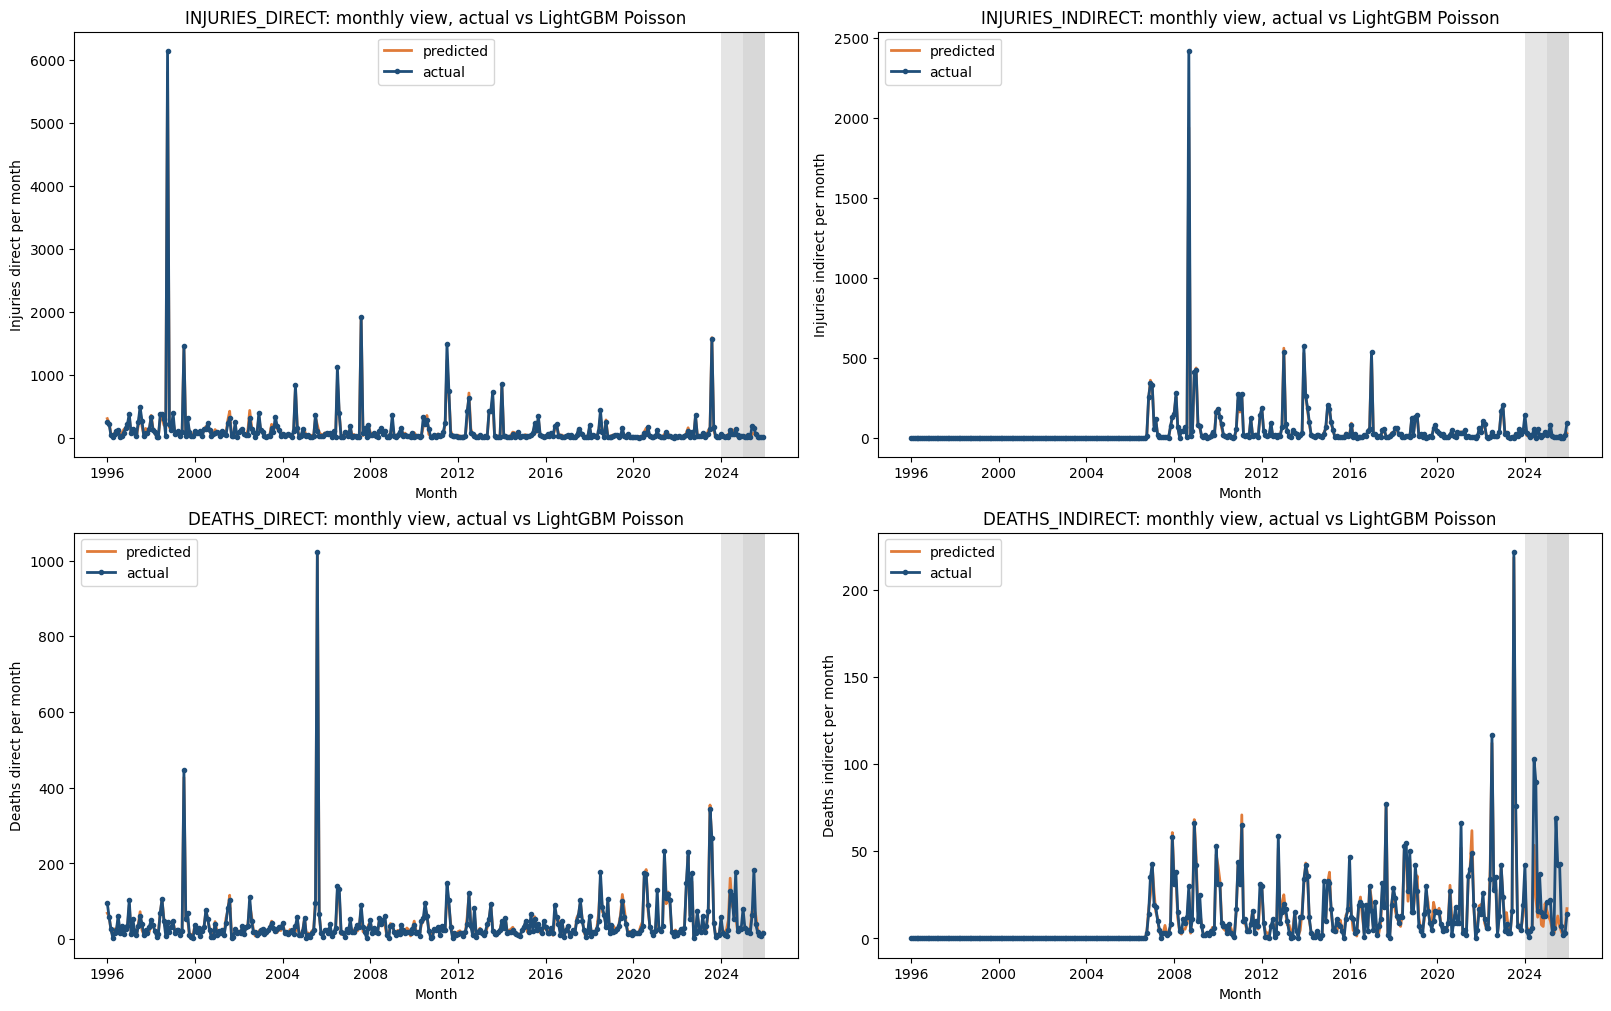

In [50]:
target_list=['INJURIES_DIRECT','INJURIES_INDIRECT','DEATHS_DIRECT','DEATHS_INDIRECT']
plot_monthly_actual_vs_predicted(forecast_results, target_list, model='LGBM')

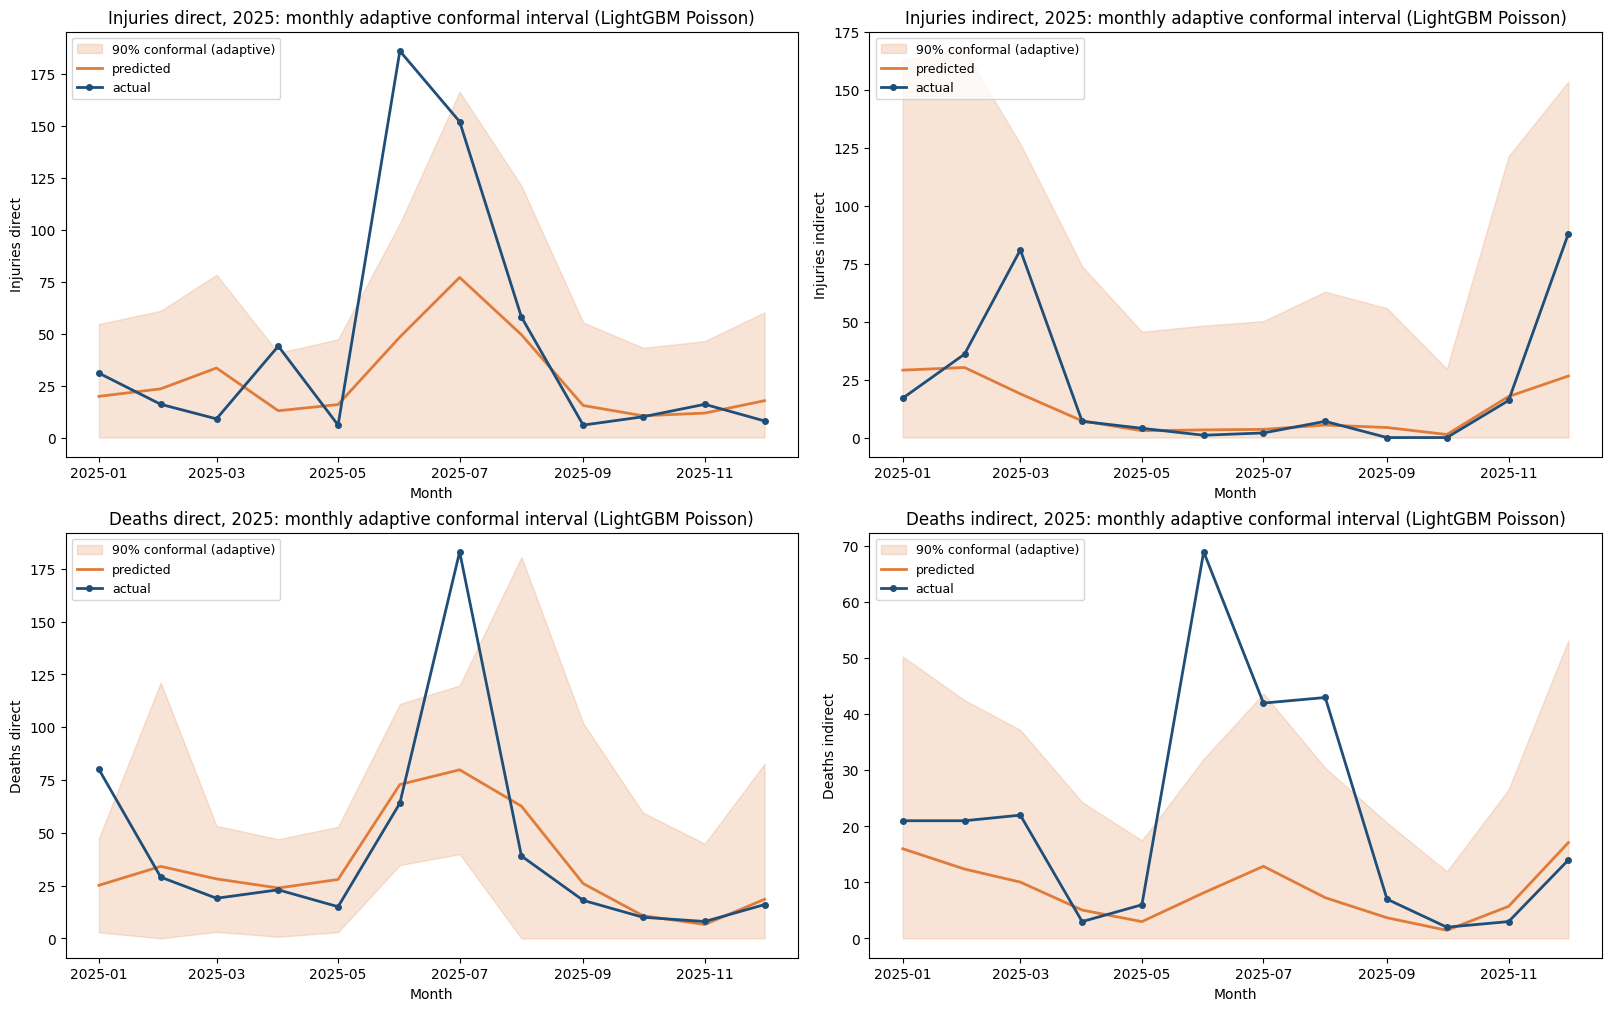

In [51]:
plot_conformal_monthly(forecast_results, target_list, model='LGBM', test_year=2025)

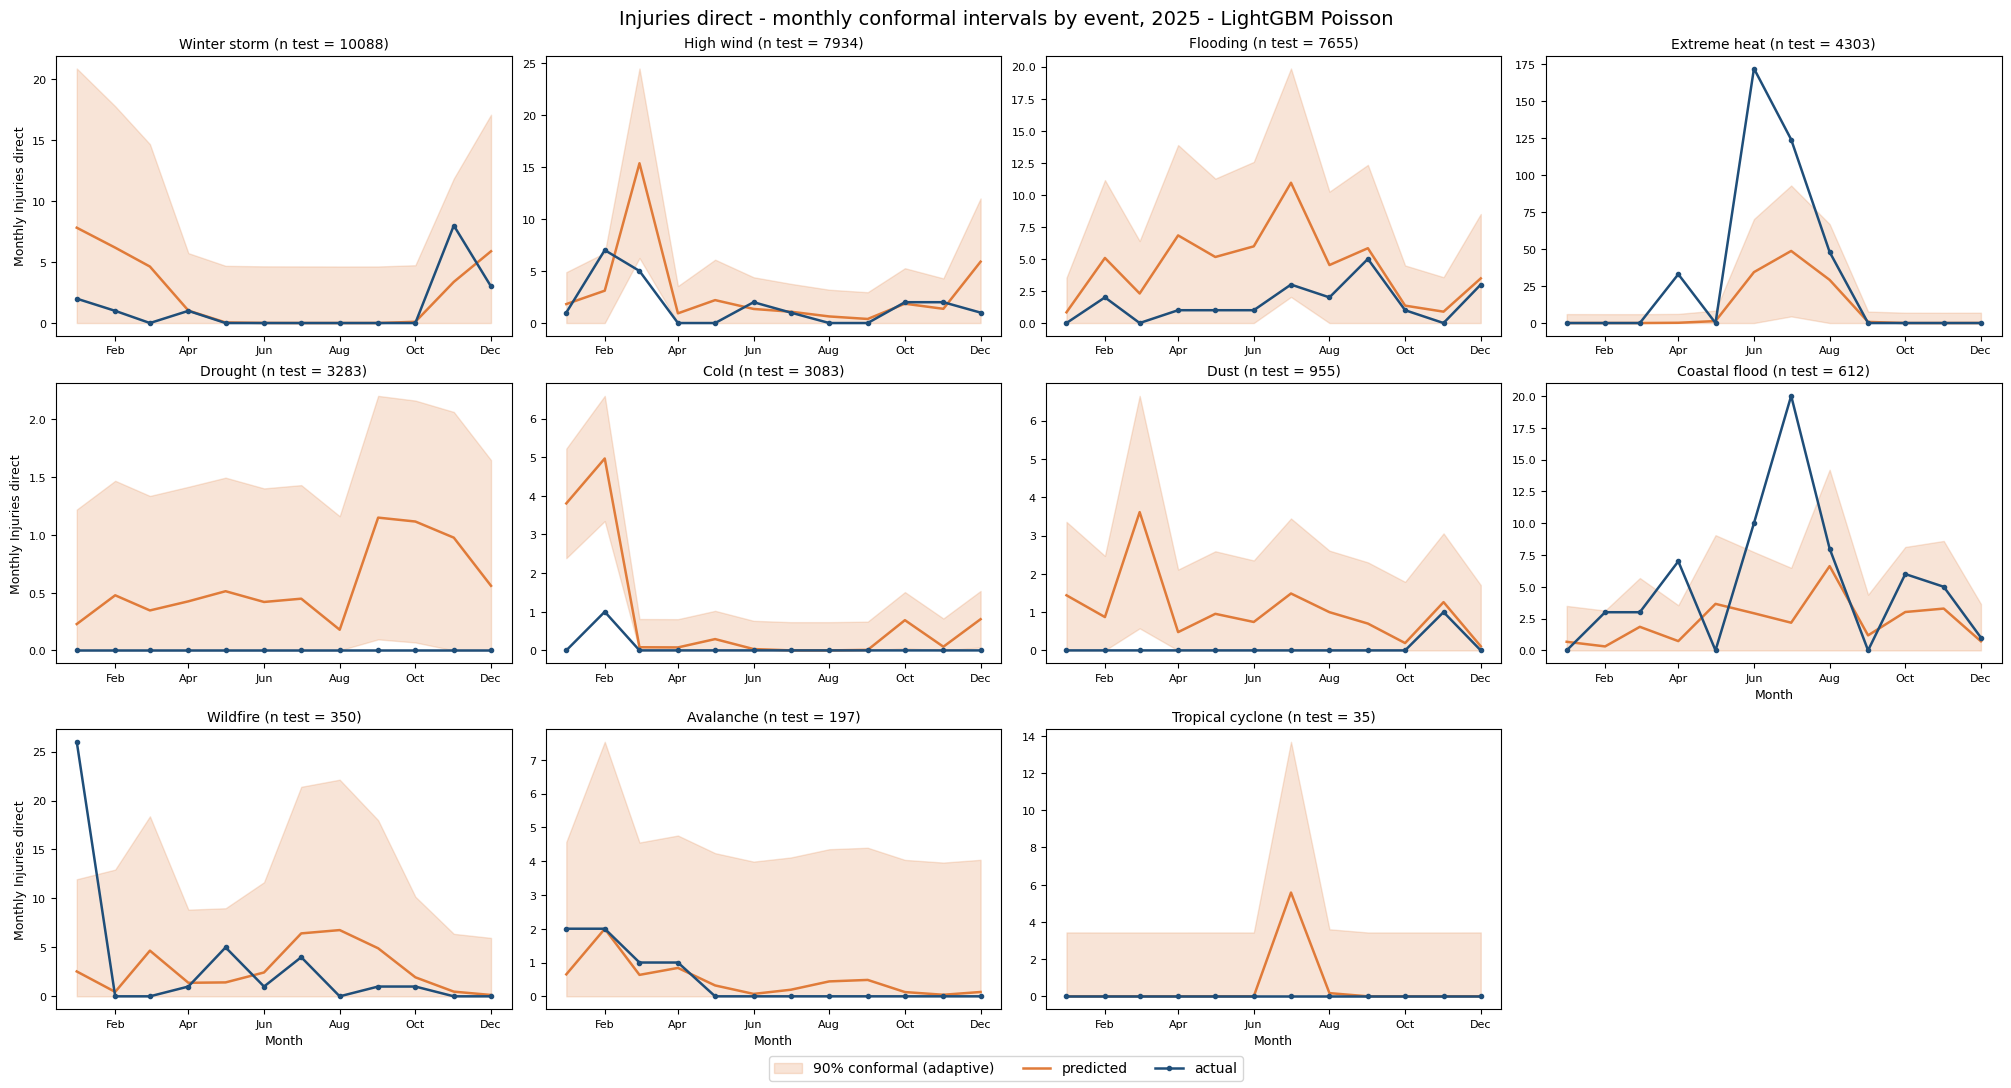

In [52]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES_DIRECT', model='LGBM', test_year=2025)

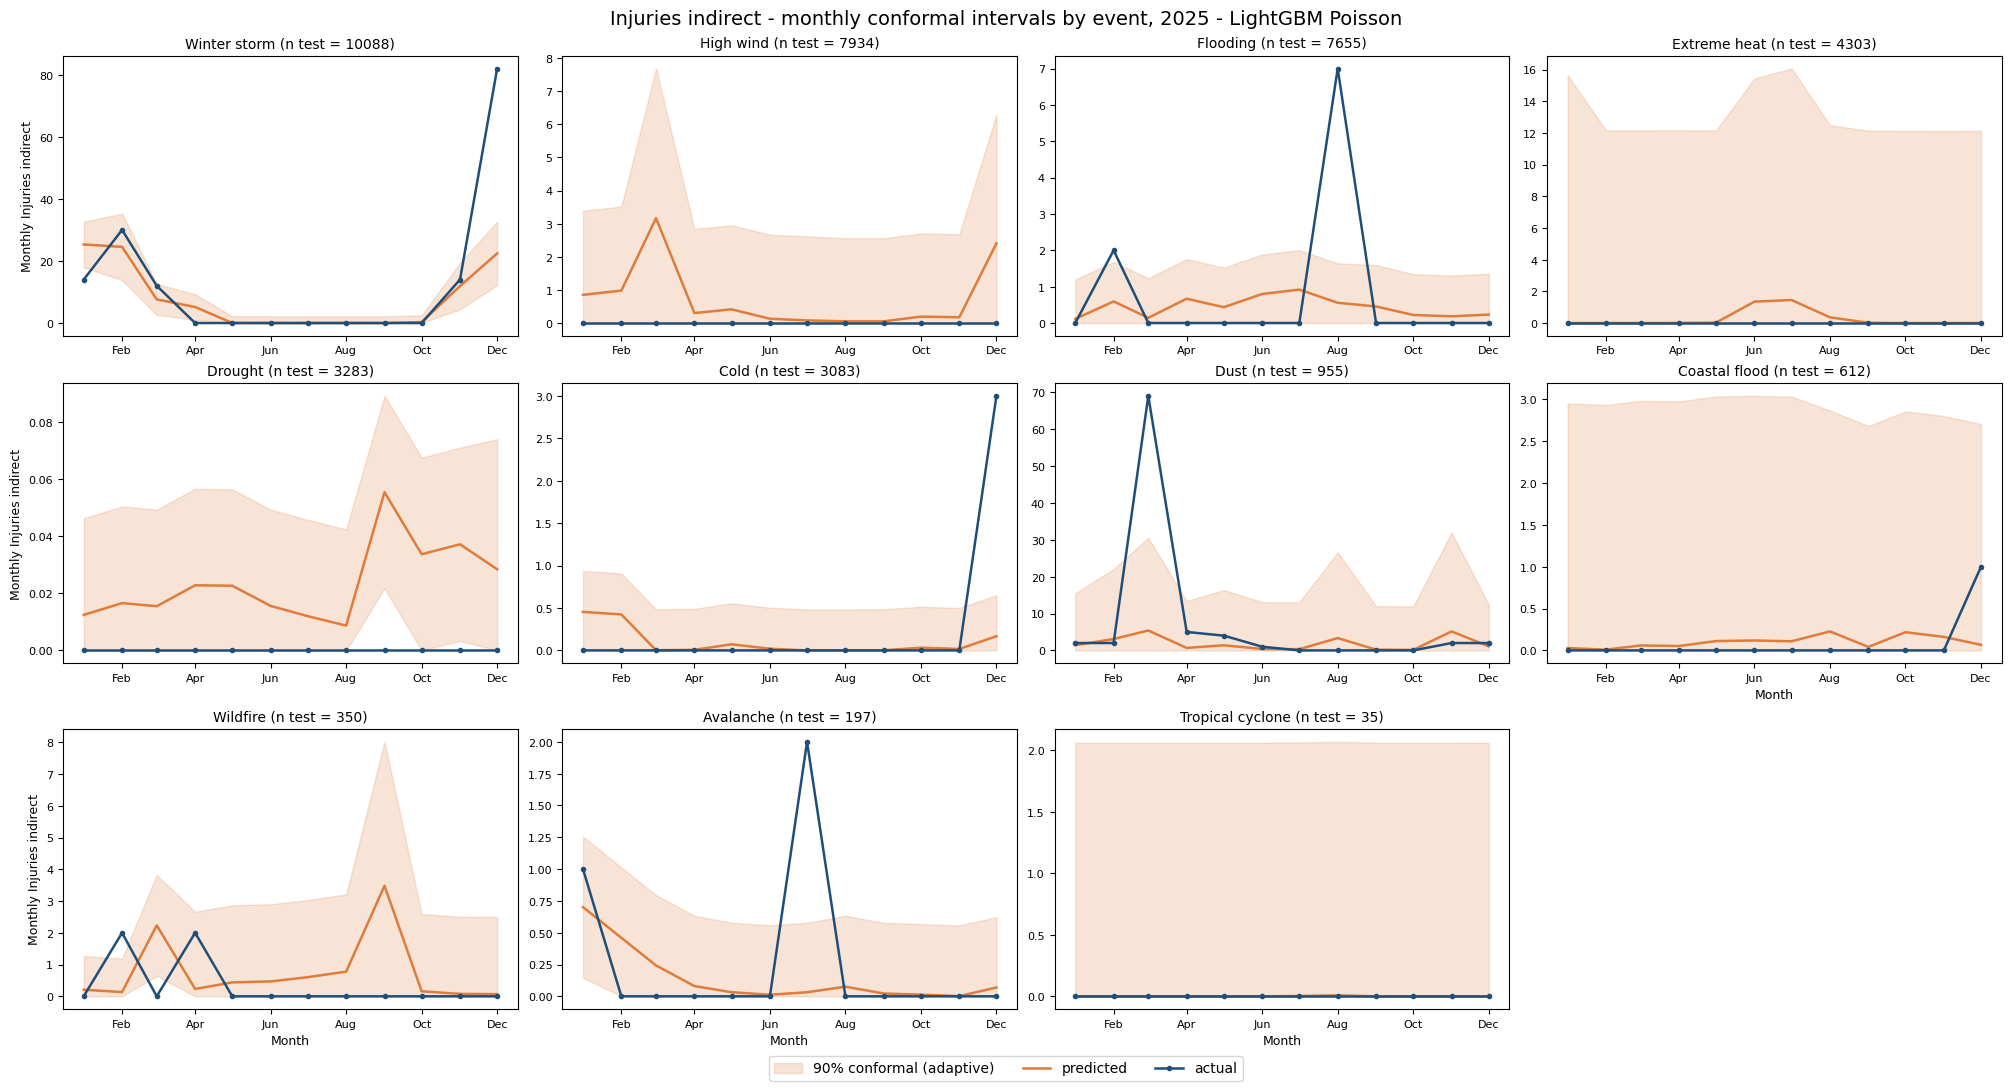

In [53]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES_INDIRECT', model='LGBM', test_year=2025)

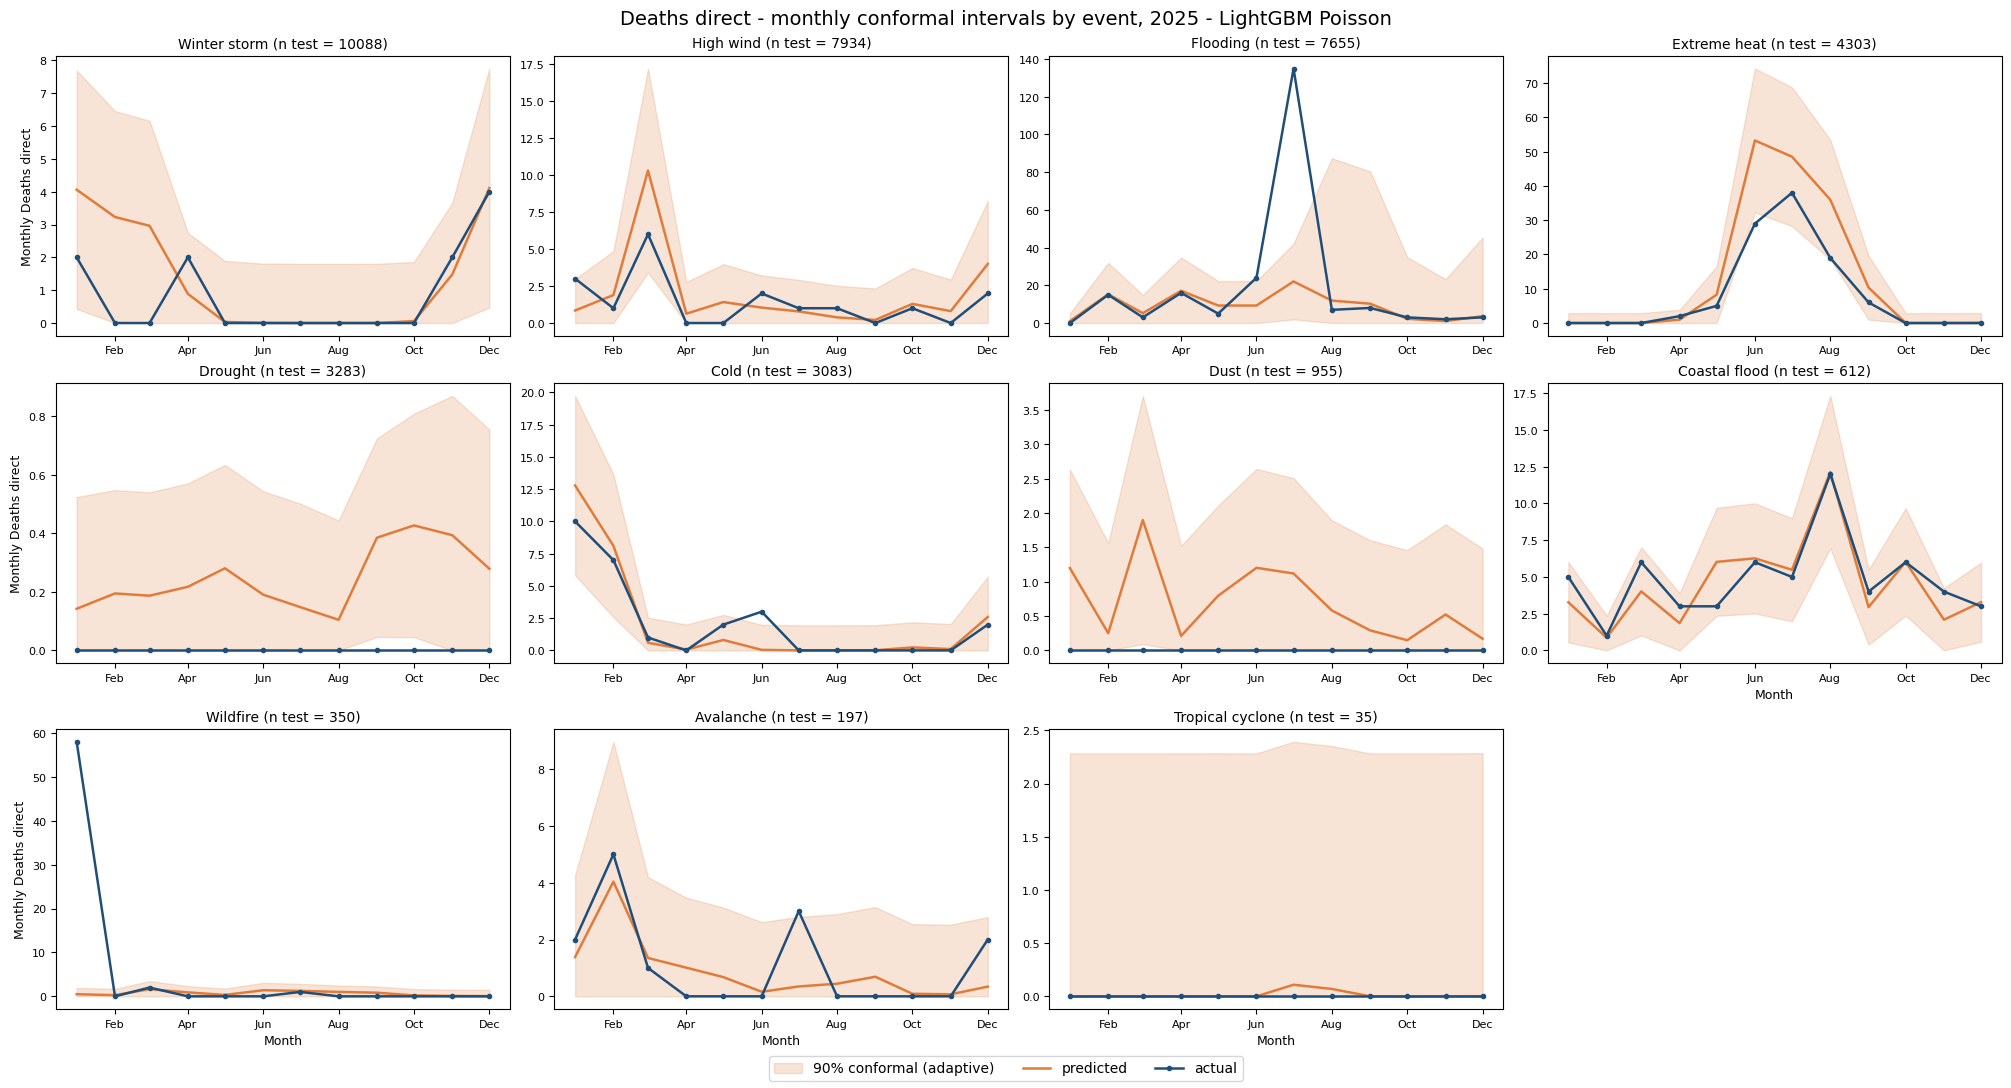

In [54]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS_DIRECT', model='LGBM', test_year=2025)

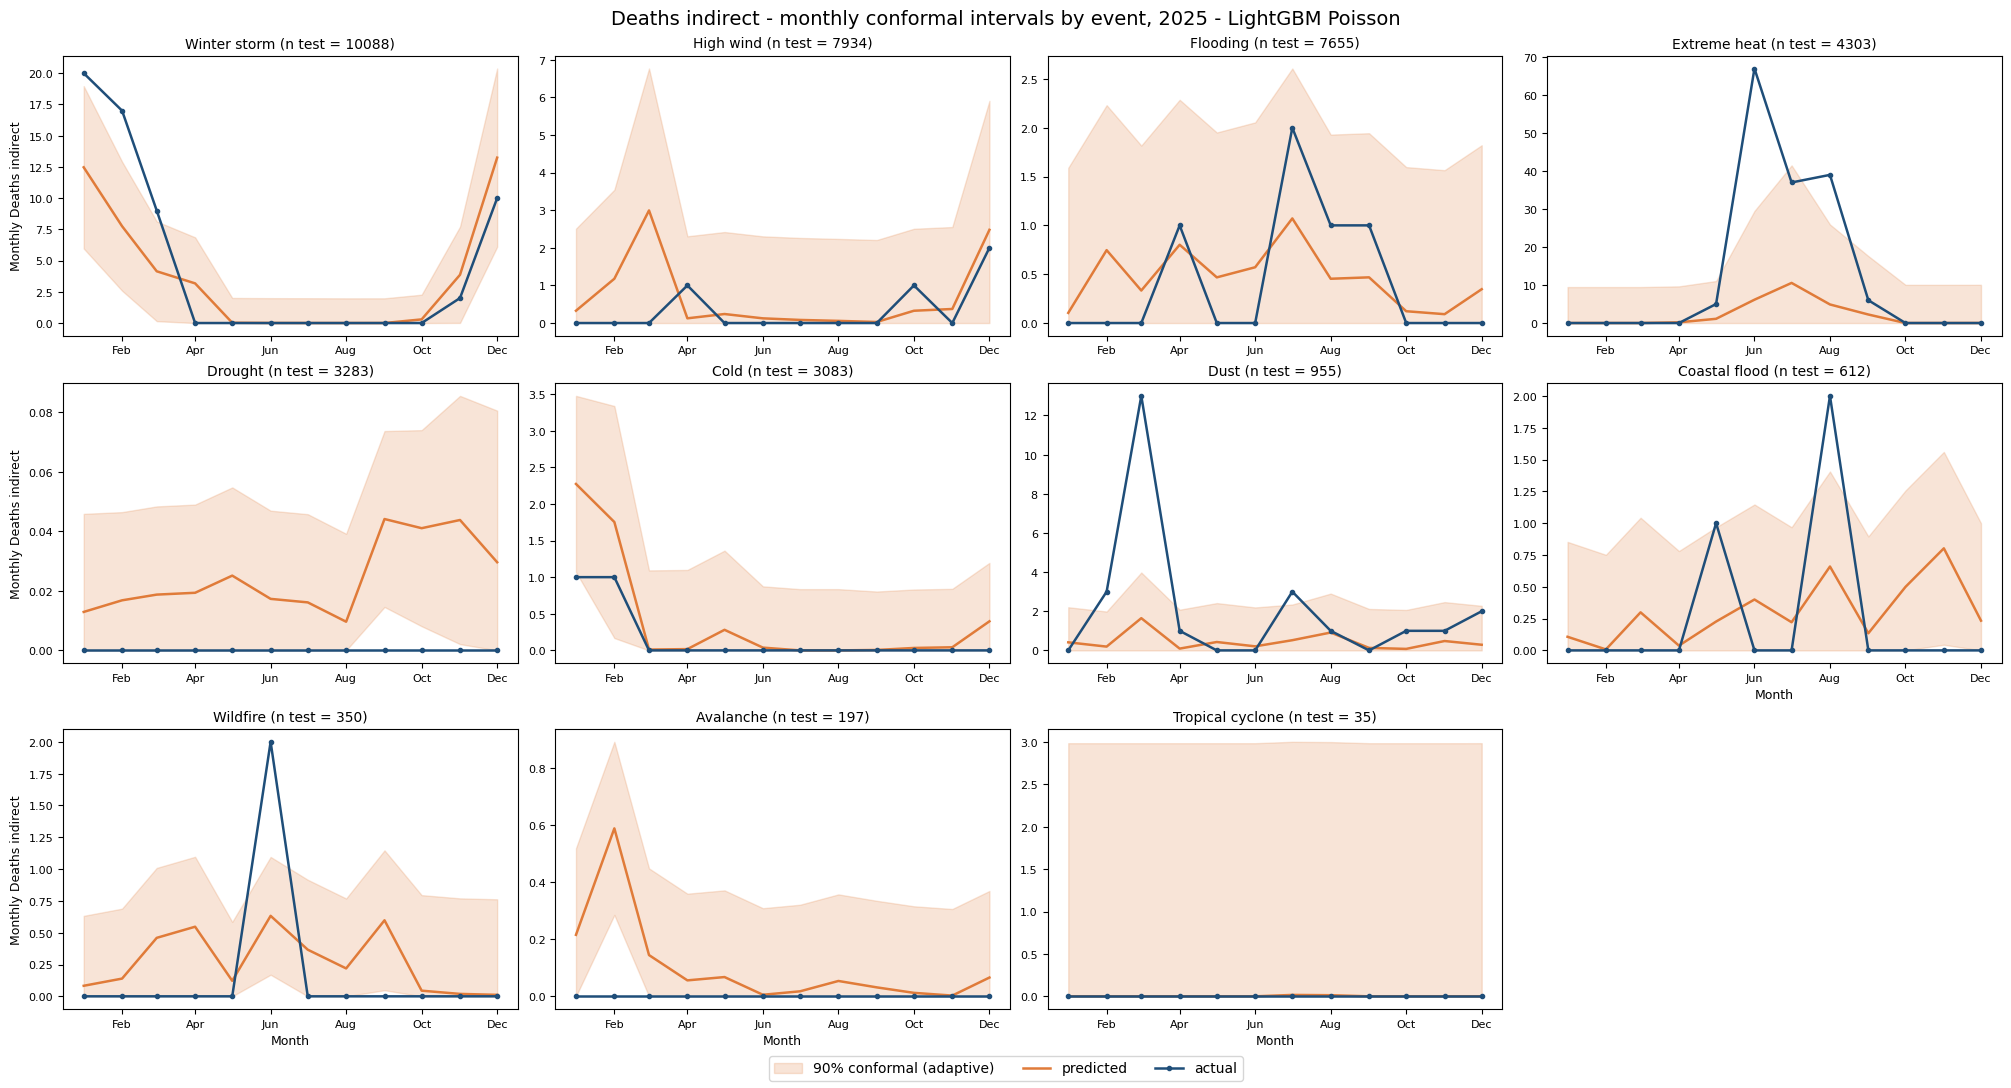

In [55]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS_INDIRECT', model='LGBM', test_year=2025)

### Backtesting Results


 BACKTESTING FOR TARGET: INJURIES_DIRECT (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


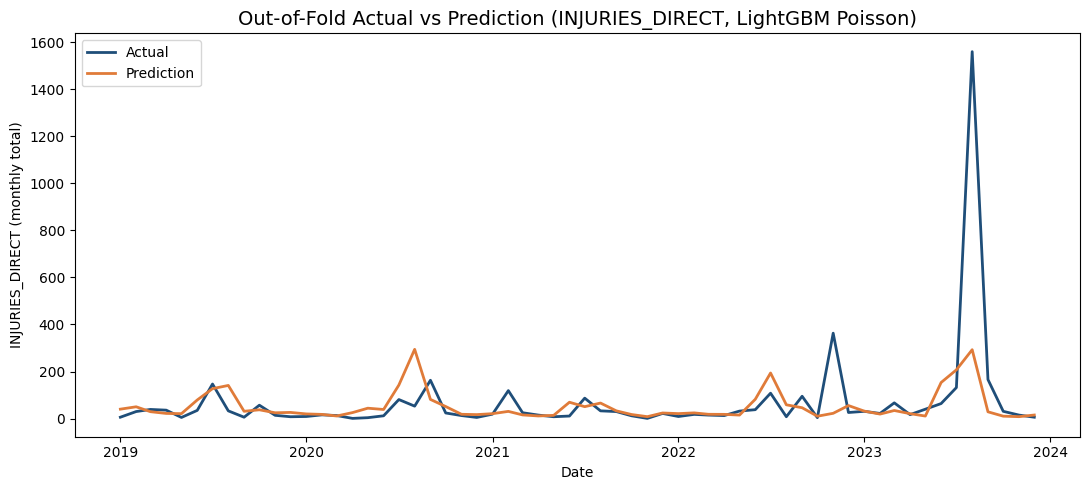

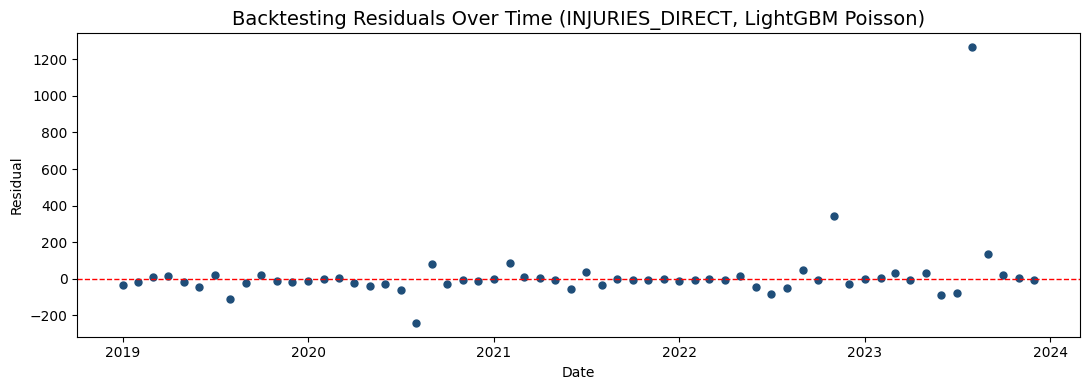

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,96,0.2724,0.4251,0.1117
2020,31055,103,0.2749,0.6515,0.1261
2021,36224,101,0.3178,0.6084,0.1011
2022,42173,120,0.0484,1.7454,0.2610
2023,39686,139,0.2117,4.7511,0.6781


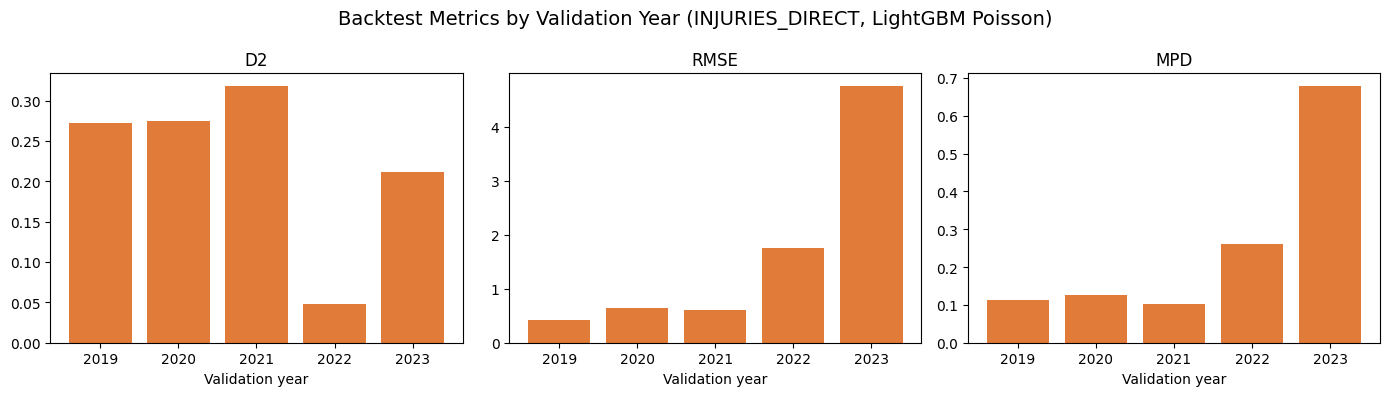

In [56]:
backtest_target_cv(
    train_events,
    'INJURIES_DIRECT',
    params=BEST_PARAMETERS['INJURIES_DIRECT'],
    model='LGBM',
)


 BACKTESTING FOR TARGET: INJURIES_INDIRECT (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


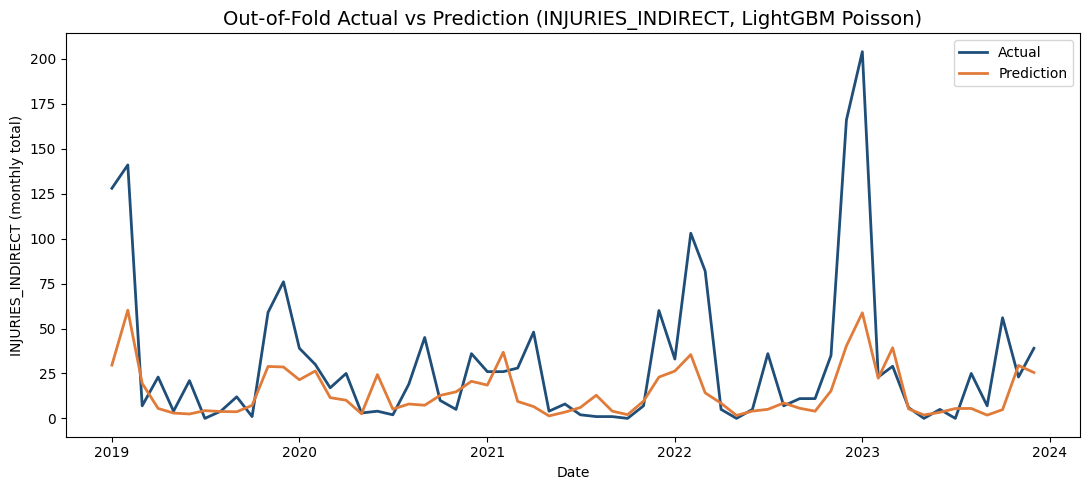

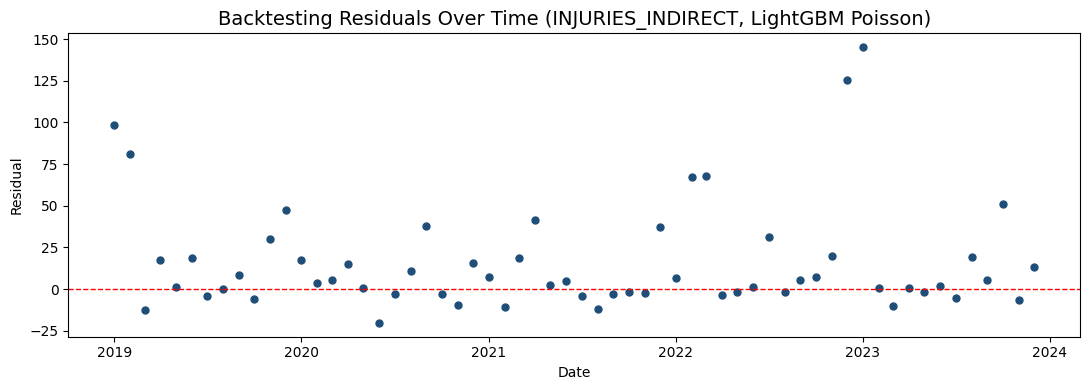

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,88,0.3980,0.6099,0.1097
2020,31055,76,0.4017,0.2547,0.0591
2021,36224,62,0.4477,0.2631,0.0451
2022,42173,120,0.2612,0.4879,0.1159
2023,39686,101,0.4310,0.4865,0.0829


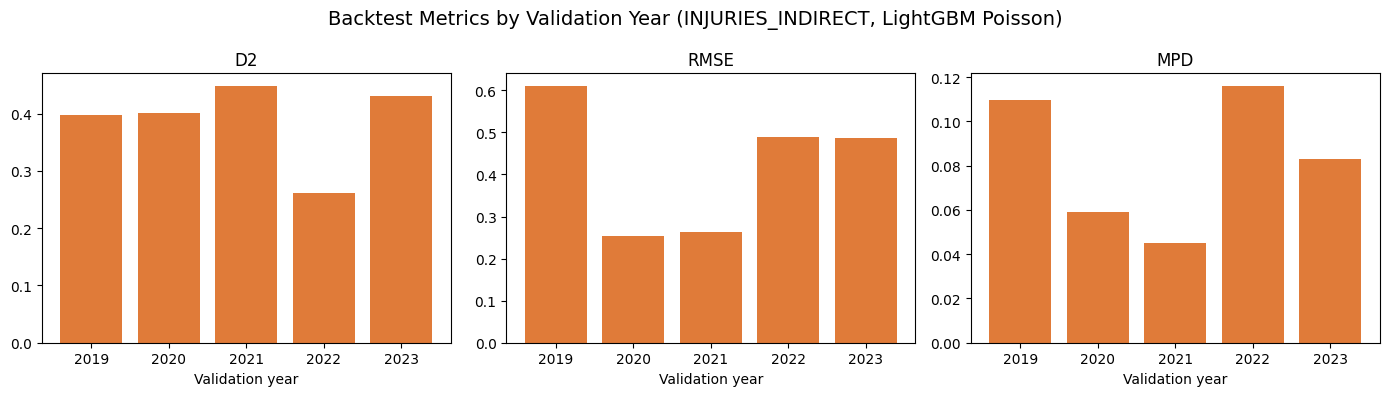

In [57]:
backtest_target_cv(
    train_events,
    'INJURIES_INDIRECT',
    params=BEST_PARAMETERS['INJURIES_INDIRECT'],
    model='LGBM',
)


 BACKTESTING FOR TARGET: DEATHS_DIRECT (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


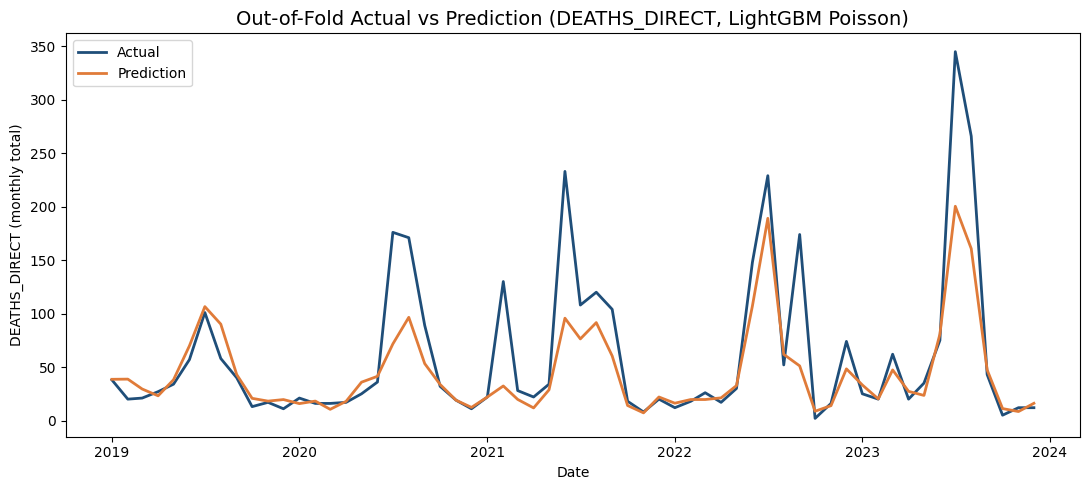

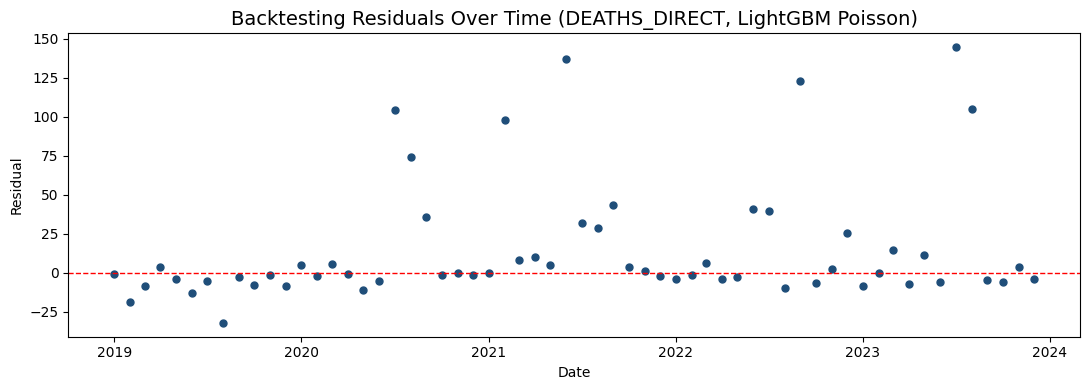

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,333,0.6550,0.1146,0.0400
2020,31055,300,0.5901,0.4133,0.0879
2021,36224,428,0.5348,0.5789,0.1123
2022,42173,353,0.5829,0.4624,0.0864
2023,39686,409,0.6595,0.7089,0.0872


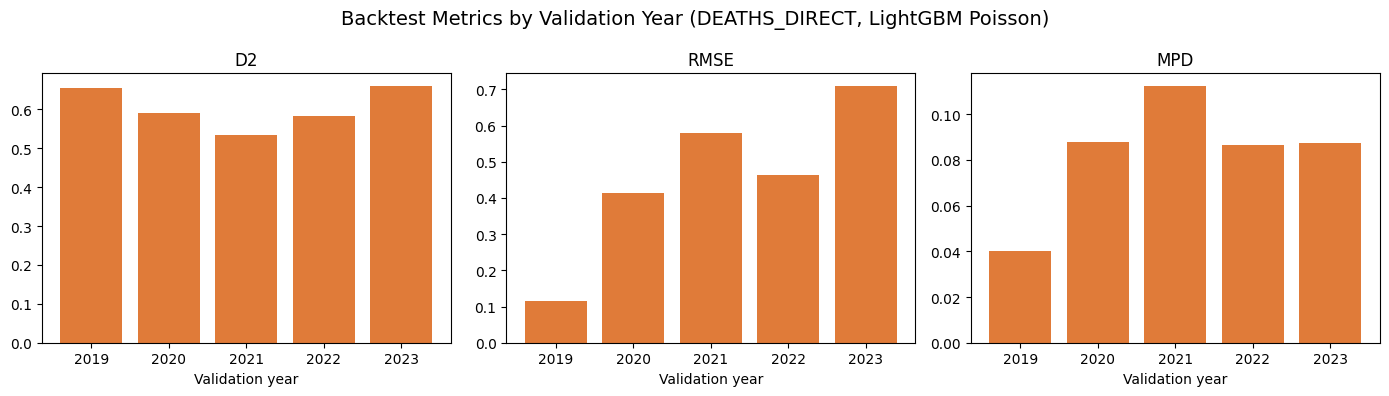

In [58]:
backtest_target_cv(
    train_events,
    'DEATHS_DIRECT',
    params=BEST_PARAMETERS['DEATHS_DIRECT'],
    model='LGBM',
)


 BACKTESTING FOR TARGET: DEATHS_INDIRECT (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


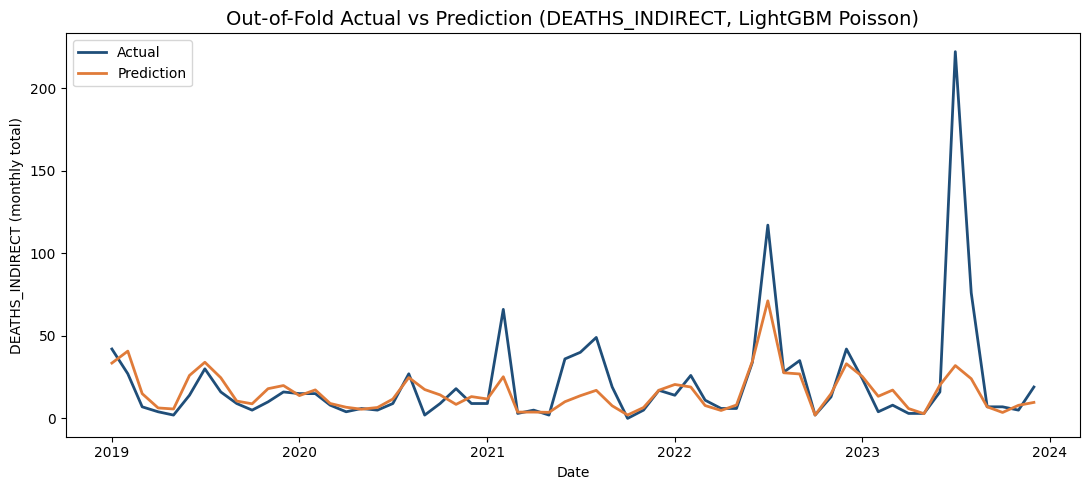

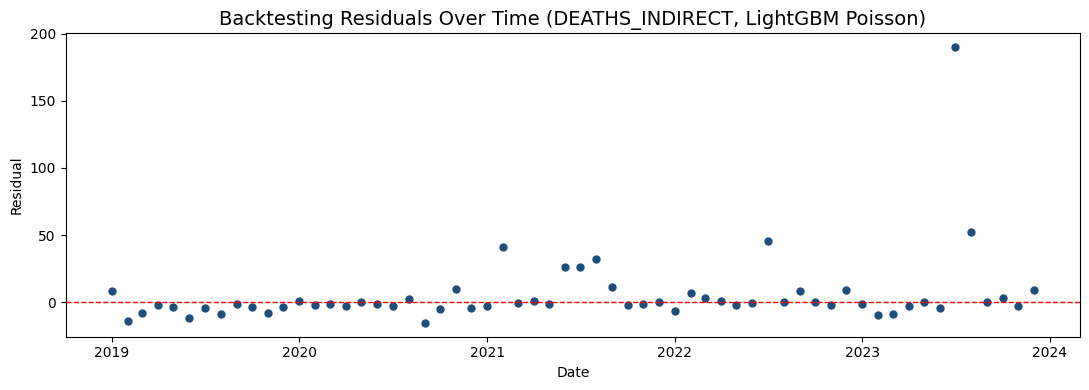

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,152,0.6119,0.0727,0.0215
2020,31055,87,0.4897,0.1017,0.0255
2021,36224,156,0.5419,0.1310,0.0361
2022,42173,188,0.6961,0.1265,0.0274
2023,39686,136,0.4313,0.3818,0.0729


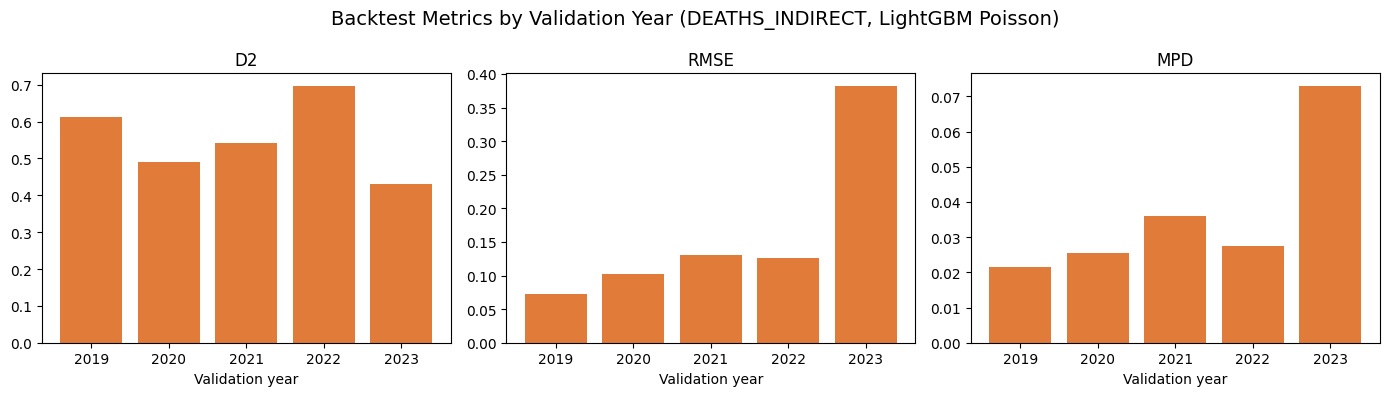

In [59]:
backtest_target_cv(
    train_events,
    'DEATHS_INDIRECT',
    params=BEST_PARAMETERS['DEATHS_INDIRECT'],
    model='LGBM',
)

## LSTM

### Fine-Tuning

In [ ]:
# To recalculate BEST_PARAMETERS_LSTM with the yearly expanding-window CV, uncomment and run:
#BEST_PARAMETERS_LSTM_TUNED = find_best_parameters_for_all_targets(
#      train_events,
#      FORECAST_TARGETS,
#      model='LSTM',
#      validation_years=VALIDATION_YEARS,
#      n_trials=10,
#)
#print("New BEST_PARAMETERS_LSTM dictionary:", BEST_PARAMETERS_LSTM_TUNED)

Tuning LSTM Poisson for target INJURIES_DIRECT...
Precomputing 5 folds for INJURIES_DIRECT...
  best parameters: {'sequence_length': 8, 'sequence_by': 'EVENT_GROUP', 'units': 16, 'dropout': 0.1270964398016714, 'learning_rate': 0.0019578897201213002, 'epochs': 6, 'batch_size': 512, 'verbose': 0}
Tuning LSTM Poisson for target INJURIES_INDIRECT...
Precomputing 5 folds for INJURIES_INDIRECT...
  best parameters: {'sequence_length': 8, 'sequence_by': 'EVENT_GROUP', 'units': 16, 'dropout': 0.1270964398016714, 'learning_rate': 0.0019578897201213002, 'epochs': 6, 'batch_size': 512, 'verbose': 0}
Tuning LSTM Poisson for target DEATHS_DIRECT...
Precomputing 5 folds for DEATHS_DIRECT...
  best parameters: {'sequence_length': 5, 'sequence_by': 'EVENT_GROUP', 'units': 16, 'dropout': 0.0056369401309065426, 'learning_rate': 0.0017189806743319388, 'epochs': 7, 'batch_size': 512, 'verbose': 0}
Tuning LSTM Poisson for target DEATHS_INDIRECT...
Precomputing 5 folds for DEATHS_INDIRECT...
  best paramete

### Prediction

In [60]:
LSTM_INJ_DIR = {
    'sequence_length': 8,
    'sequence_by': 'EVENT_GROUP',
    'units': 16,
    'dropout': 0.1270964398016714,
    'learning_rate': 0.0019578897201213002,
    'epochs': 6,
    'batch_size': 512,
    'verbose': 0
}

LSTM_INJ_INDIR = {
    'sequence_length': 8,
    'sequence_by': 'EVENT_GROUP',
    'units': 16,
    'dropout': 0.1270964398016714,
    'learning_rate': 0.0019578897201213002,
    'epochs': 6,
    'batch_size': 512,
    'verbose': 0
}

LSTM_DEATHS_DIR = {
    'sequence_length': 5,
    'sequence_by': 'EVENT_GROUP',
    'units': 16,
    'dropout': 0.0056369401309065426,
    'learning_rate': 0.0017189806743319388,
    'epochs': 7,
    'batch_size': 512,
    'verbose': 0
}

LSTM_DEATHS_INDIR = {
    'sequence_length': 12,
    'sequence_by': 'EVENT_GROUP',
    'units': 16,
    'dropout': 0.035482327760679964,
    'learning_rate': 0.001904767808428205,
    'epochs': 4,
    'batch_size': 256,
    'verbose': 0
}

BEST_PARAMETERS_LSTM = {
    'INJURIES_DIRECT': dict(LSTM_INJ_DIR),
    'INJURIES_INDIRECT': dict(LSTM_INJ_INDIR),
    'DEATHS_DIRECT': dict(LSTM_DEATHS_DIR),
    'DEATHS_INDIRECT': dict(LSTM_DEATHS_INDIR),
}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    FORECAST_TARGETS,
    best_params=BEST_PARAMETERS_LSTM,
    model='LSTM',
    group_column=GROUP_COL,
)
lstm_results = forecast_results

[LSTM Poisson] fitting INJURIES_DIRECT...
[LSTM Poisson] fitting INJURIES_INDIRECT...
[LSTM Poisson] fitting DEATHS_DIRECT...
[LSTM Poisson] fitting DEATHS_INDIRECT...


### Reporting Results

In [61]:
display(point_metrics_by_target(forecast_results, model='LSTM').round(4))

n  events      D2    RMSE     MPD
Target            Split                                              
DEATHS_DIRECT     train        812807    7724  0.6409  0.7872  0.0668
                  calibration   37371     394  0.4839  0.2669  0.0902
                  test          38495     271  0.4762  0.4371  0.0791
DEATHS_INDIRECT   train        812807    2313  0.6245  0.1132  0.0202
                  calibration   37371     168  0.5569  0.2222  0.0480
                  test          38495     154  0.5416  0.1264  0.0347
INJURIES_DIRECT   train        812807    5018  0.5324  4.2729  0.3348
                  calibration   37371     147  0.1658  0.5532  0.1629
                  test          38495     104  0.1842  1.0058  0.1719
INJURIES_INDIRECT train        812807    2238  0.4819  2.8109  0.1330
                  calibration   37371      87  0.3264  0.4391  0.0946
                  test          38495      82  0.4120  0.3090  0.0537

In [62]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES_DIRECT', model='LSTM').round(4))

n  events      D2    RMSE  \
Target          Split       EVENT_GROUP                                        
INJURIES_DIRECT train       Avalanche           2980     204  0.3839  3.0676   
                            Coastal_Flood      22805     572  0.3907  0.6756   
                            Cold               46823      77  0.4402  0.2545   
                            Drought            74627       2  0.3066  1.2810   
                            Dust               17849     168  0.4783  1.1664   
                            Extreme_Heat       45943     802  0.3956  8.0866   
                            Flooding          165876     694  0.6268  8.0430   
                            High_Wind         152517    1051  0.3239  0.3376   
                            Tropical_Cyclone   11397     162  0.4356  7.3888   
                            Wildfire            8787     515  0.3234  2.0313   
                            Winter_Storm      263203     771  0.4933  0.9574   
                calibration Avalanche            197      13  0.0795  0.3370   
                            Coastal_Flood        791      31  0.2935  0.3370   
                            Cold                1844       2 -0.3399  0.3957   
                            Drought             3473       0     NaN  0.0052   
                            Dust                 934       4  0.2957  0.1235   
                            Extreme_Heat        5831      22  0.0202  0.8204   
                            Flooding            7134      11 -0.0143  0.0732   
                            High_Wind           7564      31  0.2673  0.0986   
                            Tropical_Cyclone     813       8 -0.1387  2.7054   
                            Wildfire             336      12  0.1575  1.3661   
                            Winter_Storm        8454      13  0.2618  0.2193   
                test        Avalanche            197       6  0.4106  0.1515   
                            Coastal_Flood        612      30  0.0795  0.5822   
                            Cold                3083       1 -0.8791  0.0208   
                            Drought             3283       0     NaN  0.0043   
                            Dust                 955       1 -0.5253  0.0457   
                            Extreme_Heat        4303      12 -0.0379  2.9880   
                            Flooding            7655      15  0.1029  0.0631   
                            High_Wind           7934      17  0.1405  0.0622   
                            Tropical_Cyclone      35       0     NaN  0.0362   
                            Wildfire             350      12  0.0575  0.7892   
                            Winter_Storm       10088      10  0.0736  0.0522   

                                                 MPD  
Target          Split       EVENT_GROUP               
INJURIES_DIRECT train       Avalanche         0.8439  
                            Coastal_Flood     0.2930  
                            Cold              0.0565  
                            Drought           0.0734  
                            Dust              0.4223  
                            Extreme_Heat      2.5238  
                            Flooding          0.3065  
                            High_Wind         0.1098  
                            Tropical_Cyclone  1.3521  
                            Wildfire          1.2394  
                            Winter_Storm      0.1423  
                calibration Avalanche         0.4191  
                            Coastal_Flood     0.2942  
                            Cold              0.2381  
                            Drought           0.0060  
                            Dust              0.0587  
                            Extreme_Heat      0.4444  
                            Flooding          0.0321  
                            High_Wind         0.0467  
                            Tropical_Cyclone  1.5044  
                            Wildfire    

In [63]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES_INDIRECT', model='LSTM').round(4))

n  events      D2  \
Target            Split       EVENT_GROUP                                
INJURIES_INDIRECT train       Avalanche           2980       9 -0.5228   
                              Coastal_Flood      22805      13  0.0282   
                              Cold               46823      36  0.5068   
                              Drought            74627       2  0.1719   
                              Dust               17849     194  0.6346   
                              Extreme_Heat       45943      40  0.2097   
                              Flooding          165876      72  0.1089   
                              High_Wind         152517     125  0.4347   
                              Tropical_Cyclone   11397      20  0.1811   
                              Wildfire            8787     111  0.3701   
                              Winter_Storm      263203    1616  0.5073   
                  calibration Avalanche            197       1  0.2322   
                              Coastal_Flood        791       3 -0.0305   
                              Cold                1844       2  0.6378   
                              Drought             3473       0     NaN   
                              Dust                 934      20  0.1880   
                              Extreme_Heat        5831       5 -0.0082   
                              Flooding            7134       1 -0.2039   
                              High_Wind           7564       9  0.2875   
                              Tropical_Cyclone     813       5  0.1146   
                              Wildfire             336       1 -0.2047   
                              Winter_Storm        8454      40  0.3120   
                  test        Avalanche            197       2 -0.1288   
                              Coastal_Flood        612       1  0.2157   
                              Cold                3083       2  0.6166   
                              Drought             3283       0     NaN   
                              Dust                 955      14  0.2776   
                              Extreme_Heat        4303       0     NaN   
                              Flooding            7655       3  0.0264   
                              High_Wind           7934       0     NaN   
                              Tropical_Cyclone      35       0     NaN   
                              Wildfire             350       2 -0.1340   
                              Winter_Storm       10088      58  0.3285   

                                                   RMSE     MPD  
Target            Split       EVENT_GROUP                        
INJURIES_INDIRECT train       Avalanche          0.1269  0.0658  
                              Coastal_Flood      0.0352  0.0103  
                              Cold               0.1356  0.0196  
                              Drought            0.0115  0.0009  
                              Dust               1.0537  0.2600  
                              Extreme_Heat       0.4733  0.0862  
                              Flooding           0.0508  0.0108  
                              High_Wind          0.7082  0.0364  
                              Tropical_Cyclone  22.4823  3.2694  
                              Wildfire           0.9611  0.3726  
                              Winter_Storm       1.4395  0.1906  
                  calibration Avalanche          0.0738  0.0412  
                              Coastal_Flood      0.2488  0.1627  
                              Cold               0.0280  0.0054  
                              Drought            0.0003  0.0005  
                              Dust               1.8715  1.0779  
                              Extreme_Heat       0.3619  0.1272  
                              Flooding           0.0237  0.0060  
                              High_Wind          0.0611  0.0181  
                              Tropical_Cyclone   0.1570  0.1026  
          

In [64]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS_DIRECT', model='LSTM').round(4))

n  events      D2    RMSE  \
Target        Split       EVENT_GROUP                                        
DEATHS_DIRECT train       Avalanche           2980     369  0.5640  0.9352   
                          Coastal_Flood      22805    1407  0.7507  0.2745   
                          Cold               46823     645  0.7026  0.2110   
                          Drought            74627       0     NaN  0.0008   
                          Dust               17849      66  0.3136  0.1507   
                          Extreme_Heat       45943    2092  0.6562  1.0101   
                          Flooding          165876    1620  0.3836  0.2133   
                          High_Wind         152517     618  0.4824  0.0887   
                          Tropical_Cyclone   11397     205  0.5890  6.0970   
                          Wildfire            8787     118  0.5686  1.3431   
                          Winter_Storm      263203     584  0.4359  0.0803   
              calibration Avalanche            197      13  0.2665  0.9616   
                          Coastal_Flood        791      67  0.7939  0.2330   
                          Cold                1844      35  0.4363  0.1809   
                          Drought             3473       0     NaN  0.0004   
                          Dust                 934       1  0.0596  0.1205   
                          Extreme_Heat        5831     132  0.5994  0.4732   
                          Flooding            7134      70  0.1942  0.3169   
                          High_Wind           7564      22  0.2710  0.0799   
                          Tropical_Cyclone     813      31  0.1646  0.4428   
                          Wildfire             336       7  0.2041  0.1920   
                          Winter_Storm        8454      16  0.2577  0.1194   
              test        Avalanche            197      11  0.3833  0.3193   
                          Coastal_Flood        612      56  0.6636  0.2502   
                          Cold                3083      23  0.6988  0.0967   
                          Drought             3283       0     NaN  0.0007   
                          Dust                 955       0     NaN  0.0828   
                          Extreme_Heat        4303      75  0.5984  0.2524   
                          Flooding            7655      74  0.2674  0.8969   
                          High_Wind           7934      15  0.2959  0.0622   
                          Tropical_Cyclone      35       0     NaN  0.0129   
                          Wildfire             350       7  0.3856  1.5004   
                          Winter_Storm       10088      10  0.2871  0.0327   

                                               MPD  
Target        Split       EVENT_GROUP               
DEATHS_DIRECT train       Avalanche         0.3993  
                          Coastal_Flood     0.1038  
                          Cold              0.0479  
                          Drought           0.0002  
                          Dust              0.0504  
                          Extreme_Heat      0.2804  
                          Flooding          0.0898  
                          High_Wind         0.0294  
                          Tropical_Cyclone  0.6603  
                          Wildfire          0.2457  
                          Winter_Storm      0.0214  
              calibration Avalanche         0.6685  
                          Coastal_Flood     0.0981  
                          Cold              0.1188  
                          Drought           0.0001  
                          Dust              0.0275  
                          Extreme_Heat      0.1426  
                          Flooding          0.1631  
                          High_Wind         0.0309  
                          Tropical_Cyclone  0.4225  
                          Wildfire          0.1675  
                          Winter_Storm      0.0338  
              test        Avalanche         0.

In [65]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS_INDIRECT', model='LSTM').round(4))

n  events      D2    RMSE  \
Target          Split       EVENT_GROUP                                        
DEATHS_INDIRECT train       Avalanche           2980      10  0.2310  0.0679   
                            Coastal_Flood      22805      26  0.4207  0.0400   
                            Cold               46823      96  0.6186  0.0632   
                            Drought            74627       0     NaN  0.0003   
                            Dust               17849     152  0.7108  0.1334   
                            Extreme_Heat       45943     479  0.7115  0.3507   
                            Flooding          165876     101  0.2795  0.0333   
                            High_Wind         152517     120  0.5373  0.0484   
                            Tropical_Cyclone   11397     103  0.5972  0.3571   
                            Wildfire            8787      43  0.4922  0.1262   
                            Winter_Storm      263203    1183  0.5297  0.0890   
                calibration Avalanche            197       0     NaN  0.0027   
                            Coastal_Flood        791       1  0.2222  0.0360   
                            Cold                1844       3  0.2942  0.0474   
                            Drought             3473       0     NaN  0.0001   
                            Dust                 934      12  0.4769  0.1947   
                            Extreme_Heat        5831      82  0.6217  0.5223   
                            Flooding            7134       8  0.1126  0.0392   
                            High_Wind           7564      10  0.3741  0.0665   
                            Tropical_Cyclone     813      18  0.1271  0.3676   
                            Wildfire             336       1  0.4324  0.0438   
                            Winter_Storm        8454      33  0.1741  0.0836   
                test        Avalanche            197       0     NaN  0.0133   
                            Coastal_Flood        612       3  0.1963  0.0725   
                            Cold                3083       2  0.2841  0.0255   
                            Drought             3283       0     NaN  0.0001   
                            Dust                 955      11  0.4561  0.3231   
                            Extreme_Heat        4303      88  0.5788  0.2953   
                            Flooding            7655       5  0.1756  0.0255   
                            High_Wind           7934       4  0.1169  0.0238   
                            Tropical_Cyclone      35       0     NaN  0.0016   
                            Wildfire             350       1  0.3045  0.1097   
                            Winter_Storm       10088      40  0.2574  0.1097   

                                                 MPD  
Target          Split       EVENT_GROUP               
DEATHS_INDIRECT train       Avalanche         0.0325  
                            Coastal_Flood     0.0104  
                            Cold              0.0129  
                            Drought           0.0000  
                            Dust              0.0360  
                            Extreme_Heat      0.0645  
                            Flooding          0.0080  
                            High_Wind         0.0080  
                            Tropical_Cyclone  0.0989  
                            Wildfire          0.0376  
                            Winter_Storm      0.0299  
                calibration Avalanche         0.0023  
                            Coastal_Flood     0.0131  
                            Cold              0.0147  
                            Drought           0.0001  
                            Dust              0.0959  
                            Extreme_Heat      0.1393  
                            Flooding          0.0153  
                            High_Wind         0.0159  
                            Tropical_Cyclone  0.3028  
                            Wildfire    

In [66]:
display(daily_conformal_summary(forecast_results, model='LSTM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS_DIRECT,365,0.9260,1.3808,3.5418,2.5650
DEATHS_INDIRECT,365,0.8986,0.6932,2.2119,3.1910
INJURIES_DIRECT,365,0.9178,1.4849,2.7656,1.8624
INJURIES_INDIRECT,365,0.9041,0.7096,2.4150,3.4033


In [67]:
display(event_monthly_conformal_summary(forecast_results, model='LSTM').round(4))

Months  TestRecords  Coverage  MeanActual  \
Target            EVENT_GROUP                                                   
DEATHS_DIRECT     Avalanche             12          197    0.9167      1.0833   
                  Coastal_Flood         12          612    0.6667      4.8333   
                  Cold                  12         3083    0.7500      2.0833   
                  Drought               12         3283    0.8333      0.0000   
                  Dust                  12          955    1.0000      0.0000   
                  Extreme_Heat          12         4303    0.9167      8.2500   
                  Flooding              12         7655    0.8333     18.4167   
                  High_Wind             12         7934    0.9167      1.4167   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.8333      5.0833   
                  Winter_Storm          12        10088    1.0000      0.8333   
DEATHS_INDIRECT   Avalanche             12          197    0.7500      0.0000   
                  Coastal_Flood         12          612    0.8333      0.2500   
                  Cold                  12         3083    0.8333      0.1667   
                  Drought               12         3283    0.9167      0.0000   
                  Dust                  12          955    0.6667      2.0833   
                  Extreme_Heat          12         4303    0.8333     12.8333   
                  Flooding              12         7655    1.0000      0.4167   
                  High_Wind             12         7934    1.0000      0.3333   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.8333      0.1667   
                  Winter_Storm          12        10088    0.8333      4.8333   
INJURIES_DIRECT   Avalanche             12          197    1.0000      0.5000   
                  Coastal_Flood         12          612    0.7500      5.2500   
                  Cold                  12         3083    0.8333      0.0833   
                  Drought               12         3283    0.9167      0.0000   
                  Dust                  12          955    1.0000      0.0833   
                  Extreme_Heat          12         4303    0.7500     31.4167   
                  Flooding              12         7655    1.0000      1.5833   
                  High_Wind             12         7934    1.0000      1.7500   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.9167      3.2500   
                  Winter_Storm          12        10088    0.8333      1.2500   
INJURIES_INDIRECT Avalanche             12          197    0.7500      0.2500   
                  Coastal_Flood         12          612    1.0000      0.0833   
                  Cold                  12         3083    0.7500      0.2500   
                  Drought               12         3283    0.8333      0.0000   
                  Dust                  12          955    0.9167      7.2500   
                  Extreme_Heat          12         4303    1.0000      0.0000   
                  Flooding              12         7655    0.7500      0.7500   
                  High_Wind             12         7934    0.9167      0.0000   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.9167      0.3333   
                  Winter_Storm          12        10088    0.8333     12.6667   

                                    MeanWidth  RelWidth  
Target            EVENT_GROUP                            
DEATHS_DIRECT     Avalanche            4.3860    4.0486  
                  Coastal_Flood        6.2843    1.3002  
                  Cold                 3.3300    1.5984  
                  D

### Visualization Results

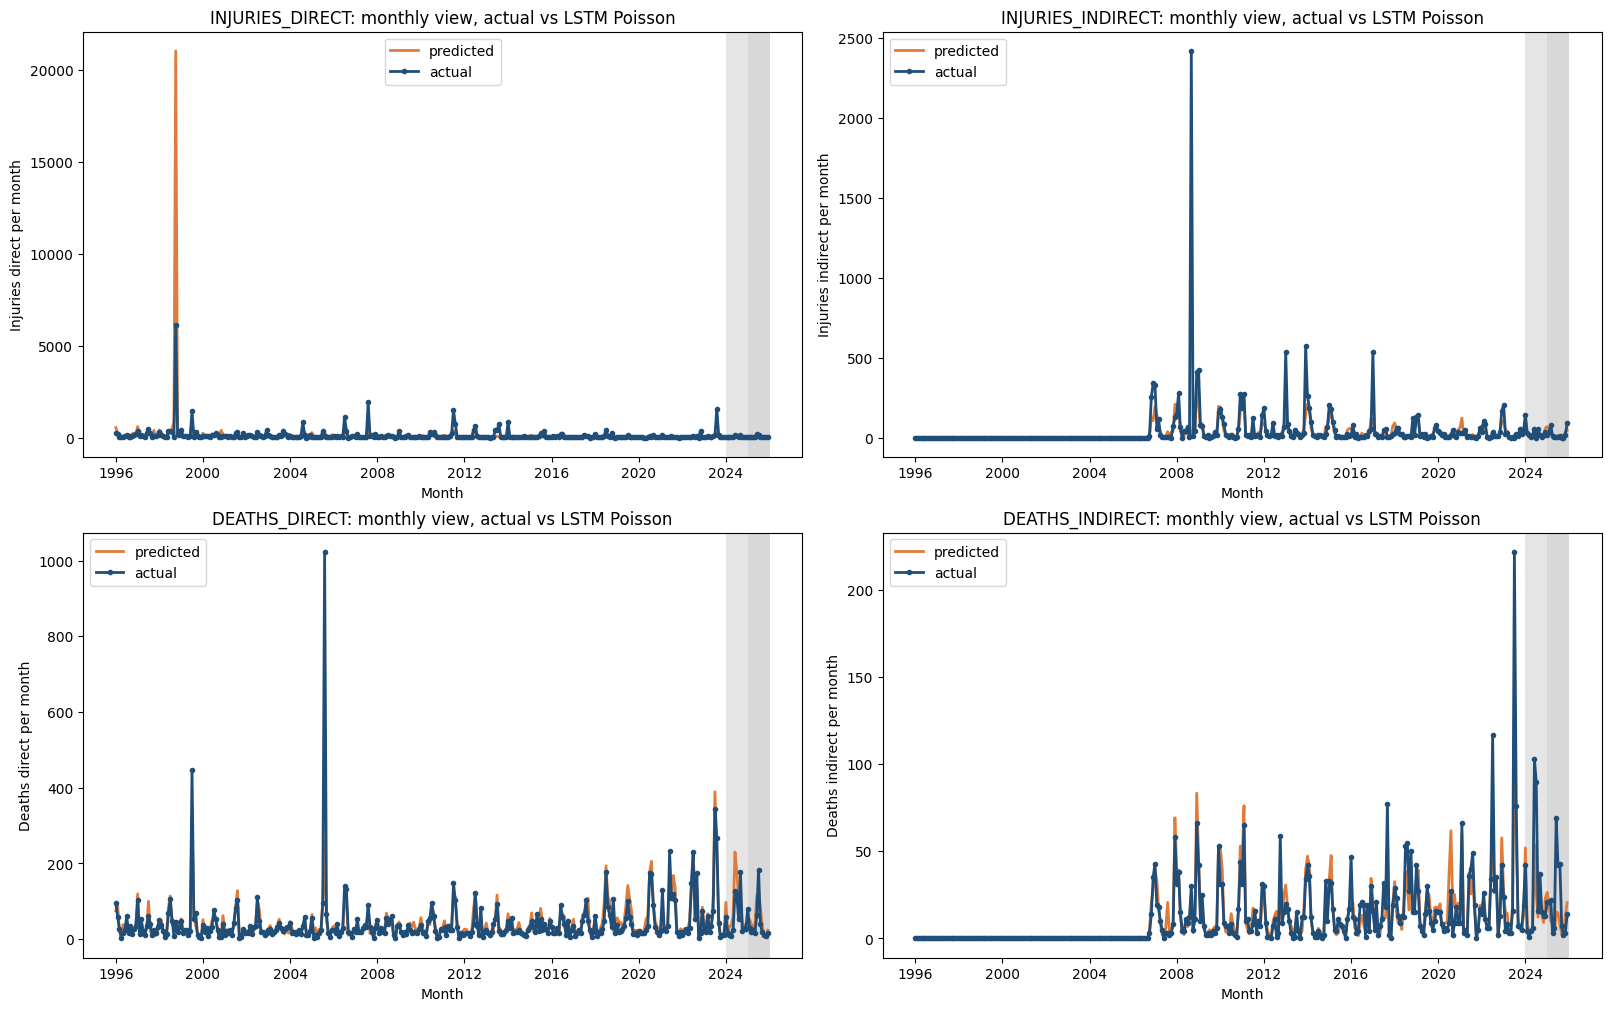

In [68]:
target_list=['INJURIES_DIRECT','INJURIES_INDIRECT','DEATHS_DIRECT','DEATHS_INDIRECT']
plot_monthly_actual_vs_predicted(forecast_results, target_list, model='LSTM')

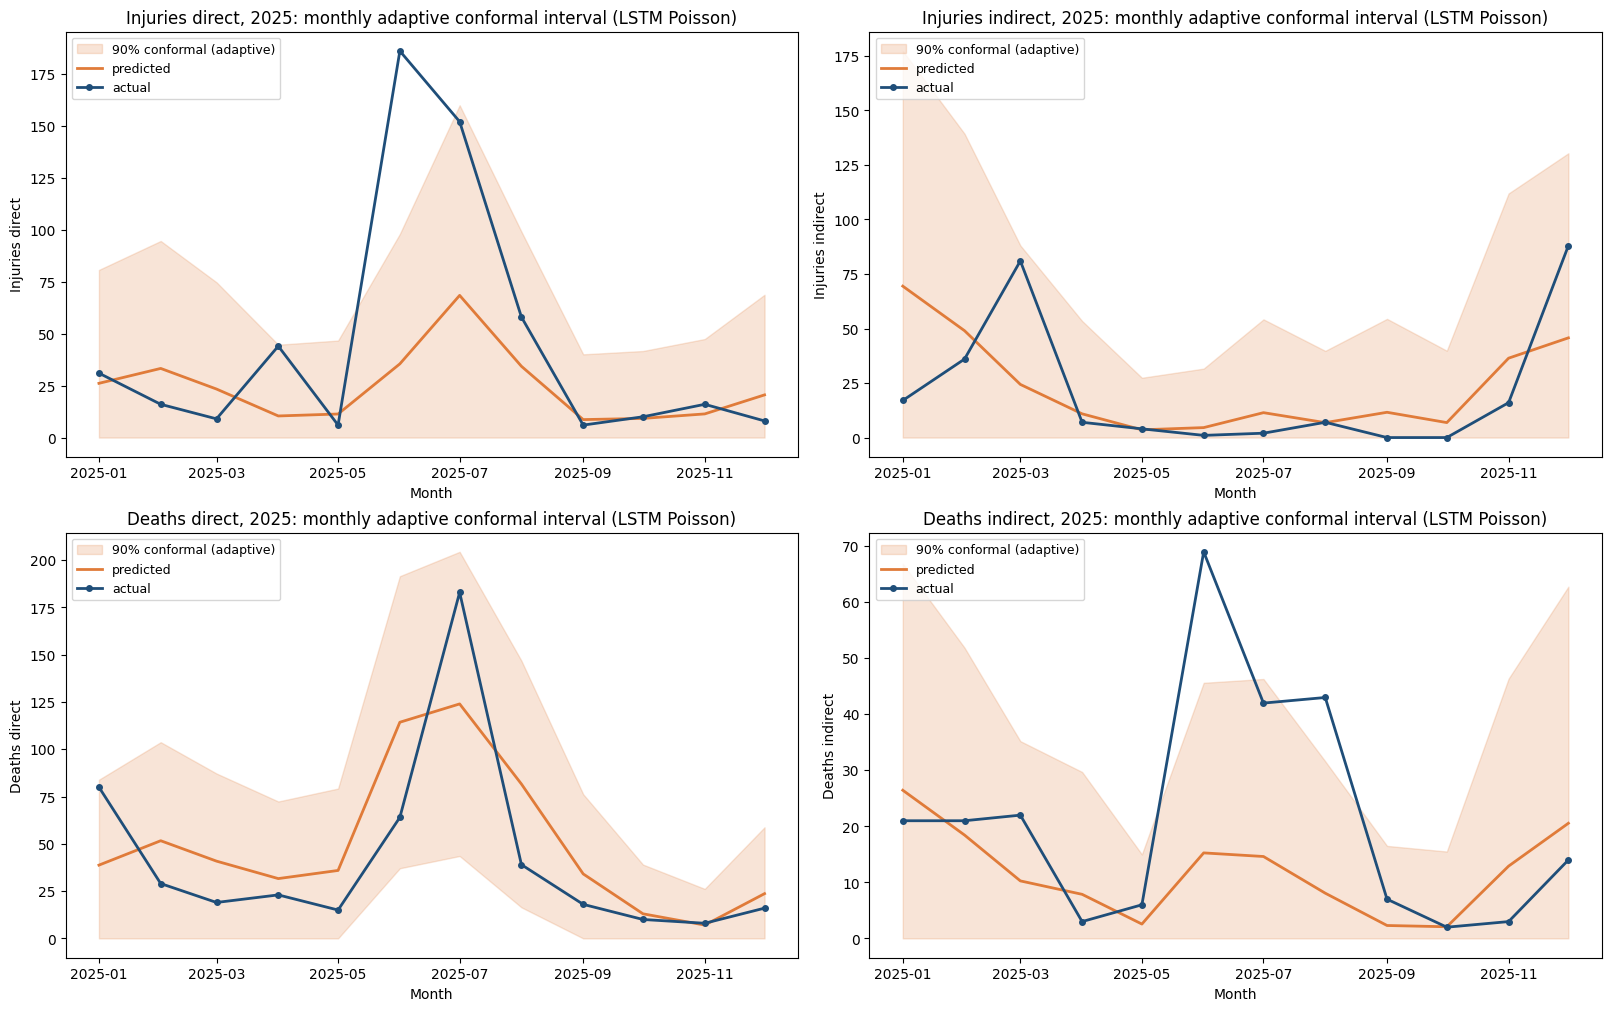

In [69]:
plot_conformal_monthly(forecast_results, target_list, model='LSTM', test_year=2025)

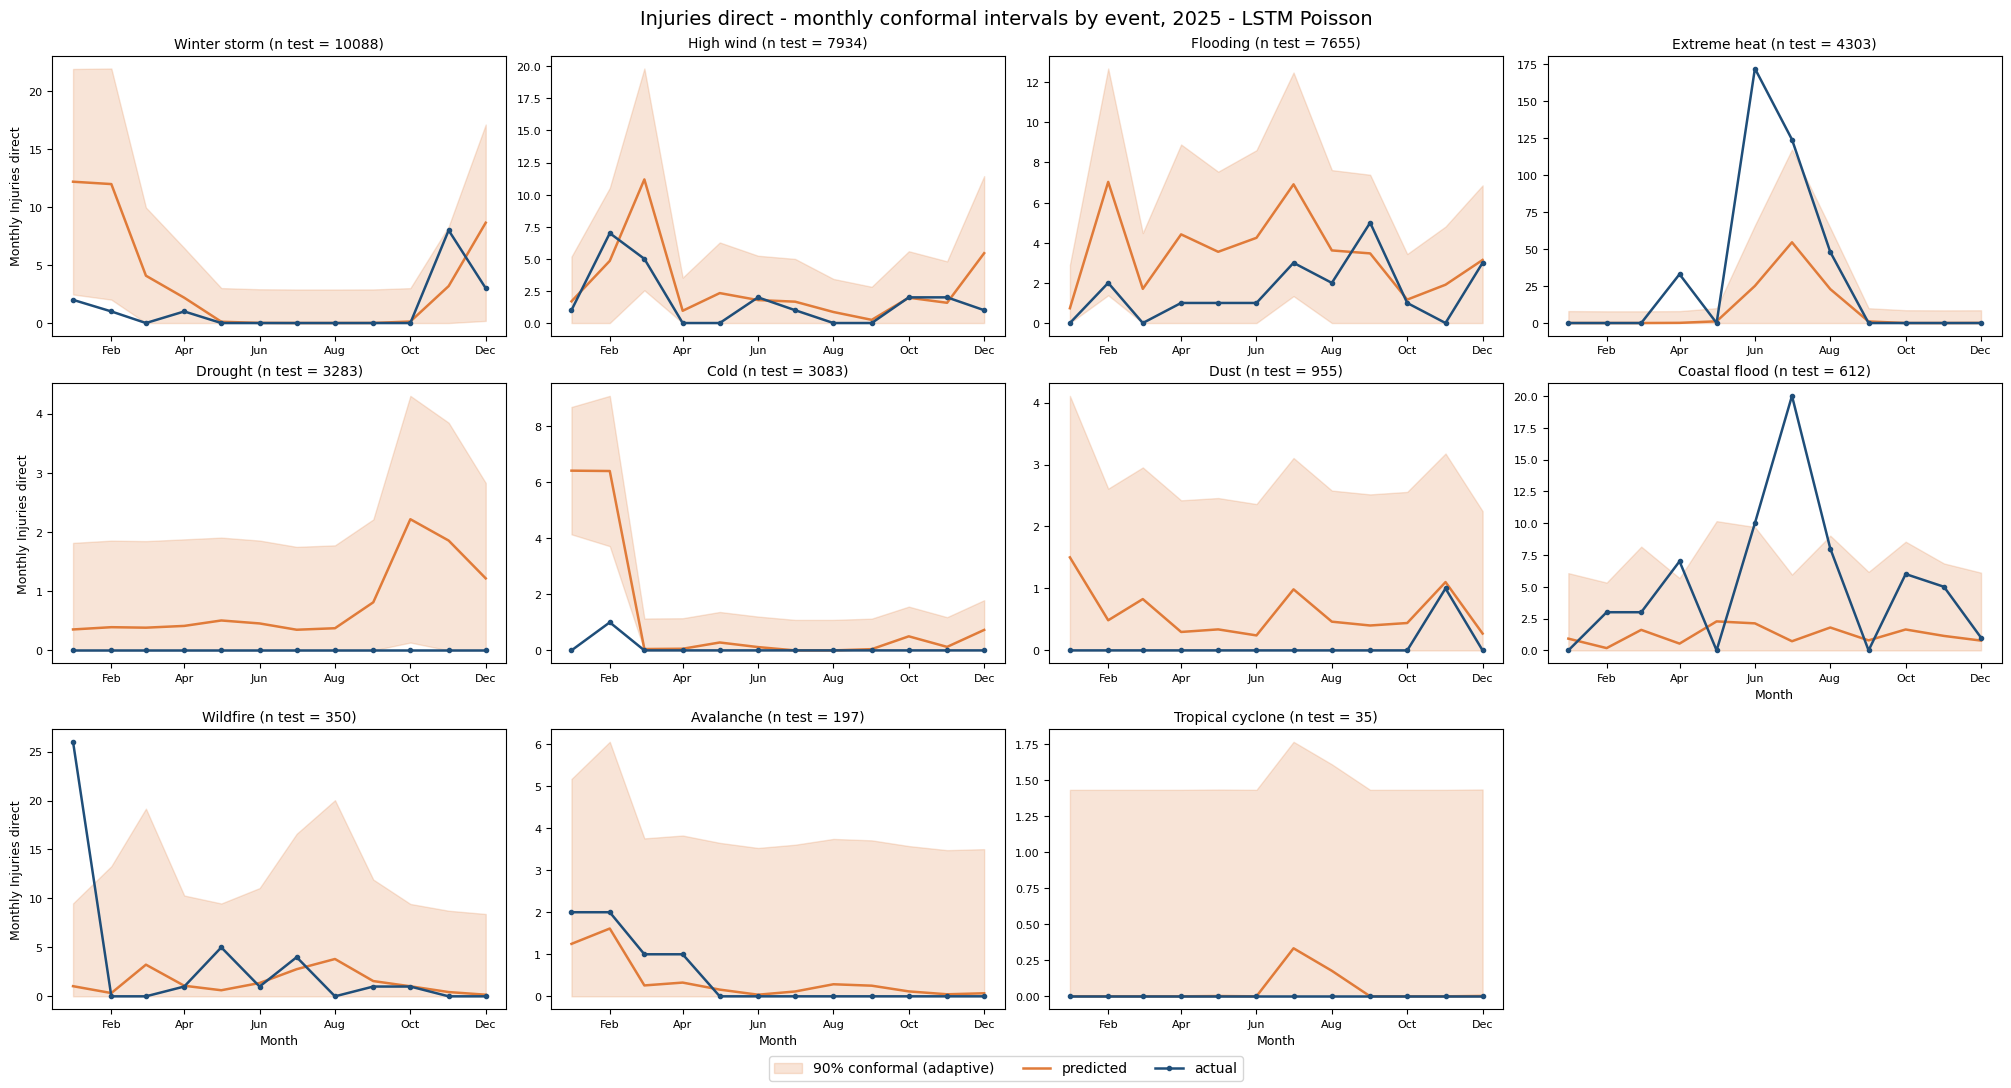

In [70]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES_DIRECT', model='LSTM', test_year=2025)

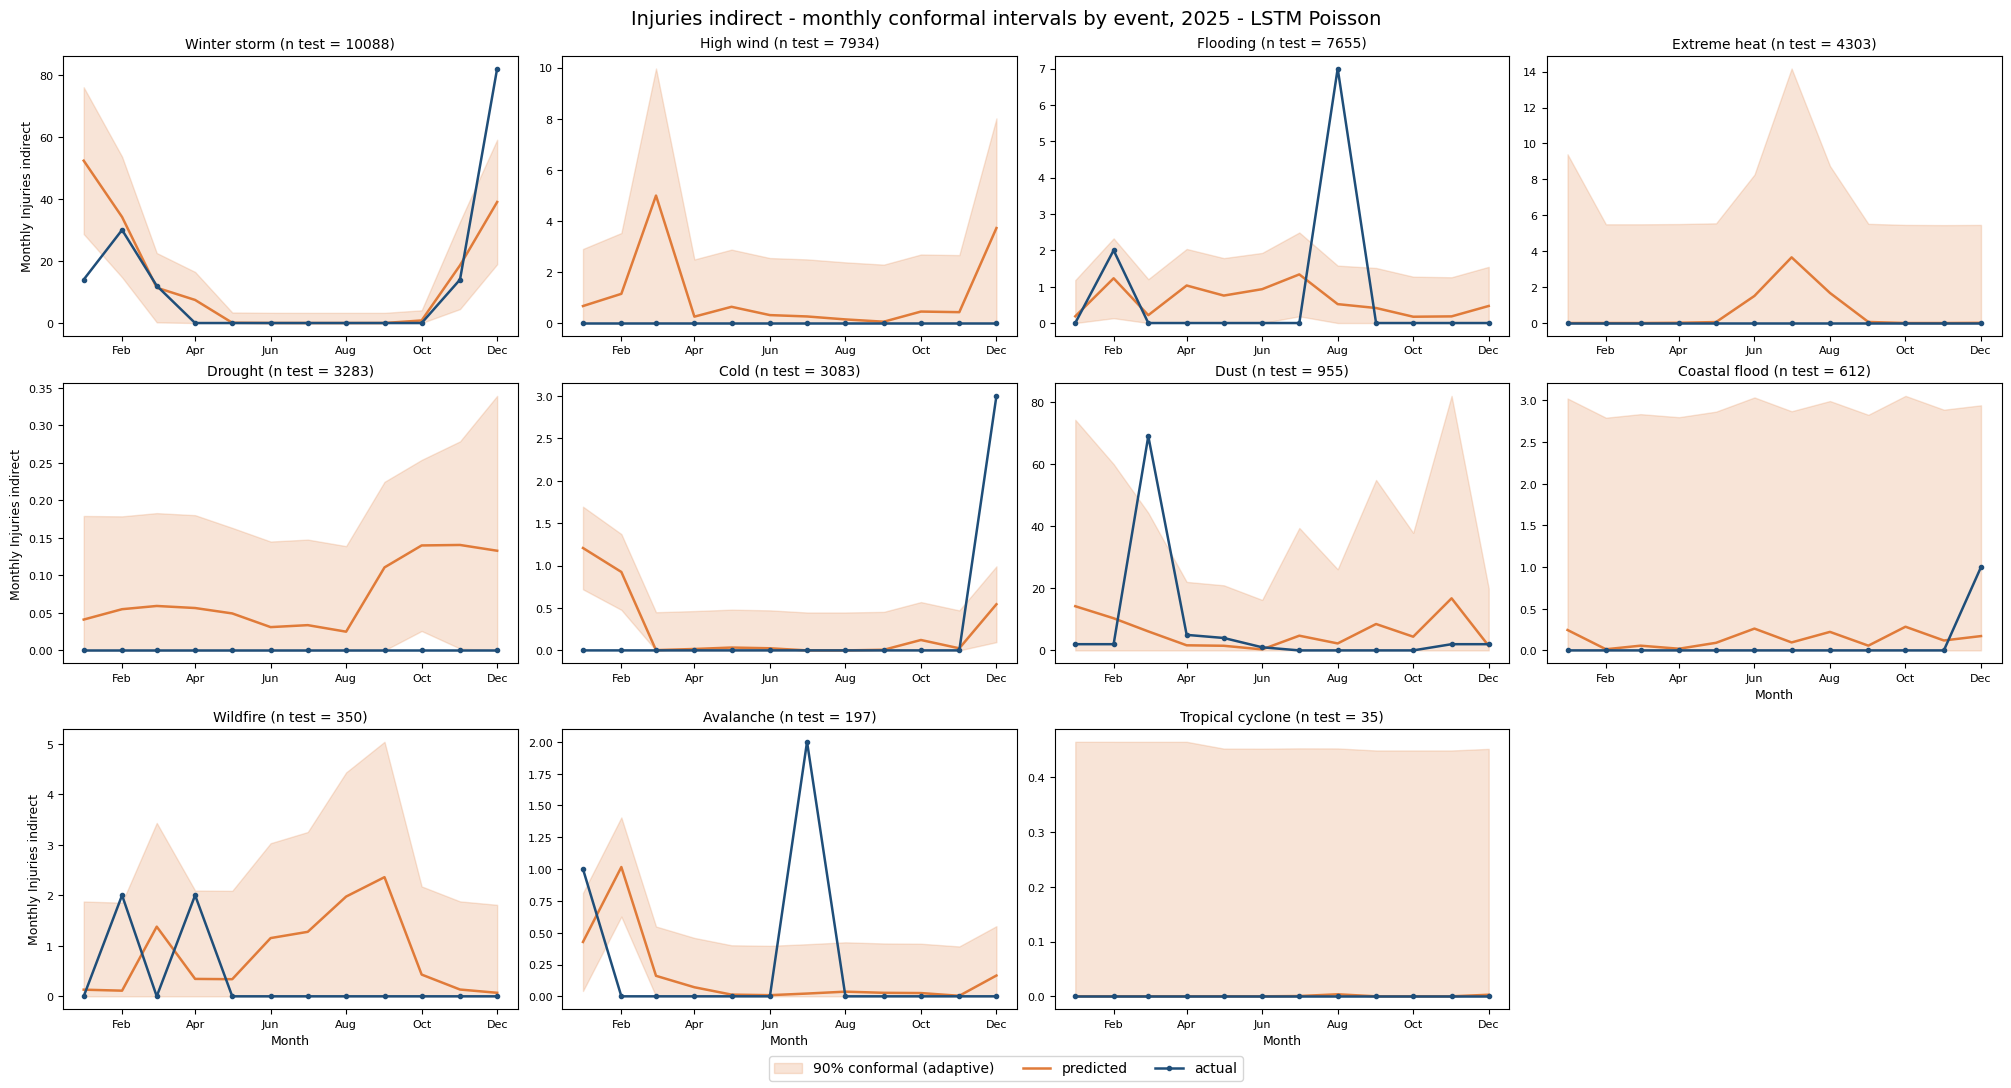

In [71]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES_INDIRECT', model='LSTM', test_year=2025)

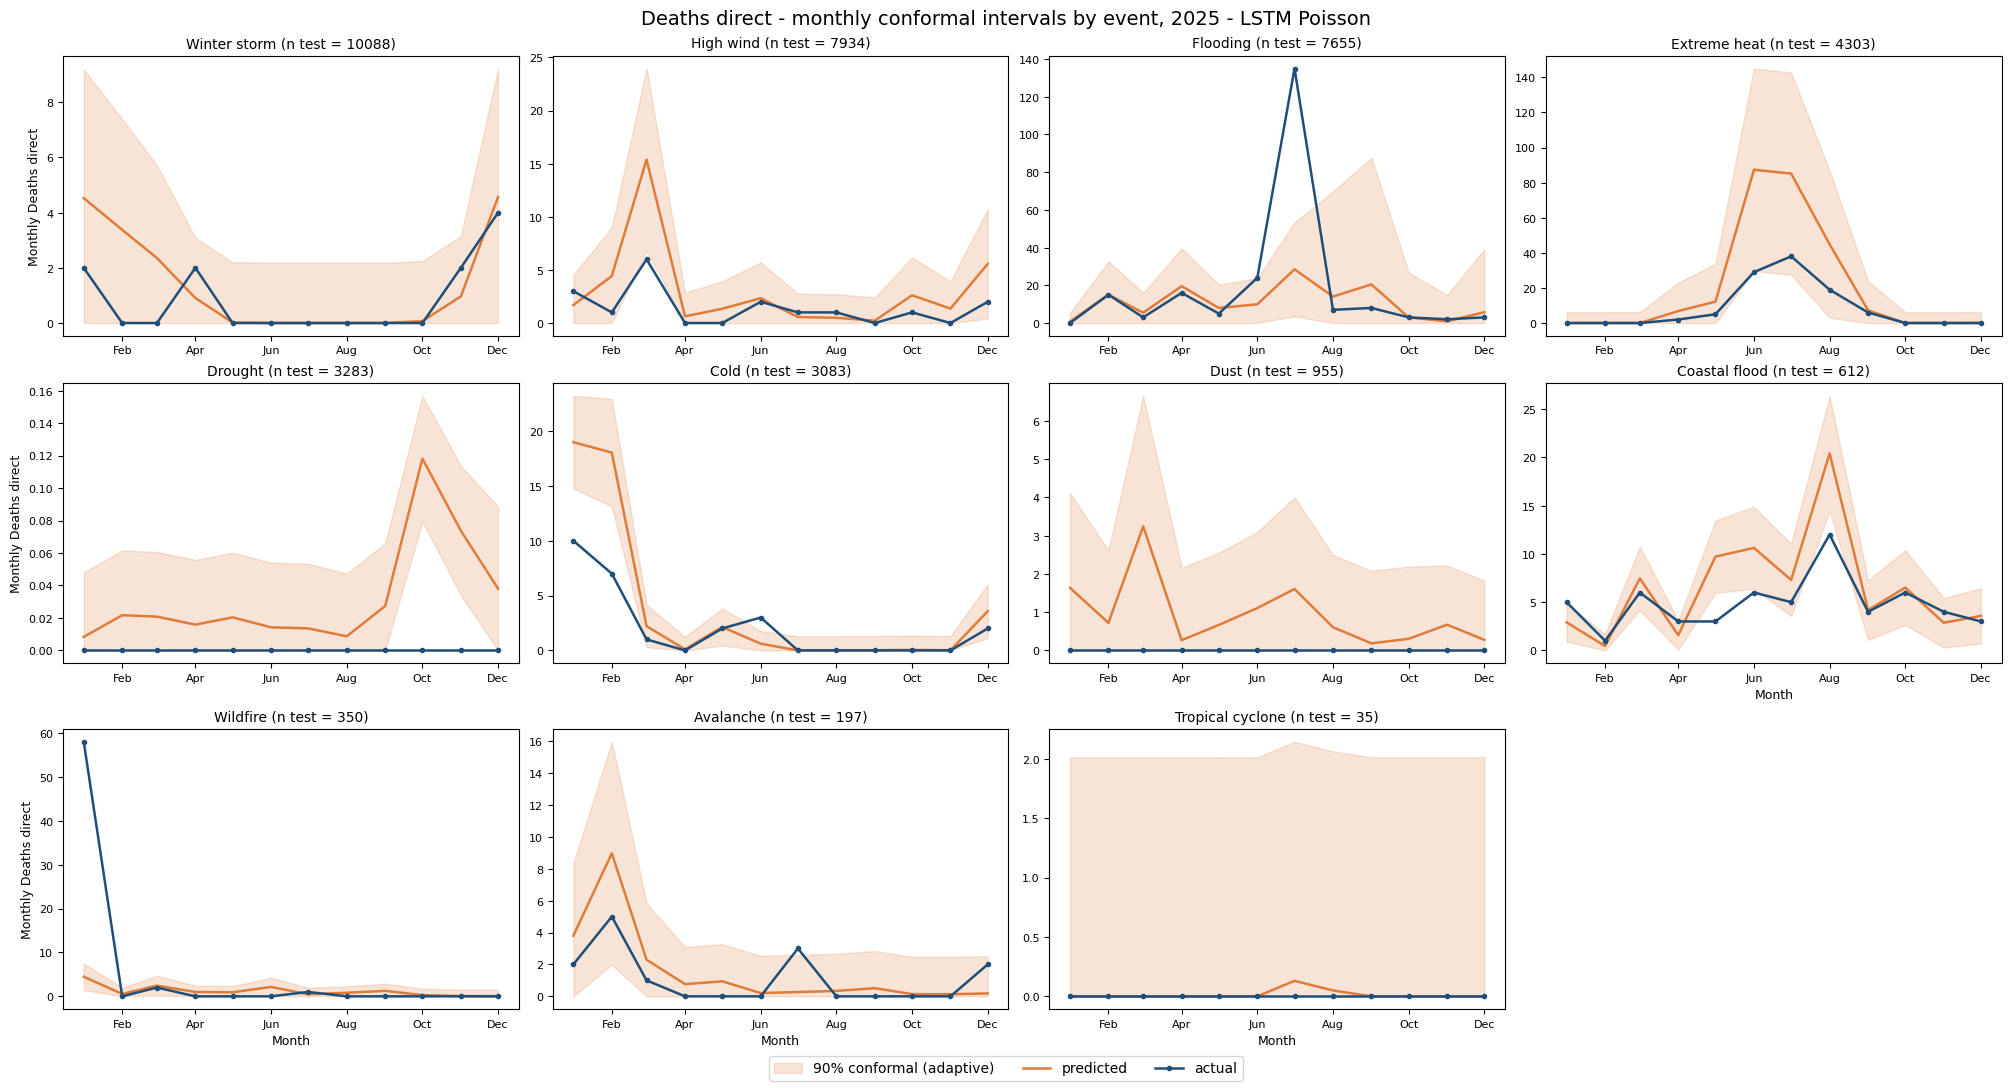

In [72]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS_DIRECT', model='LSTM', test_year=2025)

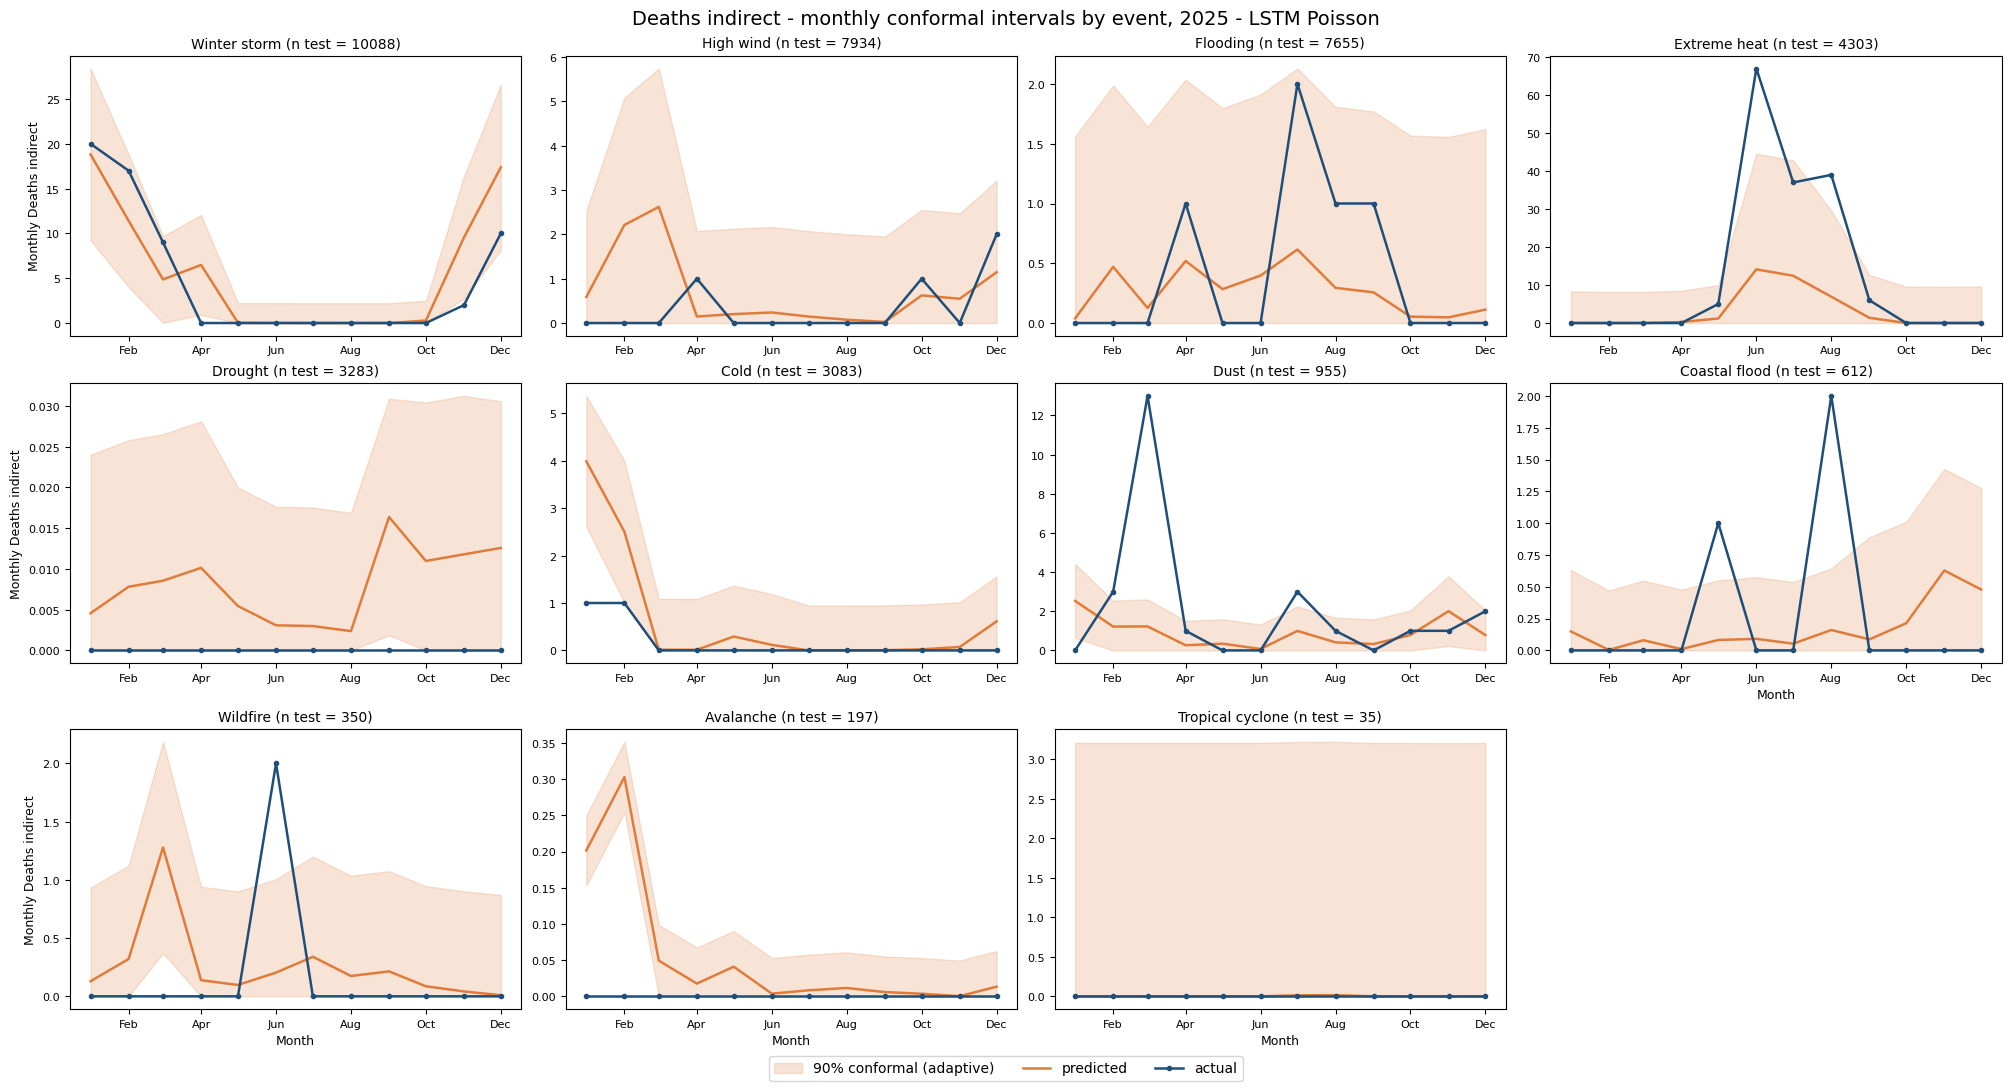

In [73]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS_INDIRECT', model='LSTM', test_year=2025)

### Backtesting Results



 BACKTESTING FOR TARGET: INJURIES_DIRECT (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


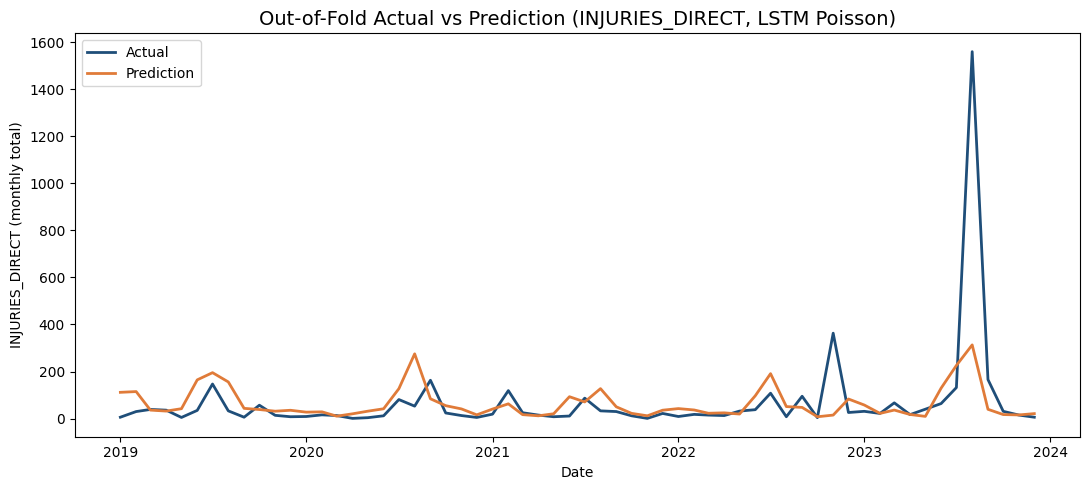

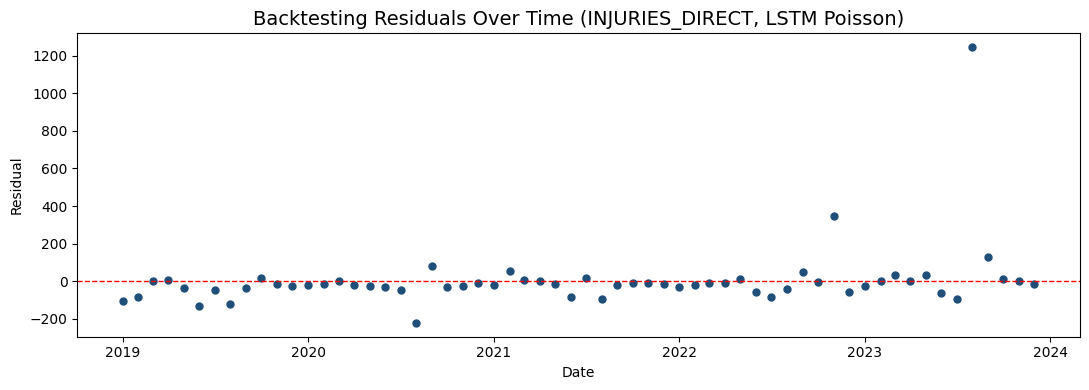

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,96,0.1146,0.4618,0.1359
2020,31055,103,0.1907,0.6506,0.1407
2021,36224,101,0.2727,0.6092,0.1077
2022,42173,120,-0.0773,1.7470,0.2955
2023,39686,139,0.1139,4.7554,0.7623


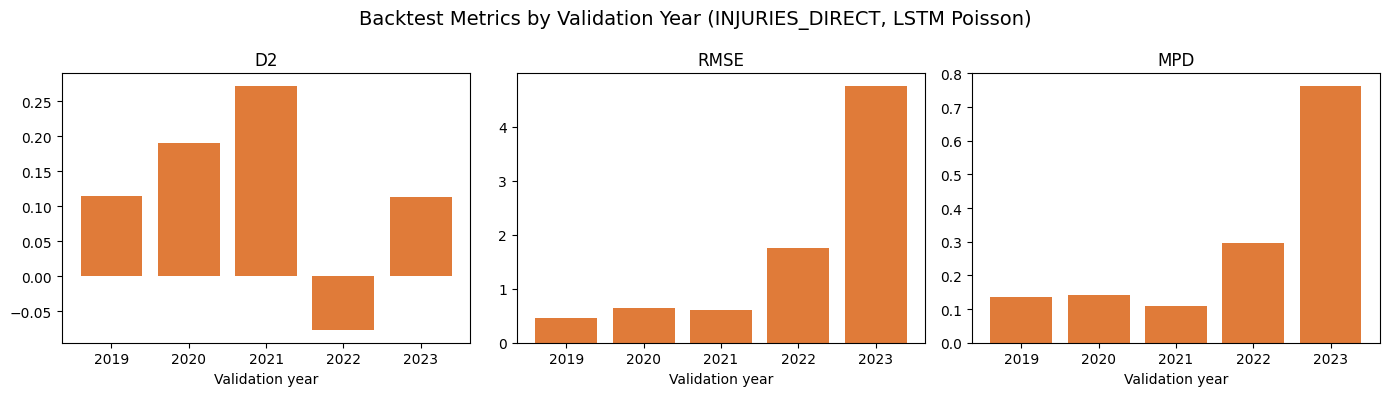

In [74]:
backtest_target_cv(
    train_events,
    'INJURIES_DIRECT',
    params=BEST_PARAMETERS_LSTM['INJURIES_DIRECT'],
    model='LSTM',
)


 BACKTESTING FOR TARGET: INJURIES_INDIRECT (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


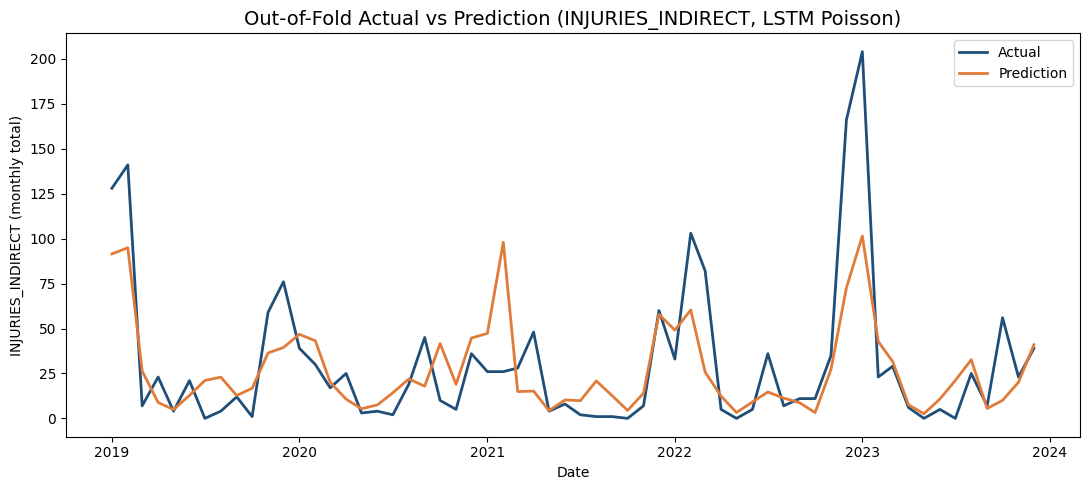

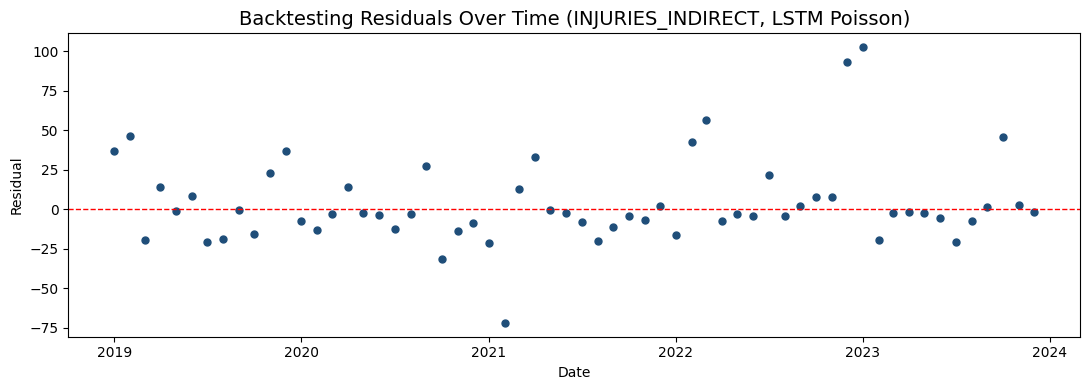

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,88,0.4031,0.6080,0.1088
2020,31055,76,0.3262,0.2503,0.0666
2021,36224,62,0.4540,0.2604,0.0445
2022,42173,120,0.2765,0.4884,0.1135
2023,39686,101,0.4821,0.4760,0.0755


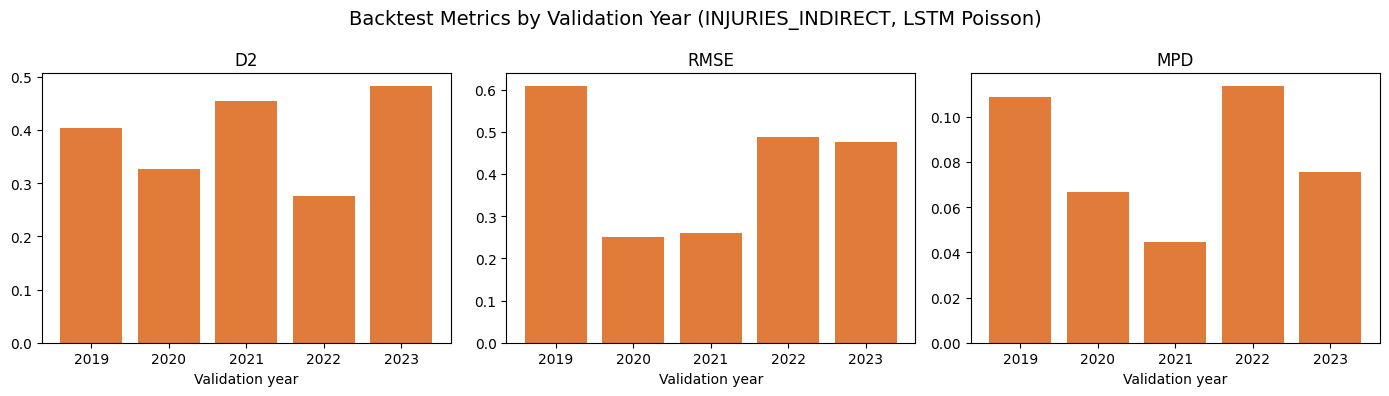

In [75]:
backtest_target_cv(
    train_events,
    'INJURIES_INDIRECT',
    params=BEST_PARAMETERS_LSTM['INJURIES_INDIRECT'],
    model='LSTM',
)


 BACKTESTING FOR TARGET: DEATHS_DIRECT (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


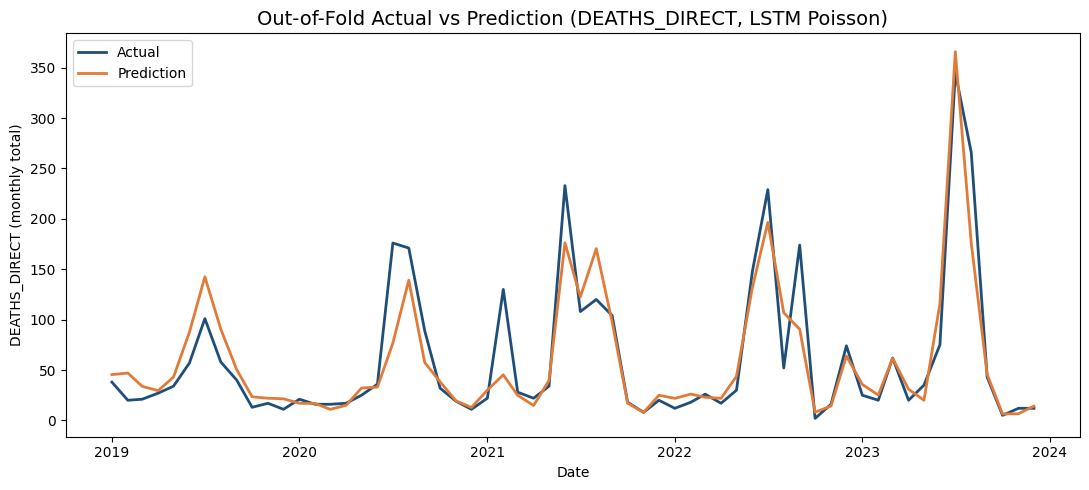

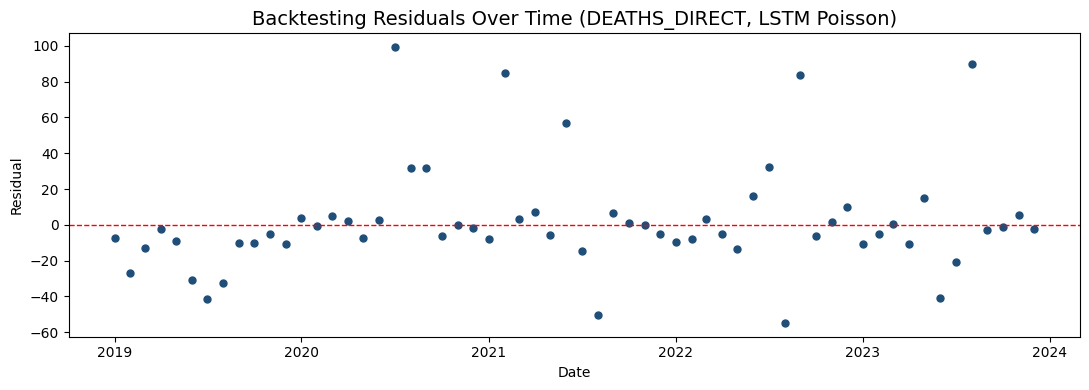

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,333,0.6062,0.1291,0.0457
2020,31055,300,0.5928,0.4097,0.0874
2021,36224,428,0.5175,0.5891,0.1165
2022,42173,353,0.5830,0.4753,0.0863
2023,39686,409,0.6026,0.7071,0.1018


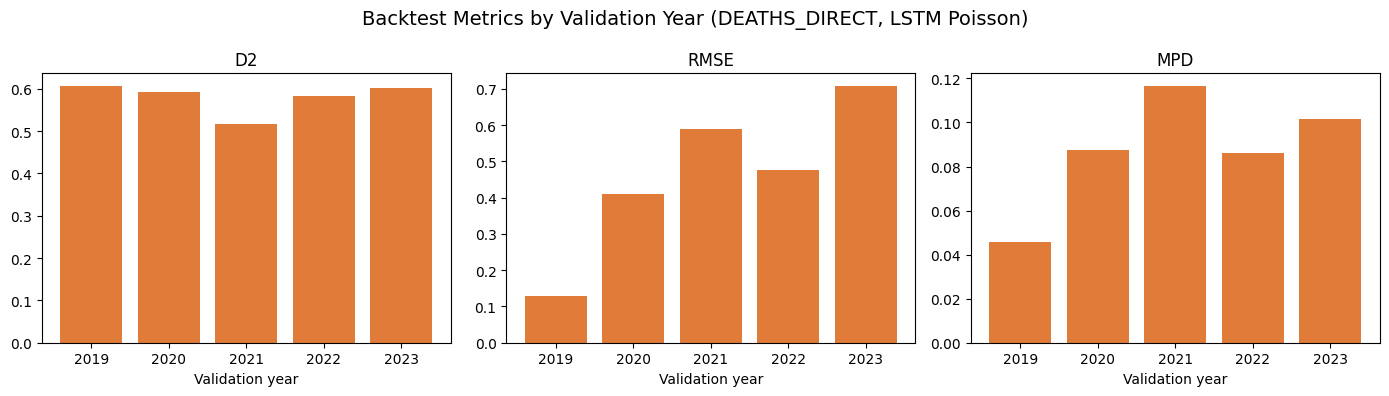

In [76]:
backtest_target_cv(
    train_events,
    'DEATHS_DIRECT',
    params=BEST_PARAMETERS_LSTM['DEATHS_DIRECT'],
    model='LSTM',
)


 BACKTESTING FOR TARGET: DEATHS_INDIRECT (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


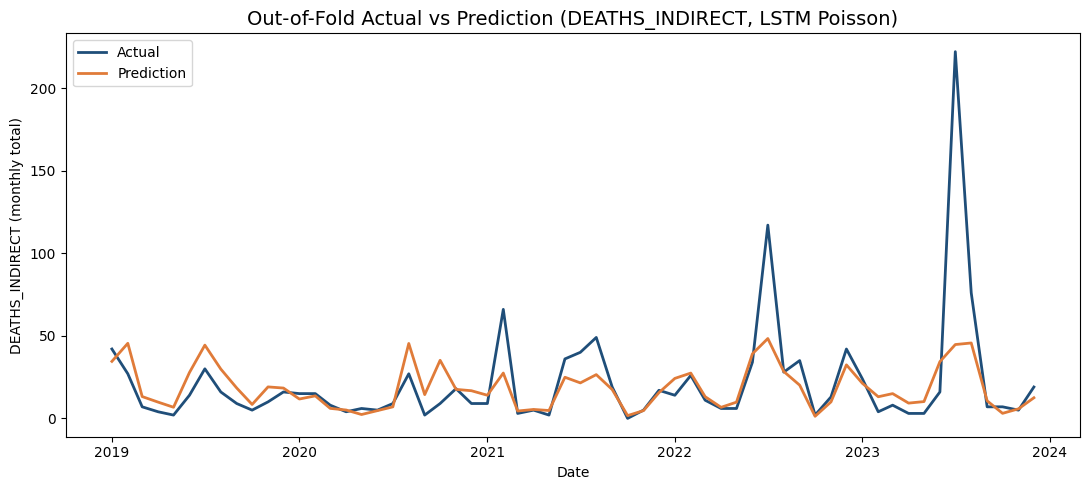

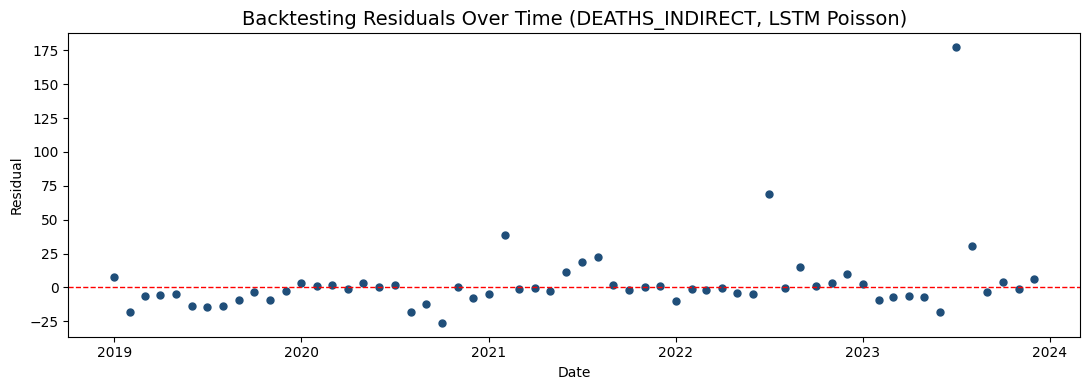

,n,events,D2,RMSE,MPD
year,,,,,
2019,36353,152,0.6174,0.0708,0.0212
2020,31055,87,0.4419,0.1059,0.0279
2021,36224,156,0.5716,0.1275,0.0337
2022,42173,188,0.6516,0.1419,0.0314
2023,39686,136,0.5303,0.3775,0.0602


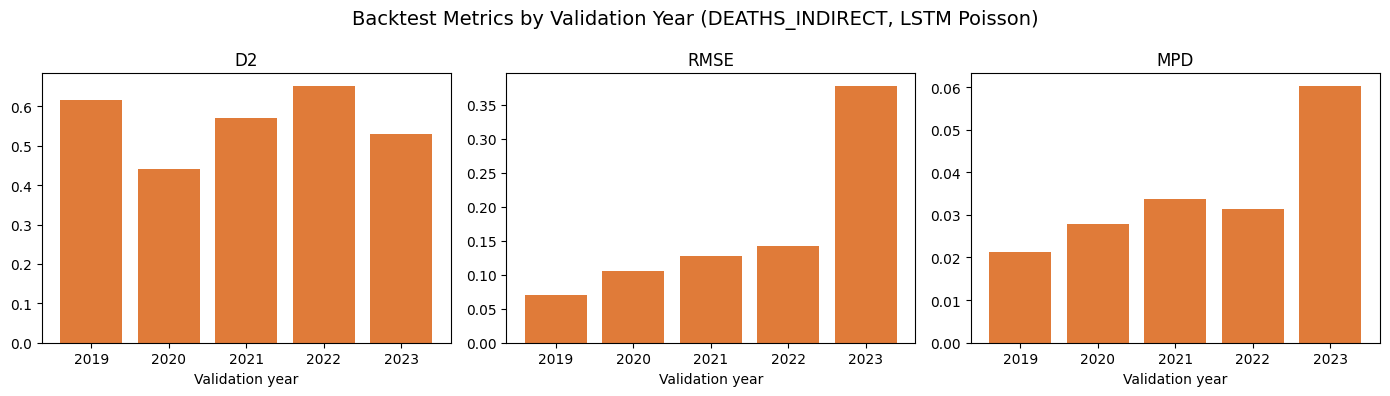

In [77]:
backtest_target_cv(
    train_events,
    'DEATHS_INDIRECT',
    params=BEST_PARAMETERS_LSTM['DEATHS_INDIRECT'],
    model='LSTM',
)

## Models Comparison

In [78]:
#########################################################
# COMPARISON SETUP
#############################################################

MODEL_RESULTS = {
    "GLM": glm_results,
    "LGBM": lgbm_results,
    "LSTM": lstm_results,
}

MODEL_COLORS = {
    "GLM": "#1f4e79",
    "LGBM": "#e07b39",
    "LSTM": "#4c9a2a",
}

COMPARISON_METRICS = ["D2", "RMSE", "MPD"]
METRIC_DIRECTION = {"D2": "high = better", "RMSE": "low = better", "MPD": "low = better"}
ALPHA_TARGET = 0.10


def collect_point_metrics(model_results=MODEL_RESULTS):
    frames = []
    for model_name, results in model_results.items():
        table = point_metrics_by_target(results).reset_index()
        table["Model"] = model_name
        frames.append(table)

    comparison = pd.concat(frames, ignore_index=True)
    comparison["Split"] = pd.Categorical(comparison["Split"], categories=SPLIT_ORDER, ordered=True)

    return comparison[["Model", "Target", "Split", *POINT_METRIC_COLUMNS]].sort_values(
        ["Target", "Split", "Model"]
    )


def collect_conformal_by_target(model_results=MODEL_RESULTS, alpha_target=ALPHA_TARGET):
    rows = []
    for model_name, results in model_results.items():
        for target, result in results.items():
            levels = {
                "daily": result["daily_conformal"],
                "monthly": result["monthly_conformal"],
            }
            for level_name, frame in levels.items():
                rows.append({
                    "Model": model_name,
                    "Target": target,
                    "Level": level_name,
                    "n": len(frame),
                    "Coverage": float(frame["covered"].mean()),
                    "MeanActual": float(frame["actual"].mean()),
                    "MeanWidth": float(frame["width"].mean()),
                    "Nominal": 1.0 - alpha_target,
                })


    return _add_relative_width(pd.DataFrame(rows))[
        ["Model", "Target", "Level", "n", "Coverage",
         "MeanActual", "MeanWidth", "RelWidth", "Nominal"]
    ]



point_comparison = collect_point_metrics()
conformal_comparison = collect_conformal_by_target()





In [79]:
#############################################################
# 1. POINT METRICS: MODEL x TARGET x SPLIT
#############################################################


def plot_metric_comparison(
    metrics_table=None,
    metrics=COMPARISON_METRICS,
    splits=SPLIT_ORDER,
    targets=None,
    model_colors=MODEL_COLORS,
):
    metrics_table = collect_point_metrics() if metrics_table is None else metrics_table
    targets = list(FORECAST_TARGETS) if targets is None else list(targets)
    models = list(model_colors)

    positions = np.arange(len(targets))
    bar_width = 0.8 / len(models)

    fig, axes = plt.subplots(
        len(metrics),
        len(splits),
        figsize=(5.4 * len(splits), 3.6 * len(metrics)),
        layout="constrained",
        squeeze=False,
    )

    for row, metric in enumerate(metrics):
        for column, split in enumerate(splits):
            ax = axes[row][column]
            panel = metrics_table[metrics_table["Split"] == split]

            for index, model_name in enumerate(models):
                values = (
                    panel[panel["Model"] == model_name]
                    .set_index("Target")
                    .reindex(targets)[metric]
                    .to_numpy(dtype=float)
                )
                offset = (index - (len(models) - 1) / 2) * bar_width
                ax.bar(
                    positions + offset,
                    values,
                    width=bar_width,
                    color=model_colors[model_name],
                    edgecolor="white",
                    linewidth=0.5,
                    label=model_name if (row == 0 and column == 0) else None,
                )

                for position, value in zip(positions + offset, values):
                    if np.isnan(value):
                        ax.text(position, 0, "n/d", ha="center", va="bottom", fontsize=8, color="grey")

            if metric == "D2":
                ax.axhline(0.0, color="grey", linestyle="--", linewidth=1)
            else:
                spread = panel[metric].to_numpy(dtype=float)
                spread = spread[np.isfinite(spread) & (spread > 0)]
                if len(spread) > 0 and spread.max() / spread.min() > 50:
                    ax.set_yscale("log")
                    ax.set_ylim(spread.min() * 0.5, spread.max() * 2.0)

            ax.set_xticks(positions)
            ax.set_xticklabels([name for name in targets], rotation=20, ha="right", fontsize=9)
            ax.set_title(f"{metric} — {split} ({METRIC_DIRECTION[metric]})", fontsize=11)
            ax.set_ylabel(metric)

    axes[0][0].legend(fontsize=9, title="Model")
    fig.suptitle("Point metrics comparison by target and split", fontsize=14)
    plt.show()




In [94]:
#############################################################
# 2. CONFORMAL COVERAGE AND RELATIVE WIDTH BY TARGET
#############################################################

def plot_conformal_comparison(
    conformal_table=None,
    levels=("daily",),
    targets=None,
    quantities=("Coverage", "RelWidth"),
    model_colors=MODEL_COLORS,
):
    """Coverage and width per target"""
    conformal_table = collect_conformal_by_target() if conformal_table is None else conformal_table


    targets = list(FORECAST_TARGETS) if targets is None else list(targets)
    models = list(model_colors)
    columns = [name for name in quantities if name in conformal_table.columns]


    positions = np.arange(len(targets))
    bar_width = 0.8 / len(models)
    target_labels = [name.replace("_", " ").capitalize() for name in targets]
    nominal = (
        float(conformal_table["Nominal"].iloc[0])
        if "Nominal" in conformal_table.columns
        else None
    )

    fig, axes = plt.subplots(
        len(levels),
        len(columns),
        figsize=(7.0 * len(columns), 4.4 * len(levels)),
        layout="constrained",
        squeeze=False,
    )

    for row, level_name in enumerate(levels):
        panel_source = conformal_table[conformal_table["Level"] == level_name]

        for column, quantity in enumerate(columns):
            ax = axes[row][column]

            for index, model_name in enumerate(models):
                values = (
                    panel_source[panel_source["Model"] == model_name]
                    .set_index("Target")
                    .reindex(targets)[quantity]
                    .to_numpy(dtype=float)
                )
                offset = (index - (len(models) - 1) / 2) * bar_width
                bars = ax.bar(
                    positions + offset,
                    values,
                    width=bar_width,
                    color=model_colors[model_name],
                    edgecolor="white",
                    linewidth=0.5,
                    label=model_name if (row == 0 and column == 0) else "_nolegend_",
                )
                ax.bar_label(
                    bars,
                    labels=["" if not np.isfinite(v) else f"{v:.2f}" for v in values],
                    fontsize=8,
                    padding=2,
                )

            if quantity == "Coverage":
                if nominal is not None:
                    ax.axhline(
                        nominal,
                        color="red",
                        linestyle="--",
                        linewidth=1.2,
                        label=f"nominal {nominal:.2f}" if row == 0 else "_nolegend_",
                    )
                ax.set_ylim(0.0, 1.15)
            else:
                spread = panel_source[quantity].to_numpy(dtype=float)
                spread = spread[np.isfinite(spread) & (spread > 0)]

                if len(spread) > 0:
                    if spread.max() / spread.min() > 50:
                        ax.set_yscale("log")
                    else:
                        ax.set_ylim(0.0, spread.max() * 1.20)

            ax.set_xticks(positions)
            ax.set_xticklabels(target_labels, rotation=20, ha="right", fontsize=9)
            ax.set_title(f"{quantity}", fontsize=11)
            ax.set_ylabel(quantity)
            ax.grid(axis="y", alpha=0.25, linewidth=0.6)
            ax.set_axisbelow(True)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncols=len(models) + 1, fontsize=9)
    fig.suptitle("Conformal intervals: coverage and relative width by target", fontsize=14)
    plt.show()

In [90]:
# ==============================================================================
# 3. POINT METRICS HEATMAP BY EVENT GROUP AND TARGET
# ==============================================================================

HEATMAP_METRICS = {
    "D2": ("D2 (high = better)", "RdYlGn", "{:.2f}"),
    "RMSE": ("RMSE (low = better)", "YlOrRd", "{:.3g}"),
    "MPD": ("MPD (low = better)", "YlOrRd", "{:.3g}"),
}


def _shade_by_target(panel, metric):
    """Colour scale for one heatmap panel."""
    if metric == "D2":
        return panel.clip(lower=-1.0, upper=1.0), -1.0, 1.0

    lowest = panel.min(axis=0)
    highest = panel.max(axis=0)
    span = (highest - lowest).replace(0.0, np.nan)

    return (panel - lowest) / span, 0.0, 1.0


def plot_point_metrics_heatmap(
    results,
    metrics=None,
    targets=None,
    model=None,
    group_column=GROUP_COL,
    split="test",
):
    """Event group x target heatmap of the point metrics, test split only."""
    label = model_label(_check_model(results, model))
    metrics = list(HEATMAP_METRICS) if metrics is None else list(metrics)
    targets = list(FORECAST_TARGETS) if targets is None else list(targets)

    table = point_metrics_by_event_group(
        results, group_column=group_column, targets=None, model=model
    )
    table = table[table.index.get_level_values("Split") == split]

    if table.empty:
        raise ValueError(f"no {split} rows in the group metrics table")

    table = table.droplevel("Split")

    group_order = (
        table.groupby(group_column, observed=True)["events"]
        .sum()
        .sort_values(ascending=False)
        .index
    )
    target_labels = [name.replace("_", " ").capitalize() for name in targets]

    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(4.2 * len(metrics), 0.42 * len(group_order) + 2.6),
        layout="constrained",
        squeeze=False,
    )

    for column, metric in enumerate(metrics):
        ax = axes[0][column]
        title, colormap, number_format = HEATMAP_METRICS[metric]

        panel = (
            table[metric]
            .unstack("Target")
            .reindex(index=group_order, columns=targets)
            .astype(float)
        )
        shading, vmin, vmax = _shade_by_target(panel, metric)

        image = ax.imshow(
            shading.to_numpy(),
            cmap=colormap,
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
        )
        image.cmap.set_bad("#e8e8e8")

        for row_index, group_name in enumerate(panel.index):
            for column_index, target in enumerate(panel.columns):
                value = panel.loc[group_name, target]
                shade = shading.loc[group_name, target]

                if not np.isfinite(value):
                    ax.text(column_index, row_index, "n/d", ha="center", va="center",
                            fontsize=7, color="grey")
                    continue

                ax.text(
                    column_index,
                    row_index,
                    number_format.format(value),
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if np.isfinite(shade) and shade > 0.72 else "black",
                )

        ax.set_xticks(np.arange(len(targets)))
        ax.set_xticklabels(target_labels, rotation=30, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(panel.index)))
        ax.set_yticklabels([str(name).replace("_", " ") for name in panel.index], fontsize=8)
        ax.set_title(title, fontsize=11)

        ax.set_xticks(np.arange(len(targets) + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(len(panel.index) + 1) - 0.5, minor=True)
        ax.grid(which="minor", color="white", linewidth=1.0)
        ax.tick_params(which="minor", length=0)

        bar = fig.colorbar(image, ax=ax, fraction=0.045, pad=0.02)
        bar.set_label(
            "D2" if metric == "D2" else "per-target min-max (dark = worse)", fontsize=8
        )
        bar.ax.tick_params(labelsize=7)

    fig.suptitle(
        f"Point metrics by event group and target — {split} split — {label}", fontsize=14
    )
    plt.show()

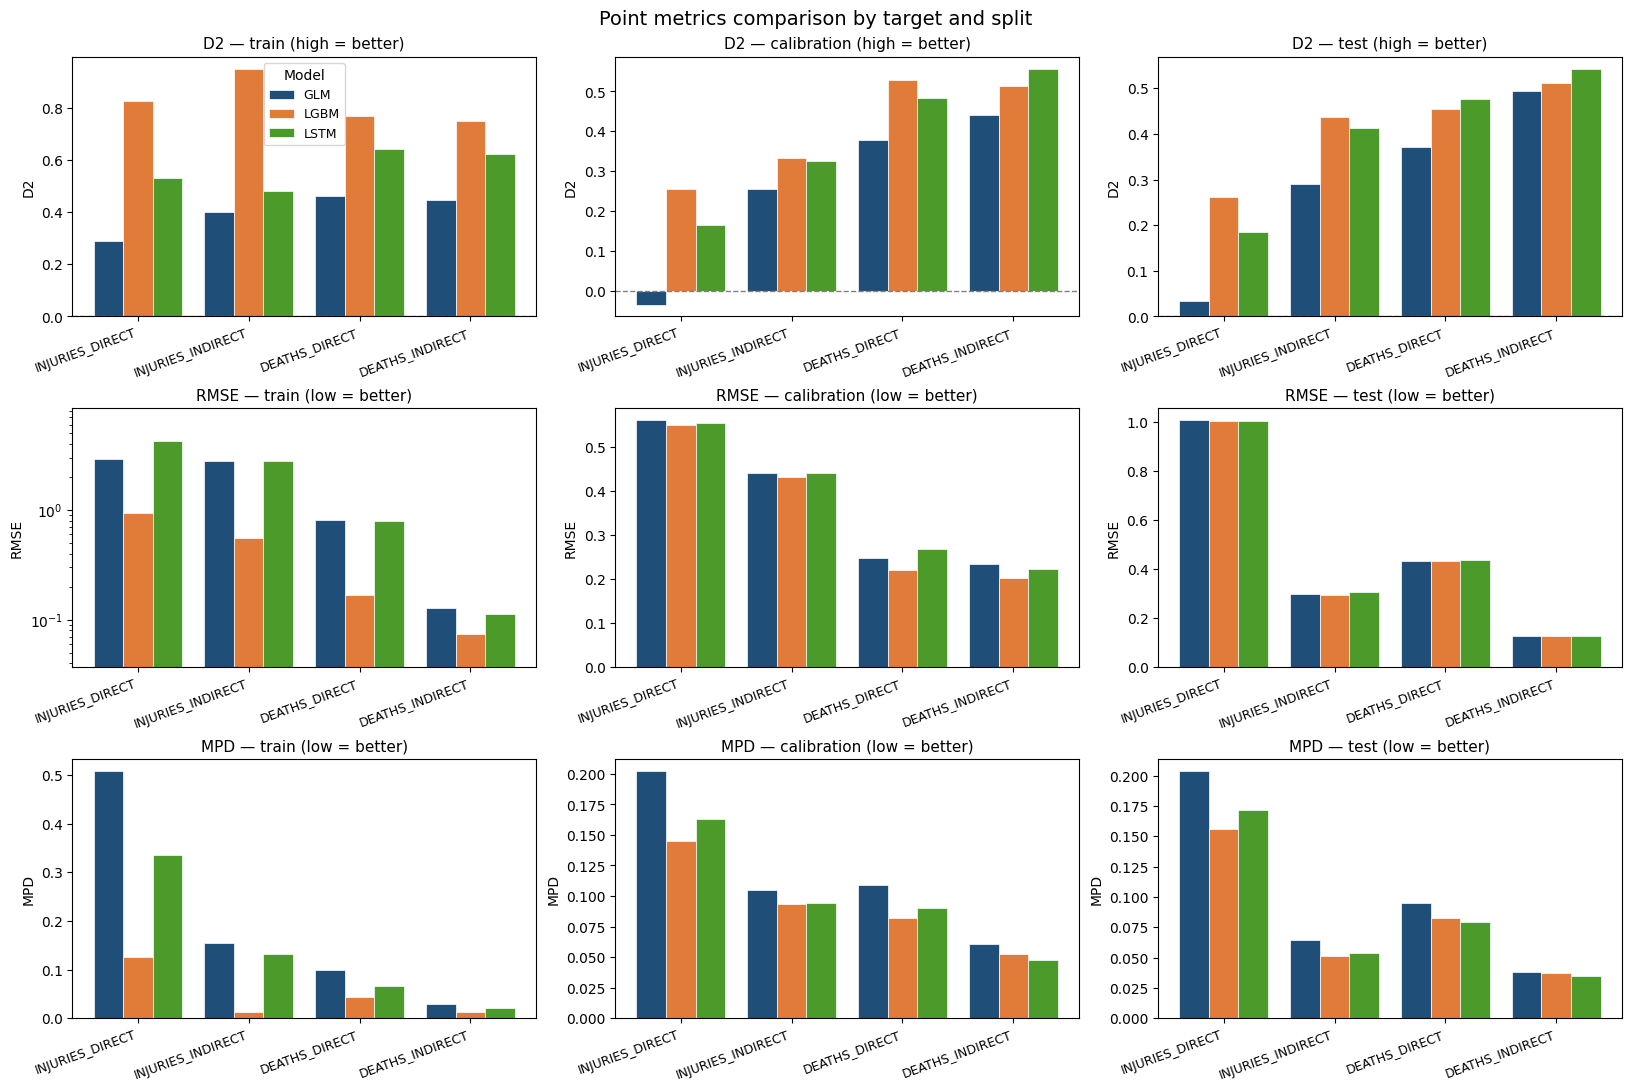

In [83]:
plot_metric_comparison(point_comparison)

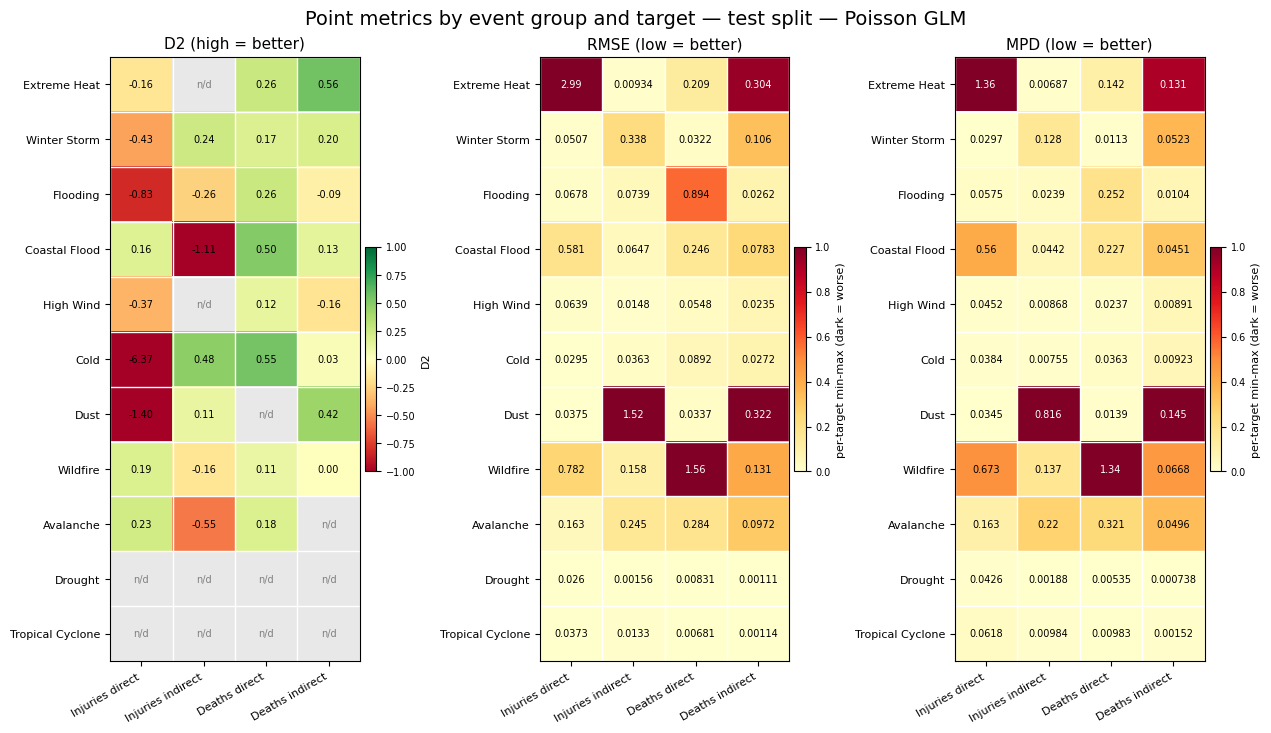

In [91]:
plot_point_metrics_heatmap(glm_results)


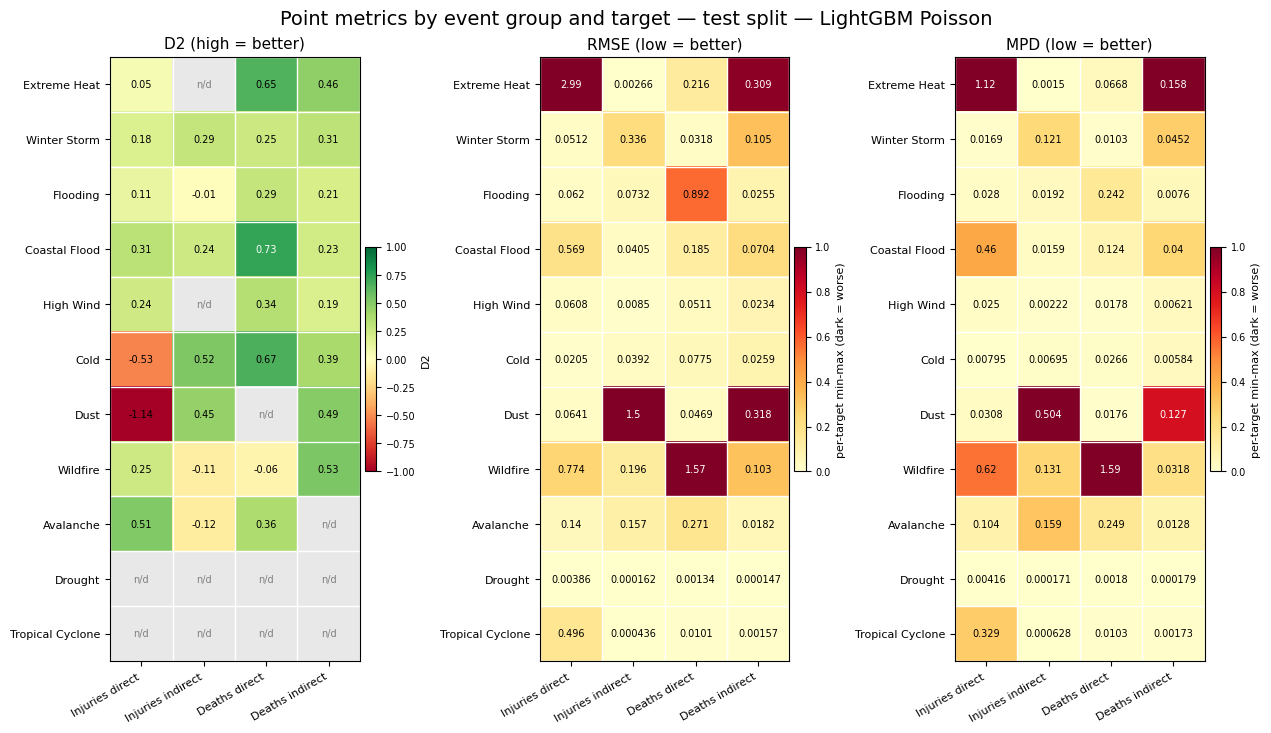

In [92]:
plot_point_metrics_heatmap(lgbm_results)


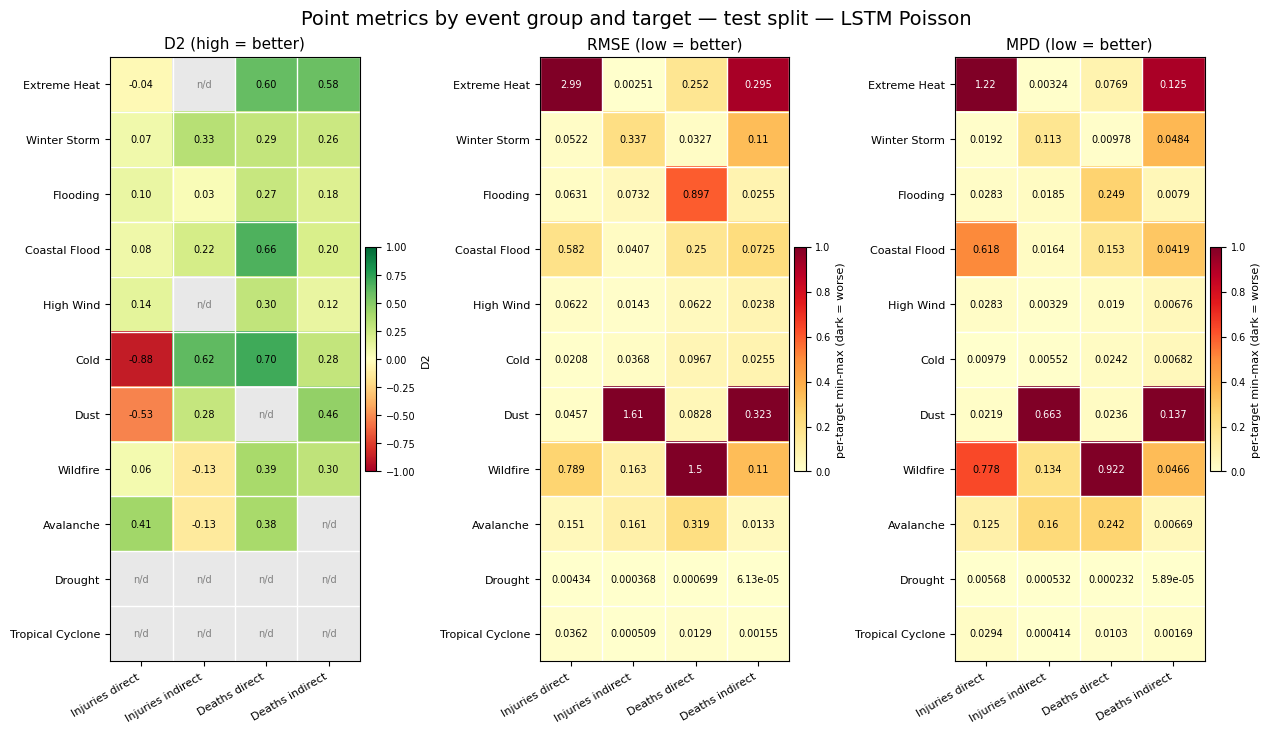

In [93]:
plot_point_metrics_heatmap(lstm_results)


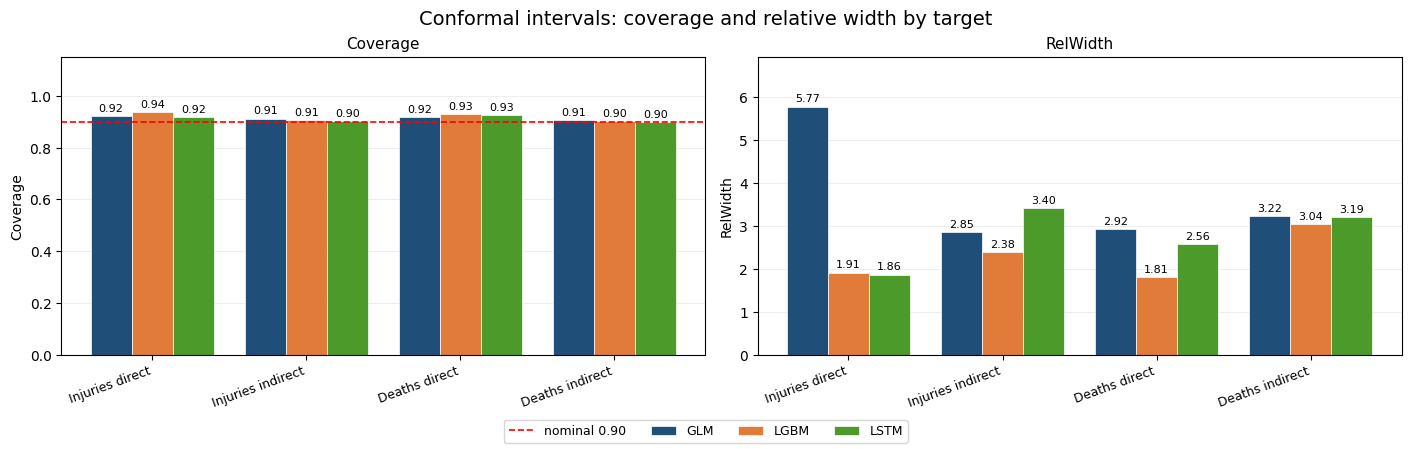

In [95]:
plot_conformal_comparison(conformal_comparison)